# UT Austin: Students, Courses and Grades

All code needed to reproduce the results is in this notebook; figures are written to `figures/`. Every heading is collapsible.

| Part | Contents |
|---|---|
| **0. Data and preparation** | sources and caveats, loading, section table, course-type dummies, external data |
| **1. UT at a glance** | population over time, degrees conferred, where students come from (Texas counties, U.S. states, countries), graduate admissions, enrollment and course offerings by prefix, course size |
| **2. Grades in 2025–26** | mean grade by prefix (unweighted and size-weighted, by field group), grade distribution, section averages, course-type dummies |
| **3. Grade trends by major** | grade trends for core and engineering prefixes, highest/lowest courses overall and within each prefix, foreign-language classes |
| **4. COVID and online instruction** | the COVID-year grade distribution, COVID vs pre-COVID (Fall 2019) course grades, web-based courses over time and their grades |
| **5. Same course, different terms and sequences** | fall vs spring vs summer (2025–26 and all years), I vs II sequences |
| **6. Does UT weed students out?** | following Computer Science and Economics cohorts through their core course sequences |

Line graphs of grades over time mark the public release of ChatGPT (November 30, 2022) with a vertical dotted line.

## 0. Data and preparation

### 0.1 Sources and caveats

#### Grade data

**Source:** [UT Course Grade Distributions](https://reports.utexas.edu/spotlight-data/ut-course-grade-distributions) (EVPP Analytics and Reporting, Institutional Reporting). From the dashboard description:

> "The UT Austin grade distribution displays grade distributions for all courses since summer 2011. The dashboard displays grade distributions based on a unique student headcount for each class, semester and year; it is not representative of enrollment counts or instances of registration. The dashboard was last updated with Summer 2026 grades. In order to maintain student confidentiality, courses are not displayed if they satisfy one of the following conditions:
> 1. The course is graduate level and there are less than 5 students of record.
> 2. The course is undergraduate level and there are less than 10 students of record.
> 3. All students received the same grade.
> 4. All students except one received the same grade.
> 5. None of the students received a letter grade.
>
> - Graduate student instructors' names will not be displayed due to FERPA restrictions.
> - The 'Other' grade category includes all non-standard letter grades, including: In Progress, Incomplete, Permanent Incomplete, Obit, Q-Drop, Withdrawn, Credit, No Credit, Satisfactory, Unsatisfactory, and Registered on CR/F or CR/NC basis.
> - Courses that appear in the filters but are not displayed in the table are redacted according to IRRIS student confidentiality guidelines."

**How the files were obtained.** Fall 2025, Spring 2026 and Summer 2026 were downloaded manually from the dashboard (Download → Crosstab). All other semesters were pulled by `scripts/download_grades.py`, which calls the dashboard's public Tableau CSV export with the filters *Academic Year Span*, *Semester*, *Course Prefix = (all)* and grade detail = *Expanded* (the default export collapses +/− grades). The script's output was checked against the manual Fall 2025 file: identical row count (32,598), identical total grade count (216,760), and every (section, letter grade) row matched. Files are saved as `data/grades/<term><year>.csv` (UTF-16, tab-separated, the dashboard's own crosstab format).

**Additional caveats found while building this analysis**

- **Coverage starts in Summer 2011.** The dashboard returns no rows for Fall 2010 or Spring 2011, so the "Fall 2010 + Spring 2011" base period in §1.8 is replaced with **Fall 2011 + Spring 2012**, the earliest complete academic year.
- **Redaction biases averages upward slightly.** Small sections and sections where everyone (or all but one) got the same grade are dropped, so e.g. all-A small seminars are missing.
- **A+ grades.** A handful of A+ grades appear (mostly LAW). UT's GPA scale caps at 4.0, so A+ is scored **4.0**; in the grade histograms it is folded into the A bar.
- **Summer course numbers** carry a session letter (F/S/W/N, e.g. `F311` = first-session 311). For the Fall/Spring vs Summer comparisons (§5.2–5.3) the letter is stripped so `F311` matches `311`.
- **Course titles are truncated/abbreviated** by the registrar (≈30 characters, e.g. `INTRO`, `ADV`, `PRIN`), and topic courses carry a topic number prefix (`4-FRAUD EXAMINATION`). The course-type dummies account for common abbreviations (see §0.4).
- "Enrollment" / course size here is the dashboard's unique-student headcount per section, so a student in two sections of a prefix counts twice.

#### Other data (downloaded by `scripts/download_demographics.py`)

| Data | Source | Used in |
|---|---|---|
| Student headcount by classification and by gender, Fall 2009–2025 | UT Austin *Trends in Student Data* dashboard ([reports.utexas.edu/spotlight-data/students](https://reports.utexas.edu/spotlight-data/students)), public Tableau CSV export | §1.1, §1.8 |
| Full-time instructional faculty (2009–2024) and full-time non-instructional staff (2012–2024) | IPEDS Human Resources survey (NCES), via the [Urban Institute Education Data API](https://educationdata.urban.org), UT Austin unitid 228778 | §1.1 |
| Degrees conferred 2024–25; Fall 2025 enrollment by Texas county, U.S. state and country; `figures/texas_map.pdf` | UT Austin *Trends in Student Data* dashboard (Degrees conferred and Maps tabs), downloaded manually | §1.2–1.5 |
| County and state populations, July 1, 2025 | U.S. Census Bureau, Vintage 2025 population estimates (`co-est2025-alldata.csv`) | §1.3–1.4 |
| National populations, 2025 | World Bank WDI `SP.POP.TOTL`; Taiwan (not in World Bank data): Ministry of the Interior household registration, September 2025 (23,317,031) | §1.4–1.5 |
| College (tertiary) enrollment by country, latest year since 2005 (mostly 2023–2024) | UNESCO Institute for Statistics indicator 25053, *Enrolment in tertiary education, all programmes*; Taiwan (not in UIS): Ministry of Education, *Education in Taiwan 2025–2026*, SY2022 (1,140,089) | §1.5 |
| Map outlines | Census county boundaries (Plotly GeoJSON), US states (PublicaMundi GeoJSON), Natural Earth 1:110m countries | §1.3–1.5 |
| Graduate applications, admissions, enrollment, and applicant average GPA and GRE by program, S/Fall 2025 cycle | [UT Graduate School admissions & enrollment statistics](https://graduate.utexas.edu/about/statistics-surveys/admissions-enrollment) (Tableau dashboard; the Selectivity & Yield, Average GPA and Average GRE tables are rebuilt from the dashboard's data payload because it has no export button) → `data/grad school/admissions_enrollment_sfall2025.csv` | §1.6 |

In [1]:
import glob, json, os, re, shutil, subprocess, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from scipy import stats
import statsmodels.api as sm
from IPython.display import display, Markdown, Image

DATA_DIR, FIG_DIR, REF_DIR, DEMO_DIR = 'data/grades', 'figures', 'data/reference', 'data/demographics'
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option('display.width', 200, 'display.max_columns', 40)

GRADE_POINTS = {'A+': 4.0, 'A': 4.0, 'A-': 3.67, 'B+': 3.33, 'B': 3.0, 'B-': 2.67, 'C+': 2.33, 'C': 2.0,
                'C-': 1.67, 'D+': 1.33, 'D': 1.0, 'D-': 0.67, 'F': 0.0}
LETTERS = list(GRADE_POINTS)
TERM_ORDER = {'Spring': 1, 'Summer': 2, 'Fall': 3}

# One palette + style for every figure
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948')
GRAY, INK, INK2 = '#8a8985', '#0b0b0b', '#52514e'
SEQ = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']   # sequential blue ramp (light → dark)
BAND = '#e6e5e1'                                  # COVID shading
COVID_SPAN = ('Spring 2020', 'Summer 2021')       # remote/hybrid instruction period shaded on time-series charts
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 10, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.labelsize': 11, 'axes.labelcolor': INK2, 'axes.edgecolor': '#bdbcb8',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e6e5e1',
    'grid.linewidth': 0.8, 'axes.axisbelow': True, 'xtick.color': INK2, 'ytick.color': INK2,
    'legend.frameon': False, 'lines.linewidth': 2, 'figure.facecolor': 'white'})

def add_note(fig, text, width=150, layout=True):
    """Figure note placed under the plot area (included in the saved PNG)."""
    if layout:
        fig.tight_layout()
    fig.text(0.0, -0.01, textwrap.fill('Note: ' + text, width), ha='left', va='top', fontsize=8.5, color=INK2)

def save(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}.png', bbox_inches='tight')
    plt.show()

### 0.2 Load and merge all semesters

In [2]:
files = sorted(glob.glob(f'{DATA_DIR}/*.csv'))
raw = pd.concat([pd.read_csv(f, sep='\t', encoding='utf-16', dtype={'Course Number': str}) for f in files],
                ignore_index=True)
for c in ['Course Prefix', 'Course Number', 'Course Title', 'Course', 'Department/Program', 'Letter Grade']:
    raw[c] = raw[c].str.strip()
raw['Term'] = raw['Semester'].str.split().str[0]
raw['Year'] = raw['Semester'].str.split().str[1].astype(int)
raw['sem_key'] = raw['Year'] * 10 + raw['Term'].map(TERM_ORDER)   # sortable semester id
# Summer numbers carry a session letter (F311 = first session of 311); keep a base number for matching
raw['Base Number'] = np.where(raw['Term'].eq('Summer'), raw['Course Number'].str.replace(r'^[A-Z](?=\d)', '', regex=True),
                              raw['Course Number'])

print(f'{len(files)} files, {len(raw):,} rows, {raw.Semester.nunique()} semesters')
print('Letter grades present:', sorted(raw['Letter Grade'].unique()))

# Sanity checks
assert set(raw['Letter Grade']) <= set(LETTERS) | {'Other'}, 'unexpected grade label'
assert (raw['Count of letter grade'] > 0).all()
assert not raw.duplicated(['Semester', 'Section Number', 'Course Prefix', 'Course Number', 'Letter Grade']).any()
assert raw.groupby(['Semester', 'Section Number', 'Course Prefix', 'Course Number'])['Course Title'].nunique().max() == 1
per_sem = raw.groupby(['sem_key', 'Semester']).agg(rows=('Semester', 'size'), grades=('Count of letter grade', 'sum'),
                                                  sections=('Section Number', 'nunique')).droplevel(0)
display(per_sem.T)

46 files, 1,059,053 rows, 46 semesters
Letter grades present: ['A', 'A+', 'A-', 'B', 'B+', 'B-', 'C', 'C+', 'C-', 'D', 'D+', 'D-', 'F', 'Other']


Semester,Summer 2011,Fall 2011,Spring 2012,Summer 2012,Fall 2012,Spring 2013,Summer 2013,Fall 2013,Spring 2014,Summer 2014,Fall 2014,Spring 2015,Summer 2015,Fall 2015,Spring 2016,Summer 2016,Fall 2016,Spring 2017,Summer 2017,Fall 2017,...,Spring 2020,Summer 2020,Fall 2020,Spring 2021,Summer 2021,Fall 2021,Spring 2022,Summer 2022,Fall 2022,Spring 2023,Summer 2023,Fall 2023,Spring 2024,Summer 2024,Fall 2024,Spring 2025,Summer 2025,Fall 2025,Spring 2026,Summer 2026
rows,5234,36791,34639,4957,37521,35703,5058,38224,35483,4713,36326,34197,3992,35779,33468,3599,35076,32998,3410,34530,...,23982,3847,29953,26694,3511,33897,32233,3236,33566,31364,3203,33071,30672,3161,32614,30314,3166,32598,31509,3189
grades,22471,185553,173495,21614,191620,179373,22550,192122,179880,20569,188350,175403,18555,188747,175876,17030,190156,178718,16772,192493,...,171006,26765,187262,176618,21658,195294,184872,20744,197715,185016,22306,202173,190109,24407,211609,196520,26196,216760,204573,24997
sections,851,5976,5754,798,6103,5871,808,6171,5810,744,6020,5622,656,5924,5559,585,5807,5508,573,5767,...,5045,631,5513,5212,584,5792,5495,559,5779,5415,542,5749,5409,529,5814,5443,535,5805,5626,522


### 0.3 One row per course section: grade counts, average grade, course size

*Average grade* uses UT's scale and excludes "Other". *Course size* counts all grades, including "Other".

In [3]:
KEYS = ['Semester', 'Term', 'Year', 'sem_key', 'Section Number', 'Course Prefix', 'Course Number', 'Base Number',
        'Course Title', 'Department/Program']
GRADE_COLS = LETTERS + ['Other']
POINTS = pd.Series(GRADE_POINTS)

sec = (raw.groupby(KEYS + ['Letter Grade'], dropna=False)['Count of letter grade'].sum()
          .unstack('Letter Grade', fill_value=0).reindex(columns=GRADE_COLS, fill_value=0).reset_index())
sec.columns.name = None

def add_grade_stats(df):
    """Adds letter-grade count, course size and grade average from the grade-count columns."""
    df['n_letter'] = df[LETTERS].sum(axis=1)
    df['size'] = df['n_letter'] + df['Other']
    df['avg'] = (df[LETTERS] * POINTS[LETTERS]).sum(axis=1) / df['n_letter'].replace(0, np.nan)
    return df

def pool(df, by):
    """Combine grade distributions within groups (weights sections by size) and recompute stats."""
    return add_grade_stats(df.groupby(by, dropna=False)[GRADE_COLS].sum().reset_index())

sec = add_grade_stats(sec)
sec['course_id'] = sec['Course Prefix'] + ' ' + sec['Course Number']

# Sanity checks
assert sec[GRADE_COLS].to_numpy().sum() == raw['Count of letter grade'].sum()
assert sec['avg'].dropna().between(0, 4).all()
print(f'{len(sec):,} course sections; {sec.avg.isna().sum()} have no letter grades (average undefined, excluded from averages)')
display(sec[['Semester', 'course_id', 'Course Title', 'n_letter', 'Other', 'size', 'avg']].head())

180,886 course sections; 0 have no letter grades (average undefined, excluded from averages)


,Semester,course_id,Course Title,n_letter,Other,size,avg
0,Fall 2011,SAB 300,STUDY ABROAD EXCHANGE PROGRAMS,3,157,160,3.000000
1,Fall 2011,ARI 311K,VISUAL COMMUNICATION I,10,3,13,3.434000
2,Fall 2011,ARI 311K,VISUAL COMMUNICATION I,13,0,13,3.540000
3,Fall 2011,ARI 318K,INTERIORS AND SOCIETY,19,5,24,3.332632
4,Fall 2011,ARI 320K,DESIGN III-INTERIORS,10,2,12,3.634000


### 0.4 Course-type dummies

Titles are upper-cased, the leading topic number (`4-`) is dropped, and punctuation becomes a space (so `MANAGEMENT-II` → `MANAGEMENT II`).
Roman numerals are matched as whole words (so `II` does not also count as `I`, and `INTRO` does not count as `I`).
Because titles are truncated, common registrar abbreviations are included: `INTRO*`, `INTERMED*`, `ADV`/`ADVANCED`, `PRIN`/`PRINC`/`PRINCIPLES`, `HON`/`HONORS`/`HNRS`, `LAB`/`LABS`/`LABORATORY` (whole word, so `LABOR` and `COLLABORATION` do not match).

**Web-based** = the title contains `WB` as its own word, which covers `-WB`, `(WB)` and ` WB` (e.g. `FOUNDATIONS OF ACCOUNTING-WB`). Titles with the word `WEB` (`WEB PROGRAMMING`) are course topics, not delivery mode, and do not match.

In [4]:
def normalize_title(t):
    t = re.sub(r'^\d+\s*-\s*', '', str(t).upper())
    return ' '.join(re.sub(r'[^A-Z0-9&]+', ' ', t).split())

DUMMIES = {
    'intro':        r'\bINTRO',
    'intermediate': r'\bINTERMED',
    'advanced':     r'\bADV(?:ANCED)?\b',
    'principles':   r'\bPRIN(?:C|CIPLE|CIPLES|CPLS)?\b',
    'I':            r'\bI\b',
    'II':           r'\bII\b',
    'III':          r'\bIII\b',
    'honors':       r'\b(?:HONORS|HON|HNRS)\b',
    'lab':          r'\bLAB(?:S|ORATORY)?\b',
    'web':          r'\bWB\b',
}
sec['title_norm'] = sec['Course Title'].map(normalize_title)
for name, pat in DUMMIES.items():
    sec[f'd_{name}'] = sec['title_norm'].str.contains(pat, regex=True).astype(int)

# Sanity check: how often each dummy fires, with example titles
chk = pd.DataFrame({name: {'sections flagged': sec[f'd_{name}'].sum(),
                           'examples': ' | '.join(sec.loc[sec[f'd_{name}'] == 1, 'title_norm'].drop_duplicates().head(4))}
                    for name in DUMMIES}).T
display(chk)

,sections flagged,examples
intro,23242,INTRO TO URBAN ECOLOGY | INTRO TO GEOGRAPHIC I...
intermediate,2057,FINANCIAL ACC INTERMEDIATE | INTERMEDIATE REPO...
advanced,4645,ADV DESIGN EUROPE | ADV ARCH DESIGN COMP STUDI...
principles,2309,PETROLEUM ACC PRIN PROC ISS | PRINCIPLES OF MA...
I,11322,VISUAL COMMUNICATION I | ENVIRONMENTAL CONTROL...
II,8186,INTERIOR DESIGN HISTORY II W | ENVIRONMENTAL C...
III,784,DESIGN III INTERIORS | DESIGN III | VISUAL COM...
honors,1965,PROF DEVEL & CAREER PLAN HON | BUSN COMM ORAL ...
lab,12304,TEXAS VENTURE LABS PRACTICUM | LAB TECHNIQS FO...
web,14301,INTEG COMM LATINO ENTRTNMNT WB | INTRO TO MEDI...


### 0.5 Helpers shared by several sections

In [5]:
prefix_names = pd.read_csv('data/reference/course_prefixes.csv').set_index('Course Prefix')['Prefix Name']
dept_names = sec.groupby('Course Prefix')['Department/Program'].agg(lambda s: s.mode().iat[0] if s.notna().any() else '')
def prefix_label(p):
    return f"{p} ({prefix_names.get(p, dept_names.get(p, '?'))})"

def semesters(*names):
    return sec[sec['Semester'].isin(names)]

AY = ['Fall 2025', 'Spring 2026']
COVID = ['Fall 2020', 'Spring 2021']
ay = semesters(*AY)
by_prefix = ay.groupby('Course Prefix').agg(mean_grade=('avg', 'mean'), enrollment=('size', 'sum'), sections=('avg', 'count'))

# Semester axes
SEM_KEY = sec.drop_duplicates('Semester').set_index('Semester')['sem_key'].to_dict()
ALL_SEMS = sorted(SEM_KEY, key=SEM_KEY.get)                               # includes summers
FS_SEMS = [s for s in ALL_SEMS if not s.startswith('Summer')]            # fall and spring only
def short(s):
    term, year = s.split()
    return {'Fall': 'F', 'Spring': 'S', 'Summer': 'Su'}[term] + year[2:]

def shade_covid(ax, order):
    """Gray band over the COVID-disrupted semesters on a positional semester axis."""
    lo, hi = SEM_KEY[COVID_SPAN[0]], SEM_KEY[COVID_SPAN[1]]
    idx = [i for i, s in enumerate(order) if lo <= SEM_KEY[s] <= hi]
    ax.axvspan(idx[0] - 0.5, idx[-1] + 0.5, color=BAND, zorder=0, lw=0)
COVID_PATCH = Patch(color=BAND, label='COVID-19 disruption (Spring 2020–Summer 2021)')
print('Prefixes in 2025-26 without a catalog name:', sorted(set(semesters(*AY)['Course Prefix']) - set(prefix_names.index)))

def fmt_p(p):
    return f'{p:.2g}' if p > 0 else '< 1e-300'

def weighted_scatter(x, y, w, xlabel, ylabel, title, fname, note, weight_label, extra_text=None):
    """Scatter with dot area ∝ weight; weighted r, r², WLS best-fit line and slope p-value."""
    x, y, w = map(np.asarray, (x, y, w))
    fit = sm.WLS(y, sm.add_constant(x), weights=w).fit()
    cov = np.cov(x, y, aweights=w)
    r = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(x, y, s=8 + 400 * w / w.max(), color=BLUE, alpha=0.45, edgecolor='white', linewidth=0.6)
    lo = np.floor(min(np.quantile(x, 0.005), np.quantile(y, 0.005)) * 10) / 10   # trim extreme outliers from view
    hidden = int(((x < lo) | (y < lo)).sum())
    ax.plot([lo, 4.05], [lo, 4.05], ls='--', color=GRAY, lw=1.2, label='y = x')
    xs = np.linspace(max(x.min(), lo), x.max(), 50)
    ax.plot(xs, fit.params[0] + fit.params[1] * xs, color=ORANGE, lw=2, label='Weighted best-fit line')
    ax.set(xlim=(lo, 4.05), ylim=(lo, 4.05), xlabel=xlabel, ylabel=ylabel, title=title, aspect='equal')
    p = fit.pvalues[1]
    ax.text(0.03, 0.97, f"n = {len(x):,}\nweighted r = {r:.3f}\nr² = {fit.rsquared:.3f}\n"
            f"ŷ = {fit.params[0]:.3f} + {fit.params[1]:.3f}x\np-value (slope) = {fmt_p(p)}",
            transform=ax.transAxes, va='top', fontsize=10, bbox=dict(fc='white', ec='#e6e5e1'))
    ax.legend(loc='lower right')
    if extra_text:
        ax.text(0.97, 0.13, extra_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=11, fontweight='bold', color=INK,
                bbox=dict(fc='white', ec=ORANGE, lw=1.2))
    trim = f' Axes start at {lo:.1f}; {hidden} course(s) below that are hidden from view but included in all statistics.' if hidden else ''
    add_note(fig, f'Dot area and the correlation/regression are weighted by {weight_label}. ' + note + trim, width=110)
    save(fig, fname)
    return dict(n=len(x), r=r, r2=fit.rsquared, intercept=fit.params[0], slope=fit.params[1], p=p)

def fit_scatter(x, y, labels, xlabel, ylabel, title, fname, note, n_labels=10):
    """Log-log scatter, every point weighted equally; OLS of log10(y) on log10(x) (slope = elasticity)."""
    x, y, labels = np.asarray(x, float), np.asarray(y, float), np.asarray(labels)
    lx, ly = np.log10(x), np.log10(y)
    fit = sm.OLS(ly, sm.add_constant(lx)).fit()
    r = np.corrcoef(lx, ly)[0, 1]
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(x, y, s=30, color=BLUE, alpha=0.55, edgecolor='white', linewidth=0.6)
    xs = np.linspace(lx.min(), lx.max(), 100)
    ax.plot(10 ** xs, 10 ** (fit.params[0] + fit.params[1] * xs), color=ORANGE, lw=2, label='OLS best-fit line (log–log)')
    for i in np.argsort(-y)[:n_labels]:
        ax.annotate(labels[i], (x[i], y[i]), xytext=(4, 3), textcoords='offset points', fontsize=8, color=INK2)
    ax.set(xscale='log', yscale='log', xlabel=xlabel, ylabel=ylabel, title=title)
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}' if v >= 1 else f'{v:g}'))
    ax.text(0.03, 0.97, f"n = {len(x):,}\nr (log–log) = {r:.3f}\nr² = {fit.rsquared:.3f}\n"
            f"log₁₀ŷ = {fit.params[0]:.3f} + {fit.params[1]:.3f}·log₁₀x\np-value (slope) = {fmt_p(fit.pvalues[1])}",
            transform=ax.transAxes, va='top', fontsize=10, bbox=dict(fc='white', ec='#e6e5e1'))
    ax.legend(loc='lower right')
    add_note(fig, 'Both axes are logarithmic; each point is weighted equally in the correlation and fit. ' + note, width=115)
    save(fig, fname)
    return fit

def label_points(ax, xs, ys, texts, min_gap=0.035):
    """Label points to their right, nudging labels apart vertically (min_gap = fraction of the y-axis) with thin leader lines."""
    lo, hi = ax.get_ylim()
    log = ax.get_yscale() == 'log'
    to = (lambda v: np.log10(v)) if log else (lambda v: v)
    back = (lambda v: 10 ** v) if log else (lambda v: v)
    gap, last = (to(hi) - to(lo)) * min_gap, -np.inf
    for i in np.argsort(ys):
        y_ = max(to(ys[i]), last + gap); last = y_
        ax.annotate(texts[i], (xs[i], ys[i]), xytext=(xs[i] * 1.15 if ax.get_xscale() == 'log' else xs[i] + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.03,
                    back(y_)), textcoords='data', va='center', fontsize=7.5, color=INK2,
                    arrowprops=dict(arrowstyle='-', color='#bdbcb8', lw=0.6))

# ---- ChatGPT release marker for time-series charts ----
from matplotlib.lines import Line2D
CHATGPT_LABEL = 'ChatGPT public release (Nov 30, 2022)'
CHATGPT_HANDLE = Line2D([0], [0], color=INK, ls=':', lw=1.6, label=CHATGPT_LABEL)

def chatgpt_line(ax, x):
    ax.axvline(x, color=INK, ls=':', lw=1.6, zorder=4)

def chatgpt_sem(order):
    """Position of Nov 30, 2022 on a positional semester axis: late in the Fall 2022 term (before finals)."""
    return order.index('Fall 2022') + 0.3

# ---- choropleth helpers (plain matplotlib, no GIS dependency) ----
def rings(geom, shift_lon=False):
    polys = geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]
    for poly in polys:
        ring = np.asarray(poly[0], float)                      # exterior ring only
        if shift_lon:
            ring[:, 0] = np.where(ring[:, 0] > 0, ring[:, 0] - 360, ring[:, 0])   # Aleutians across 180°
        yield ring

def class_colors(values, bins):
    """Classed sequential colors: 0 → lightest neutral, then SEQ steps by bin; NaN → None."""
    out = {}
    for k, v in values.items():
        if pd.isna(v):
            continue
        out[k] = '#f3f2ef' if v == 0 else SEQ[min(np.searchsorted(bins, v), len(SEQ) - 1)]   # class i → SEQ[i + 1]
    return out

def draw_map(ax, features, key, colors, shift_lon=False, lw=0.3, missing='#d9d8d4', hatch_missing=True):
    verts, fcs, missing_verts = [], [], []
    for f in features:
        c = colors.get(key(f))
        for ring in rings(f['geometry'], shift_lon):
            (verts if c else missing_verts).append(ring)
            if c:
                fcs.append(c)
    ax.add_collection(PolyCollection(verts, facecolors=fcs, edgecolors='white', linewidths=lw))
    if missing_verts:
        ax.add_collection(PolyCollection(missing_verts, facecolors=missing, edgecolors='white', linewidths=lw,
                                         hatch='///' if hatch_missing else None))
    ax.autoscale_view(); ax.set_axis_off()

def map_legend(ax, bins, fmt, title, missing_label=None, loc='lower left'):
    labels = ['0'] + [f'{fmt(bins[i])}–{fmt(bins[i + 1])}' for i in range(len(bins) - 2)] + [f'{fmt(bins[-2])}+']
    handles = [Patch(fc='#f3f2ef', ec='#bdbcb8', label=labels[0])] + [
        Patch(fc=SEQ[min(i + 1, len(SEQ) - 1)], label=l) for i, l in enumerate(labels[1:])]
    if missing_label:
        handles.append(Patch(fc='#d9d8d4', hatch='///', ec='white', label=missing_label))
    ax.legend(handles=handles, title=title, loc=loc, fontsize=8.5, title_fontsize=9, frameon=True, framealpha=0.9)

import matplotlib.patheffects as pe
def feature_centroid(f, shift_lon=False):
    """Area-weighted centroid of a feature's largest polygon (shoelace formula)."""
    best = None
    for r in rings(f['geometry'], shift_lon):
        x, y = r[:, 0], r[:, 1]
        cross = x[:-1] * y[1:] - x[1:] * y[:-1]
        a = cross.sum() / 2
        if a and (best is None or abs(a) > abs(best[0])):
            best = (a, ((x[:-1] + x[1:]) * cross).sum() / (6 * a), ((y[:-1] + y[1:]) * cross).sum() / (6 * a))
    return best[1:] if best else None

def label_top(ax, features, key, values, names, n, fmt, fontsize=7, shift_lon=False):
    """Write name + value on the n highest-valued areas (white halo keeps text readable on dark fills)."""
    anchors = {key(f): feature_centroid(f, shift_lon) for f in features}
    items = [(k, v, np.array(anchors[k], float)) for k, v in pd.Series(values).dropna().nlargest(n).items() if anchors.get(k)]
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    wx, wy = (x1 - x0) * 0.075, (y1 - y0) * 0.05          # approximate label box
    pos = [p.copy() for _, _, p in items]
    for _ in range(100):                                    # push overlapping labels apart vertically
        moved = False
        for i in range(len(pos)):
            for j in range(i + 1, len(pos)):
                dx, dy = pos[j] - pos[i]
                if abs(dx) < wx and abs(dy) < wy:
                    push = (wy - abs(dy)) / 2 + 1e-9
                    sgn = 1 if dy >= 0 else -1
                    pos[i][1] -= sgn * push; pos[j][1] += sgn * push; moved = True
        if not moved:
            break
    for (k, v, anchor), p in zip(items, pos):
        moved = np.hypot(*(p - anchor)) > wy * 0.2
        ax.annotate(f'{names.get(k, k)}\n{fmt(v)}', anchor, xytext=p, textcoords='data', ha='center', va='center', fontsize=fontsize,
                    color=INK, zorder=5, fontweight='bold', path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
                    arrowprops=dict(arrowstyle='-', color=INK2, lw=0.7) if moved else None)

Prefixes in 2025-26 without a catalog name: ['LAW']


### 0.6 External data

Sanity checks: the dashboard's Fall 2011 headcount should match the UT catalog's official figure (51,112), and its Fall 2025 headcount should match the sum of the Fall 2025 county, state and country files.

In [6]:
stu_cls = pd.read_csv(f'{DEMO_DIR}/ut_students_by_classification.csv')
stu_gen = pd.read_csv(f'{DEMO_DIR}/ut_students_by_gender.csv')
ipeds = pd.read_csv(f'{DEMO_DIR}/ut_faculty_staff_ipeds.csv').set_index('fall_year')
ipeds = ipeds.where(ipeds > 0)                                             # IPEDS codes missing values as -1
students_total = stu_cls.groupby('fall_year').students.sum()

read_tableau = lambda f: pd.read_csv(f'{DEMO_DIR}/{f}', sep='\t', encoding='utf-16')
county_enr, state_enr, nation_enr = read_tableau('county_enrollment.csv'), read_tableau('state_enrollment.csv'), read_tableau('nation_enrollment.csv')
degrees = read_tableau('degrees_conferred.csv')
tx_pop = pd.read_csv(f'{REF_DIR}/tx_county_population_2025.csv', dtype={'fips': str})
state_pop = pd.read_csv(f'{REF_DIR}/state_population_2025.csv', dtype={'fips': str})
world_pop = pd.read_csv(f'{REF_DIR}/world_population.csv')
grad = pd.read_csv('data/grad school/admissions_enrollment_sfall2025.csv')
geo = {k: json.load(open(f'{REF_DIR}/geo/{k}.geojson')) for k in ['tx_counties', 'us_states', 'world_countries']}

fall25_geo_total = county_enr['Number of Records'].sum() + state_enr['Number of Records'].sum() + nation_enr['Number of Records'].sum()
checks = pd.DataFrame({
    'dashboard headcount': [students_total[2011], students_total[2025]],
    'independent figure': [51_112, fall25_geo_total],
    'independent source': ['UT catalog, Summary of Enrollment in Residence',
                           'sum of Fall 2025 county + state + country files (excludes students whose home location is unknown or in other U.S. territories)']},
    index=['Fall 2011', 'Fall 2025'])
display(checks)
assert (stu_gen.groupby('fall_year').students.sum() - students_total).abs().max() == 0, 'gender and classification totals differ'

,dashboard headcount,independent figure,independent source
Fall 2011,51112.0,51112,"UT catalog, Summary of Enrollment in Residence"
Fall 2025,55000.0,54599,sum of Fall 2025 county + state + country file...


## 1. UT at a glance

### 1.1 University population over time

- **Students:** Fall headcount from UT's *Trends in Student Data* dashboard (Fall 2009–2025).
- **Faculty:** full-time instructional staff reported to IPEDS (fall of each year, 2009–2024).
- **Staff:** full-time non-instructional staff reported to IPEDS (2012–2024; earlier years are not in the IPEDS salaries file).
- **Overall** = students + faculty + staff. The stacked chart covers 2012–2024, the years where all three exist; the top edge of the stack is the overall population. Part-time employees, including student workers and most teaching assistants, are not in the IPEDS full-time counts.

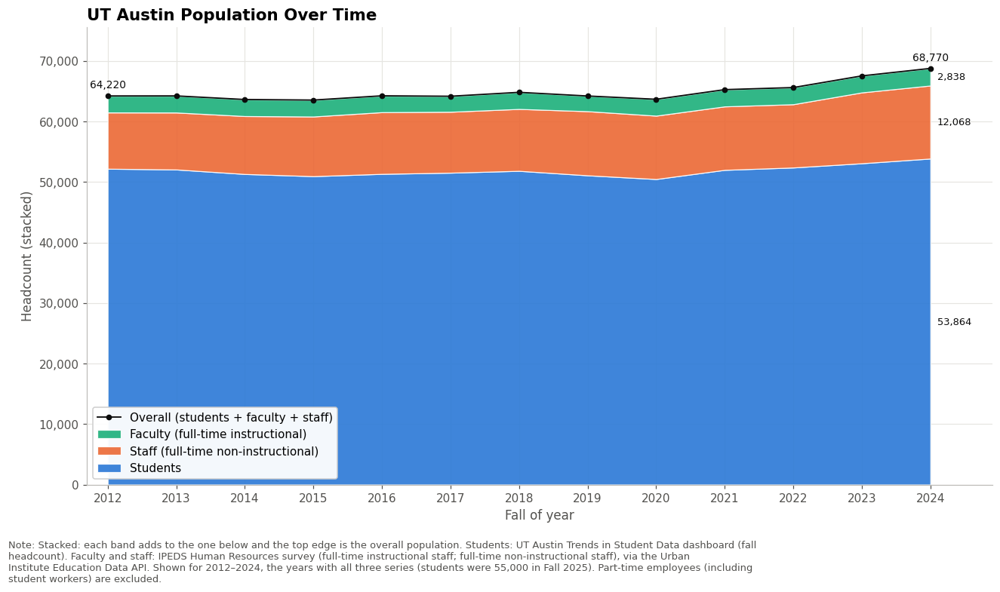

fall_year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Students,50995,51195,51112,52186,52059,51312,50950,51331,51525,51832,51090,50476,51991,52384,53082,53864,55000
Faculty (full-time instructional),2593,2495,2462,2735,2752,2745,2728,2714,2577,2758,2524,2719,2781,2768,2746,2838,<NA>
Staff (full-time non-instructional),<NA>,<NA>,<NA>,9299,9415,9574,9860,10197,10068,10229,10598,10474,10491,10454,11707,12068,<NA>
Overall (students + faculty + staff),<NA>,<NA>,<NA>,64220,64226,63631,63538,64242,64170,64819,64212,63669,65263,65606,67535,68770,<NA>


In [7]:
pop = pd.DataFrame({'Students': students_total, 'Faculty (full-time instructional)': ipeds.ft_instructional_faculty,
                    'Staff (full-time non-instructional)': ipeds.ft_noninstructional_staff})
pop['Overall (students + faculty + staff)'] = pop.sum(axis=1, min_count=3)
layers = [('Students', BLUE), ('Staff (full-time non-instructional)', ORANGE), ('Faculty (full-time instructional)', AQUA)]
stk = pop.dropna(subset=[c for c, _ in layers])
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.stackplot(stk.index, *[stk[c] for c, _ in layers], colors=[c for _, c in layers], labels=[c for c, _ in layers],
             alpha=0.9, edgecolor='white', linewidth=0.8)
total = stk['Overall (students + faculty + staff)']
ax.plot(total.index, total, color=INK, marker='o', ms=4, lw=1.2, label='Overall (students + faculty + staff)')
for yr_ in (total.index[0], total.index[-1]):
    ax.annotate(f'{total[yr_]:,.0f}', (yr_, total[yr_]), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=9, color=INK)
base = 0
for c, _ in layers:                                             # layer sizes at the last year, labelled inside the band
    v = stk[c].iloc[-1]
    ax.annotate(f'{v:,.0f}', (stk.index[-1], base + v / 2), xytext=(6, 0), textcoords='offset points', va='center', fontsize=8.5, color=INK)
    base += v
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set(xlabel='Fall of year', ylabel='Headcount (stacked)', title='UT Austin Population Over Time', ylim=(0, total.max() * 1.1),
       xlim=(stk.index[0] - 0.3, stk.index[-1] + 0.9))
ax.set_xticks(stk.index)
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], loc='lower left', framealpha=0.95, frameon=True)
add_note(fig, 'Stacked: each band adds to the one below and the top edge is the overall population. Students: UT Austin Trends in Student Data '
              'dashboard (fall headcount). Faculty and staff: IPEDS Human Resources survey (full-time instructional staff; full-time '
              'non-instructional staff), via the Urban Institute Education Data API. Shown for 2012–2024, the years with all three series '
              f'(students were {students_total[2025]:,.0f} in Fall 2025). Part-time employees (including student workers) are excluded.', width=150)
save(fig, '1_1a_population')
display(pop.loc[2009:].round(0).astype('Int64').T)

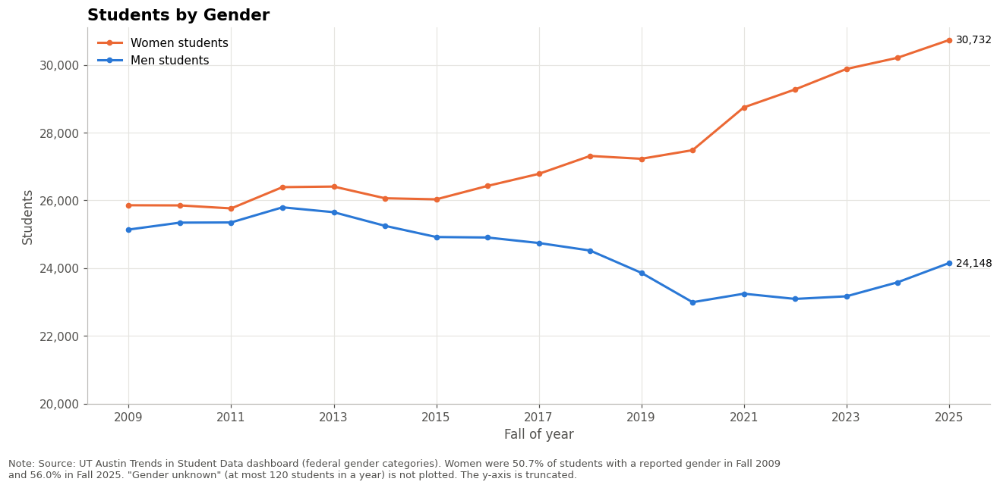

In [8]:
gen = stu_gen.pivot(index='fall_year', columns='gender', values='students')
fig, ax = plt.subplots(figsize=(12, 5.5))
for col, c in [('Women', ORANGE), ('Men', BLUE)]:
    ax.plot(gen.index, gen[col], color=c, marker='o', ms=4, label=f'{col} students')
    ax.annotate(f'{gen[col].iloc[-1]:,.0f}', (gen.index[-1], gen[col].iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', fontsize=9)
share = gen['Women'] / gen[['Women', 'Men']].sum(axis=1) * 100
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set(xlabel='Fall of year', ylabel='Students', title='Students by Gender', ylim=(20_000, None))
ax.set_xticks(range(2009, 2026, 2)); ax.legend(loc='upper left')
add_note(fig, f'Source: UT Austin Trends in Student Data dashboard (federal gender categories). Women were {share.iloc[0]:.1f}% of students '
              f'with a reported gender in Fall {share.index[0]} and {share.iloc[-1]:.1f}% in Fall {share.index[-1]}. '
              f'"Gender unknown" (at most {gen.get("Gender unknown", pd.Series([0])).max():,.0f} students in a year) is not plotted. The y-axis is truncated.', width=150)
save(fig, '1_1b_students_by_gender')

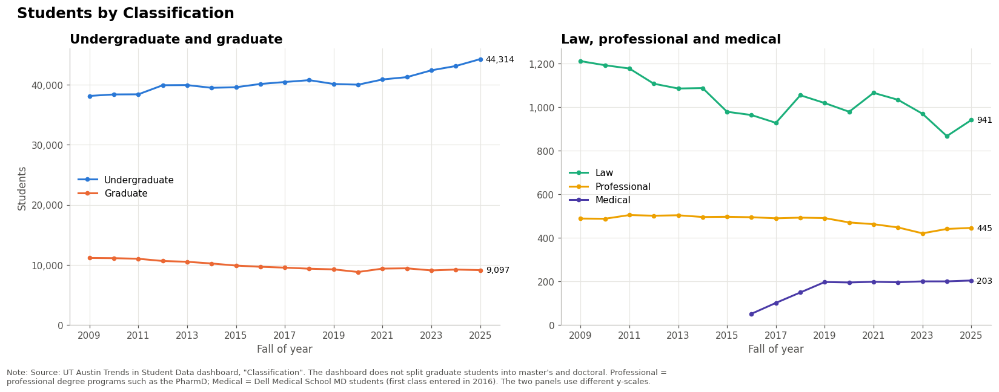

In [9]:
cls = stu_cls.pivot(index='fall_year', columns='classification', values='students')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)
for ax, cols in [(a1, [('Undergraduate', BLUE), ('Graduate', ORANGE)]),
                 (a2, [('Law', AQUA), ('Professional', YELLOW), ('Medical', VIOLET)])]:
    for col, c in cols:
        s = cls[col].dropna()
        ax.plot(s.index, s.values, color=c, marker='o', ms=4, label=col)
        ax.annotate(f'{s.iloc[-1]:,.0f}', (s.index[-1], s.iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', fontsize=9)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')); ax.set_ylim(0, None)
    ax.set_xticks(range(2009, 2026, 2)); ax.legend(loc='center left'); ax.set_xlabel('Fall of year')
a1.set(ylabel='Students', title='Undergraduate and graduate'); a2.set_title('Law, professional and medical')
fig.suptitle('Students by Classification', x=0.01, ha='left', fontsize=16, fontweight='bold')
add_note(fig, 'Source: UT Austin Trends in Student Data dashboard, "Classification". The dashboard does not split graduate students into '
              "master's and doctoral. Professional = professional degree programs such as the PharmD; Medical = Dell Medical School MD "
              'students (first class entered in 2016). The two panels use different y-scales.', width=170)
save(fig, '1_1c_students_by_classification')

### 1.2 Degrees conferred by college, 2024–25

Each college has adjacent bachelor's, master's and doctoral bars. Colleges are ordered by bachelor's degrees; colleges without bachelor's degrees follow, ordered by their total degrees. Law (JD) and special professional degrees (MD, PharmD, AuD) are shown separately below.

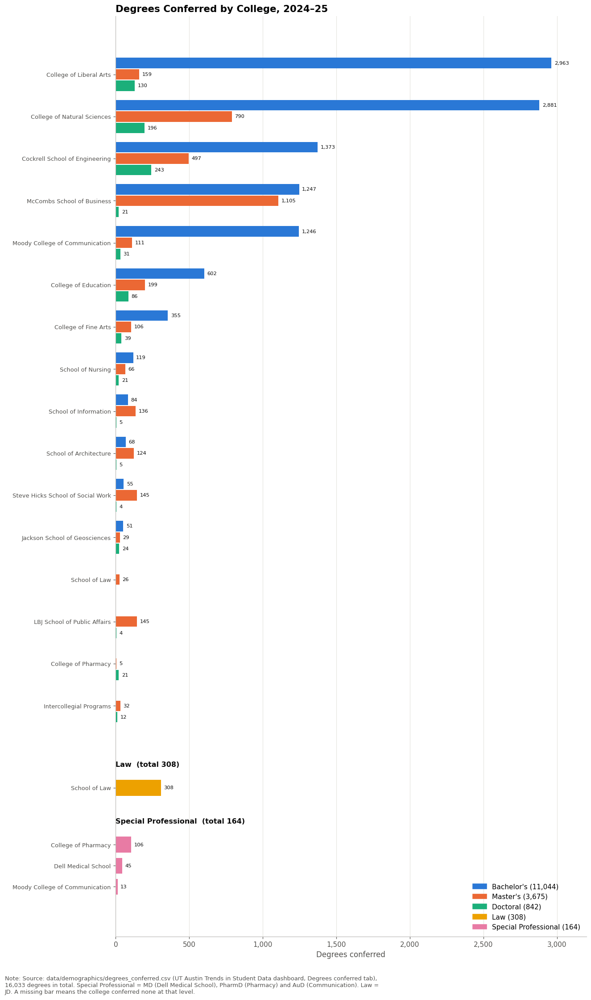

In [10]:
deg = degrees.rename(columns=lambda c: c.strip()).rename(columns={'c.degree school/discipline official': 'college', 'Degree level': 'level',
                                                               'Number of Records': 'degrees'})
deg = deg[['college', 'level', 'degrees']]
LEVELS = ["Bachelor's", "Master's", 'Doctoral', 'Law', 'Special Professional']
LEVEL_COLORS = dict(zip(LEVELS, [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]))
assert set(deg.level) == set(LEVELS)
bach = deg[deg.level == "Bachelor's"].sort_values('degrees', ascending=False).college.tolist()
rest = deg[~deg.college.isin(bach)].groupby('college').degrees.sum().sort_values(ascending=False).index.tolist()
college_order = bach + rest

MAIN, SEP = ["Bachelor's", "Master's", 'Doctoral'], ['Law', 'Special Professional']
wide = deg.pivot_table(index='college', columns='level', values='degrees', aggfunc='sum')
main_colleges = [c for c in college_order if wide.loc[c, MAIN].notna().any()]
H = 0.27                                                        # height of each bar in a college's triple
fig, ax = plt.subplots(figsize=(12, 0.95 * len(main_colleges) + 0.42 * 6 + 2))
ticks, labels, y = [], [], 0
for college in main_colleges:
    for j, level in enumerate(MAIN):
        v = wide.loc[college, level]
        if pd.notna(v):
            yy = y + (j - 1) * H
            ax.barh(yy, v, height=H * 0.92, color=LEVEL_COLORS[level])
            ax.text(v + 20, yy, f'{v:,.0f}', va='center', fontsize=7.5, color=INK)
    ticks.append(y); labels.append(college); y += 1
y += 0.4
for level in SEP:                                                # law and special professional stay as separate groups
    ax.text(0, y, f'{level}  (total {deg[deg.level == level].degrees.sum():,})', va='center', fontsize=10.5, fontweight='bold', color=INK)
    y += 0.55
    for college, v in deg[deg.level == level].set_index('college').degrees.sort_values(ascending=False).items():
        ax.barh(y, v, height=H * 1.4, color=LEVEL_COLORS[level])
        ax.text(v + 20, y, f'{v:,}', va='center', fontsize=7.5, color=INK)
        ticks.append(y); labels.append(college); y += 0.5
    y += 0.3
ax.set_yticks(ticks, labels, fontsize=8.5); ax.invert_yaxis(); ax.grid(axis='y', visible=False)
ax.set(xlabel='Degrees conferred', title='Degrees Conferred by College, 2024–25', xlim=(0, deg.degrees.max() * 1.08))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.legend(handles=[Patch(color=LEVEL_COLORS[l], label=f'{l} ({deg[deg.level == l].degrees.sum():,})') for l in LEVELS], loc='lower right')
add_note(fig, f'Source: data/demographics/degrees_conferred.csv (UT Austin Trends in Student Data dashboard, Degrees conferred tab), '
              f'{deg.degrees.sum():,} degrees in total. Special Professional = MD (Dell Medical School), PharmD (Pharmacy) and AuD (Communication). '
              f'Law = JD. A missing bar means the college conferred none at that level.', width=125)
save(fig, '1_2_degrees_conferred')

### 1.3 Where students come from: Texas counties (Fall 2025)

Enrollment counts are from the Maps tab of UT's [Trends in Student Data](https://reports.utexas.edu/spotlight-data/students) dashboard (`data/demographics/county_enrollment.csv`), which also produced the map below (`figures/texas_map.pdf`). **Fall 2025 was the most recent data available.** County populations are Census estimates for July 1, 2025.

**UT dashboard map (figures/texas_map.pdf):**

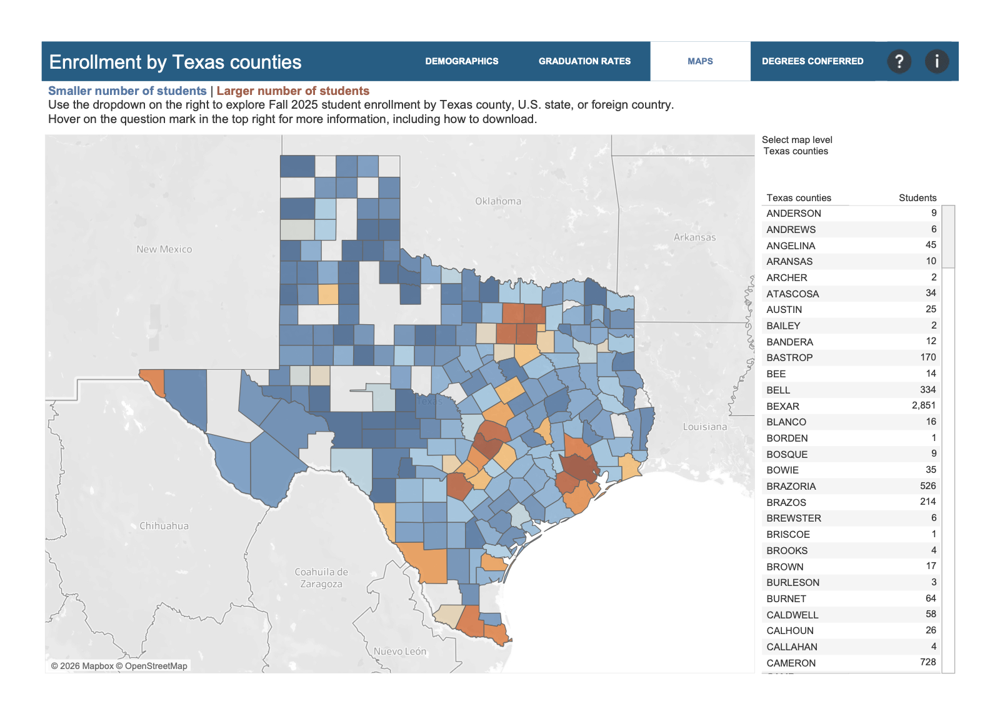

**Top 10 Texas counties by number of UT students, Fall 2025**

County,Students,Population (2025)
Harris,"7,184","5,045,026"
Travis,"5,952","1,389,670"
Dallas,"3,516","2,661,397"
Collin,"3,259","1,297,179"
Bexar,"2,851","2,160,088"
Fort Bend,"2,771","975,191"
Williamson,"2,356","752,827"
Tarrant,"2,266","2,248,466"
Denton,"1,754","1,069,346"
Hidalgo,"1,086","921,549"


**Texas counties with no UT students in Fall 2025: 35 of 254 counties** (combined population 144,975)

County,Population (2025)
Tyler,"20,443"
Zapata,"13,753"
Terry,"11,720"
Sabine,"10,012"
Coleman,"7,915"
Swisher,"6,703"
Lynn,"6,017"
Carson,"5,805"
Delta,"5,549"
Haskell,"5,499"


In [11]:
pdf_png = f'{FIG_DIR}/texas_map.png'
if not os.path.exists(pdf_png) and shutil.which('sips'):          # macOS: render the dashboard PDF for display
    subprocess.run(['sips', '-s', 'format', 'png', '-Z', '1600', f'{FIG_DIR}/texas_map.pdf', '--out', pdf_png], capture_output=True)
display(Markdown('**UT dashboard map (figures/texas_map.pdf):**'))
display(Image(pdf_png, width=900))

key = lambda s: re.sub(r'[^A-Z]', '', s.upper())
tx = tx_pop.copy()
tx['students'] = tx.county.map(key).map(county_enr.set_index(county_enr['Texas counties'].map(key))['Number of Records']).fillna(0).astype(int)
tx['per_10k'] = tx.students / tx.population_2025 * 1e4
assert tx.students.sum() == county_enr['Number of Records'].sum(), 'a county failed to match'
fmt_tbl = {'Students': '{:,}', 'Population (2025)': '{:,}', 'Students per 10,000 residents': '{:.2f}'}
tx_tbl = tx.rename(columns={'county': 'County', 'students': 'Students', 'population_2025': 'Population (2025)', 'per_10k': 'Students per 10,000 residents'})

display(Markdown('**Top 10 Texas counties by number of UT students, Fall 2025**'))
display(tx_tbl.nlargest(10, 'Students')[['County', 'Students', 'Population (2025)']].style.hide(axis='index').format(fmt_tbl))
zero = tx_tbl[tx_tbl.Students == 0].sort_values('Population (2025)', ascending=False)
display(Markdown(f'**Texas counties with no UT students in Fall 2025: {len(zero)} of {len(tx)} counties** '
                 f'(combined population {zero["Population (2025)"].sum():,})'))
display(zero[['County', 'Population (2025)']].style.hide(axis='index').format(fmt_tbl))

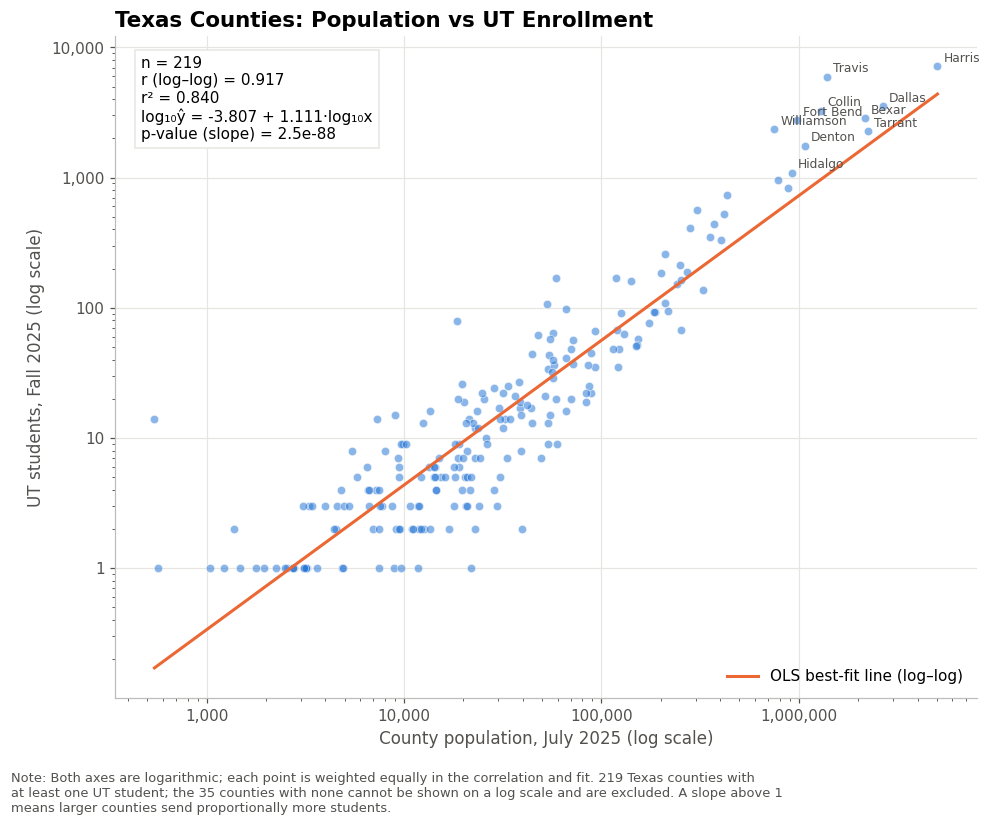

**Top 10 Texas counties by UT students per 10,000 residents, Fall 2025**

County,"Students per 10,000 residents",Students,Population (2025)
McMullen,257.35,14,544
Travis,42.83,"5,952","1,389,670"
Deaf Smith,42.41,79,"18,626"
Williamson,31.30,"2,356","752,827"
Maverick,28.90,170,"58,823"
Fort Bend,28.41,"2,771","975,191"
Collin,25.12,"3,259","1,297,179"
Kendall,19.89,106,"53,289"
Castro,19.19,14,"7,295"
Hays,18.50,563,"304,390"


In [12]:
has = tx[tx.students > 0]
fit_scatter(has.population_2025, has.students, has.county.str.title(), 'County population, July 2025 (log scale)',
            'UT students, Fall 2025 (log scale)', 'Texas Counties: Population vs UT Enrollment', '1_3a_tx_county_scatter',
            f'{len(has)} Texas counties with at least one UT student; the {len(tx) - len(has)} counties with none cannot be shown on a log '
            f'scale and are excluded. A slope above 1 means larger counties send proportionally more students.')

display(Markdown('**Top 10 Texas counties by UT students per 10,000 residents, Fall 2025**'))
display(tx_tbl.nlargest(10, 'Students per 10,000 residents')[['County', 'Students per 10,000 residents', 'Students', 'Population (2025)']]
        .style.hide(axis='index').format(fmt_tbl))

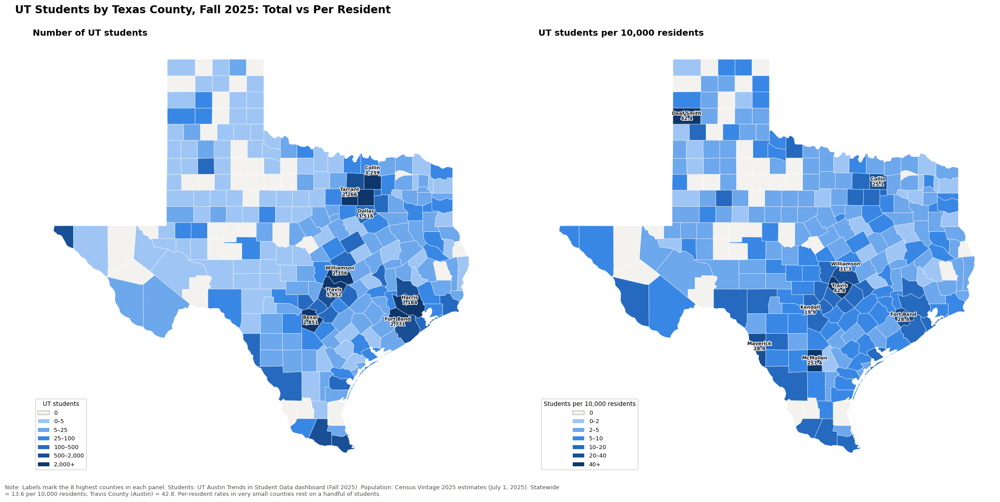

In [13]:
TX_COUNT_BINS, TX_BINS = [0, 5, 25, 100, 500, 2000, np.inf], [0, 2, 5, 10, 20, 40, np.inf]
feats = geo['tx_counties']['features']
names = tx.set_index('fips').county.to_dict()
fig, axes = plt.subplots(1, 2, figsize=(21, 10))
for ax, col, bins, title, legend, fmt in [
        (axes[0], 'students', TX_COUNT_BINS, 'Number of UT students', 'UT students', lambda v: f'{v:,.0f}'),
        (axes[1], 'per_10k', TX_BINS, 'UT students per 10,000 residents', 'Students per 10,000 residents', lambda v: f'{v:.1f}')]:
    vals = tx.set_index('fips')[col]
    draw_map(ax, feats, lambda f: f['id'], class_colors(vals.to_dict(), bins), lw=0.4)
    ax.set_aspect(1 / np.cos(np.deg2rad(31)))
    ax.set_title(title, fontsize=13)
    map_legend(ax, bins, lambda v: f'{v:,.0f}' if v >= 1 else f'{v:g}', legend)
    label_top(ax, feats, lambda f: f['id'], vals.to_dict(), names, 8, fmt)
fig.suptitle('UT Students by Texas County, Fall 2025: Total vs Per Resident', x=0.01, ha='left', fontsize=16, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.96))
travis = tx.set_index('county').loc['Travis']
add_note(fig, f'Labels mark the 8 highest counties in each panel. Students: UT Austin Trends in Student Data dashboard (Fall 2025). Population: '
              f'Census Vintage 2025 estimates (July 1, 2025). Statewide = {tx.students.sum() / tx.population_2025.sum() * 1e4:.1f} per 10,000 '
              f'residents; Travis County (Austin) = {travis.per_10k:.1f}. Per-resident rates in very small counties rest on a handful of students.',
         width=190, layout=False)
save(fig, '1_3b_tx_county_maps')

### 1.4 Where students come from: U.S. states (Fall 2025)

Texas is not in the state file (in-state students are in §1.3), so it is excluded from the tables and hatched on the map. Puerto Rico's population comes from the World Bank (it is not in the Census county/state file). Fall 2025 was the most recent data available.

In [14]:
st = state_pop[state_pop.state != 'Texas'].copy()
st = pd.concat([st, pd.DataFrame([{'fips': '72', 'state': 'Puerto Rico',
                                    'population_2025': int(world_pop.set_index('iso3').loc['PRI', 'population'])}])], ignore_index=True)
skey = lambda s: re.sub(r'[^A-Z]', '', s.upper().replace('DIST ', 'DISTRICT OF '))
st['students'] = st.state.map(skey).map(state_enr.set_index(state_enr['U.S. state'].map(skey))['Number of Records']).fillna(0).astype(int)
assert st.students.sum() == state_enr['Number of Records'].sum(), 'a state failed to match'
st['per_100k'] = st.students / st.population_2025 * 1e5
st_tbl = st.rename(columns={'state': 'State', 'students': 'Students', 'population_2025': 'Population (2025)', 'per_100k': 'Students per 100,000 residents'})
fmt_st = {'Students': '{:,}', 'Population (2025)': '{:,}', 'Students per 100,000 residents': '{:.2f}'}
cols_st = ['State', 'Students', 'Students per 100,000 residents', 'Population (2025)']
t1 = st_tbl.sort_values('Students', ascending=False)[cols_st].reset_index(drop=True); t1.index += 1
t2 = st_tbl.sort_values('Students per 100,000 residents', ascending=False)[cols_st].reset_index(drop=True); t2.index += 1
display(Markdown(f'**UT students by state (not population-adjusted), Fall 2025 — {len(st)} states/territories, excluding Texas**'))
display(t1.style.format(fmt_st))
display(Markdown('**UT students per 100,000 residents by state, Fall 2025**'))
display(t2.style.format(fmt_st))

**UT students by state (not population-adjusted), Fall 2025 — 51 states/territories, excluding Texas**

,State,Students,"Students per 100,000 residents",Population (2025)
1,California,"1,232",3.13,"39,355,309"
2,New York,629,3.14,"20,002,427"
3,Illinois,356,2.80,"12,719,141"
4,New Jersey,347,3.63,"9,548,215"
5,Florida,326,1.39,"23,462,518"
6,Georgia,219,1.94,"11,302,748"
7,Virginia,201,2.26,"8,880,107"
8,Pennsylvania,161,1.23,"13,059,432"
9,Maryland,158,2.52,"6,265,347"
10,Massachusetts,150,2.10,"7,154,084"


**UT students per 100,000 residents by state, Fall 2025**

,State,Students,"Students per 100,000 residents",Population (2025)
1,District of Columbia,43,6.20,"693,645"
2,Connecticut,141,3.82,"3,688,496"
3,New Jersey,347,3.63,"9,548,215"
4,New York,629,3.14,"20,002,427"
5,California,"1,232",3.13,"39,355,309"
6,Illinois,356,2.80,"12,719,141"
7,New Mexico,57,2.68,"2,125,498"
8,Maryland,158,2.52,"6,265,347"
9,Colorado,148,2.46,"6,012,561"
10,Utah,81,2.29,"3,538,904"


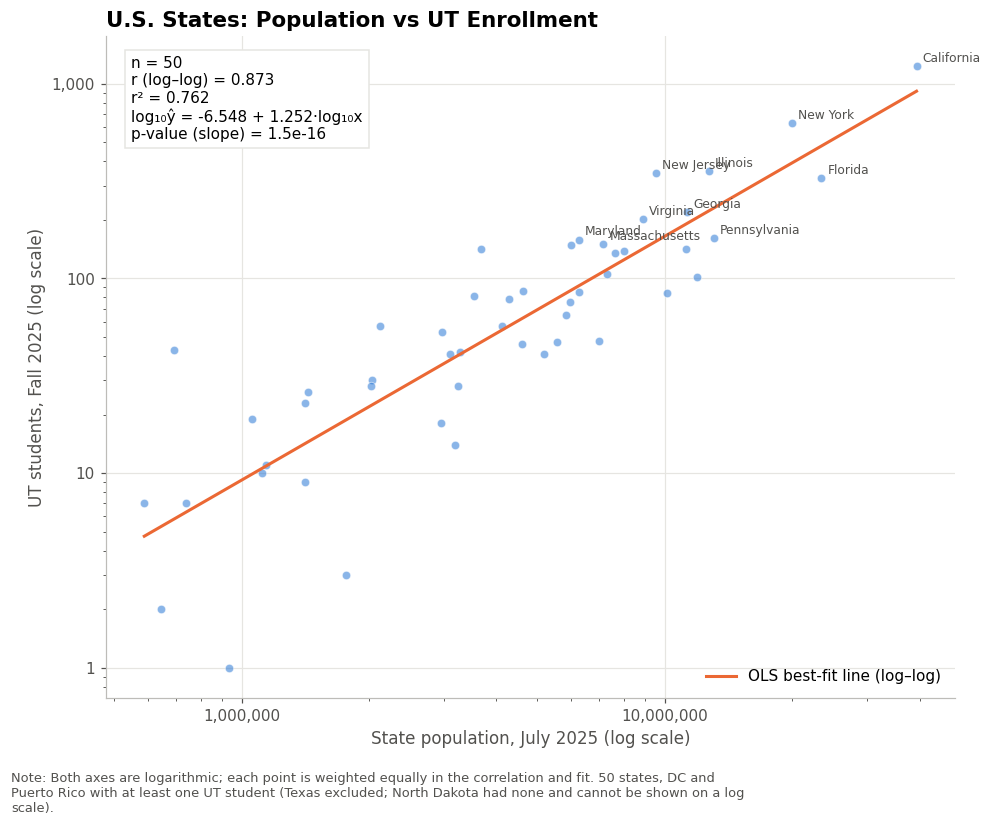

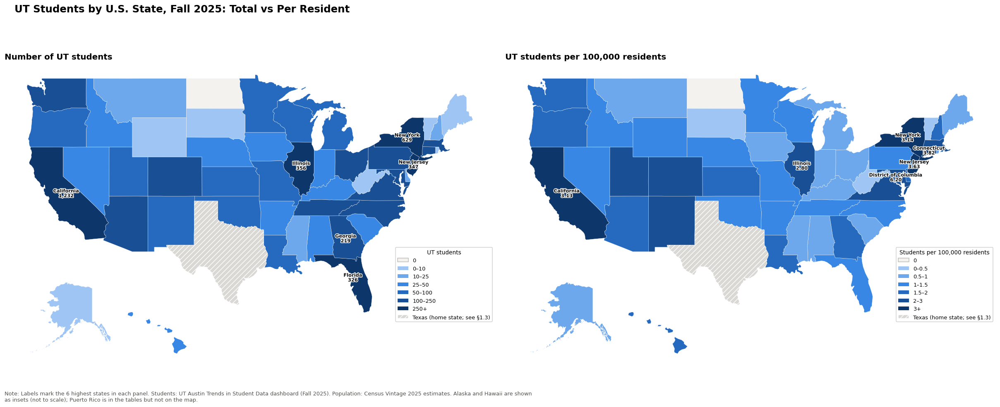

In [15]:
has = st[st.students > 0]
fit_scatter(has.population_2025, has.students, has.state, 'State population, July 2025 (log scale)', 'UT students, Fall 2025 (log scale)',
            'U.S. States: Population vs UT Enrollment', '1_4a_state_scatter',
            f'{len(has)} states, DC and Puerto Rico with at least one UT student (Texas excluded; '
            f'{", ".join(st[st.students == 0].state)} had none and cannot be shown on a log scale).')

ST_COUNT_BINS, ST_BINS = [0, 10, 25, 50, 100, 250, np.inf], [0, 0.5, 1, 1.5, 2, 3, np.inf]
feats = [f for f in geo['us_states']['features'] if f['properties']['name'] != 'Puerto Rico']
main = [f for f in feats if f['properties']['name'] not in ('Alaska', 'Hawaii')]
skey = lambda f: f['properties']['name']
fig = plt.figure(figsize=(22, 8.5))
for i, (col, bins, title, legend, fmt) in enumerate([
        ('students', ST_COUNT_BINS, 'Number of UT students', 'UT students', lambda v: f'{v:,.0f}'),
        ('per_100k', ST_BINS, 'UT students per 100,000 residents', 'Students per 100,000 residents', lambda v: f'{v:.2f}')]):
    vals = st.set_index('state')[col].to_dict()
    cols = class_colors(vals, bins)
    left = i * 0.5
    ax = fig.add_axes([left, 0.1, 0.49, 0.8])
    draw_map(ax, main, skey, cols)
    ax.set_aspect(1 / np.cos(np.deg2rad(38)))
    ax.set_title(title, fontsize=13)
    label_top(ax, main, skey, vals, {}, 6, fmt, fontsize=7.5)
    for name, rect, lat in [('Alaska', [left + 0.01, 0.08, 0.11, 0.2], 62), ('Hawaii', [left + 0.12, 0.08, 0.065, 0.12], 20)]:
        ia = fig.add_axes(rect)
        draw_map(ia, [f for f in feats if f['properties']['name'] == name], skey, cols, shift_lon=(name == 'Alaska'))
        ia.set_aspect(1 / np.cos(np.deg2rad(lat)))
        if name == 'Alaska':
            ia.set_xlim(-180, -129)
    map_legend(ax, bins, lambda v: f'{v:g}', legend, missing_label='Texas (home state; see §1.3)', loc='lower right')
fig.suptitle('UT Students by U.S. State, Fall 2025: Total vs Per Resident', x=0.01, y=0.99, ha='left', fontsize=16, fontweight='bold')
add_note(fig, 'Labels mark the 6 highest states in each panel. Students: UT Austin Trends in Student Data dashboard (Fall 2025). Population: '
              'Census Vintage 2025 estimates. Alaska and Hawaii are shown as insets (not to scale); Puerto Rico is in the tables but not on the map.',
         width=190, layout=False)
save(fig, '1_4b_state_maps')

### 1.5 Where students come from: countries (Fall 2025)

Dashboard country names are matched to ISO codes by hand (below). Northern Ireland (1 student) and Abu Dhabi (2) are folded into the United Kingdom and the United Arab Emirates, and Christmas Island (1) into Australia. Populations are World Bank 2025 figures (Taiwan: Ministry of the Interior, September 2025). The United States is not in the file. Fall 2025 was the most recent data available.

**Educated-population adjustment:** the last table divides UT students by each country's number of students enrolled in college (tertiary education: short-cycle, bachelor's, master's and doctoral programs), from UNESCO's Institute for Statistics. That is the pool of people currently in college, the group UT recruits from. Each country uses its latest available year (mostly 2023–2024; the year is shown), so it is an approximation of Fall 2025 college enrollment.

In [16]:
ISO3 = {
    'ABU-DHABI': 'ARE', 'AFGHANISTAN': 'AFG', 'ALBANIA': 'ALB', 'ALGERIA': 'DZA', 'ANGOLA': 'AGO', 'ARGENTINA': 'ARG', 'ARMENIA': 'ARM',
    'AUSTRALIA': 'AUS', 'AUSTRIA': 'AUT', 'AZERBAIJAN': 'AZE', 'BAHAMAS': 'BHS', 'BAHRAIN': 'BHR', 'BANGLADESH': 'BGD', 'BELARUS': 'BLR',
    'BELGIUM': 'BEL', 'BELIZE': 'BLZ', 'BOLIVIA': 'BOL', 'BOTSWANA': 'BWA', 'BRAZIL': 'BRA', 'CAMBODIA': 'KHM', 'CAMEROON': 'CMR',
    'CANADA': 'CAN', 'CHILE': 'CHL', "CHINA, PEOPLE'S REPUBLIC": 'CHN', 'CHRISTMAS ISLAND': 'AUS', 'COLOMBIA': 'COL', 'COSTA RICA': 'CRI',
    "COTE D'IVOIRE": 'CIV', 'CROATIA': 'HRV', 'CYPRUS': 'CYP', 'CZECH REPUBLIC': 'CZE', 'DENMARK': 'DNK', 'DOMINICA': 'DMA',
    'DOMINICAN REPUBLIC': 'DOM', 'ECUADOR': 'ECU', 'EGYPT (A.R.E.)': 'EGY', 'EL SALVADOR': 'SLV', 'ESTONIA': 'EST', 'ETHIOPIA': 'ETH',
    'FINLAND': 'FIN', 'FRANCE': 'FRA', 'GEORGIA (C.I.S.)': 'GEO', 'GERMANY': 'DEU', 'GHANA': 'GHA', 'GREECE': 'GRC', 'GUATEMALA': 'GTM',
    'HONDURAS': 'HND', 'HONG KONG': 'HKG', 'HUNGARY': 'HUN', 'ICELAND': 'ISL', 'INDIA': 'IND', 'INDONESIA': 'IDN', 'IRAN': 'IRN',
    'IRAQ': 'IRQ', 'IRELAND': 'IRL', 'ISRAEL': 'ISR', 'ITALY': 'ITA', 'JAMAICA': 'JAM', 'JAPAN': 'JPN', 'JORDAN': 'JOR',
    'KAZAKHSTAN': 'KAZ', 'KENYA': 'KEN', 'KOREA, REPUBLIC OF': 'KOR', 'KUWAIT': 'KWT', 'KYRGYZSTAN': 'KGZ', 'LEBANON': 'LBN',
    'LITHUANIA': 'LTU', 'MACAO': 'MAC', 'MACEDONIA': 'MKD', 'MADAGASCAR': 'MDG', 'MALAYSIA': 'MYS', 'MALDIVES': 'MDV', 'MAURITIUS': 'MUS',
    'MEXICO': 'MEX', 'MOROCCO': 'MAR', 'MYANMAR': 'MMR', 'NAMIBIA': 'NAM', 'NEPAL': 'NPL', 'NETHERLANDS': 'NLD', 'NEW ZEALAND': 'NZL',
    'NICARAGUA': 'NIC', 'NIGERIA': 'NGA', 'NORTHERN IRELAND': 'GBR', 'NORWAY': 'NOR', 'OMAN': 'OMN', 'PAKISTAN': 'PAK', 'PANAMA': 'PAN',
    'PARAGUAY': 'PRY', 'PERU': 'PER', 'PHILIPPINES': 'PHL', 'POLAND': 'POL', 'PORTUGAL': 'PRT', 'QATAR': 'QAT', 'ROMANIA': 'ROU',
    'RUSSIA': 'RUS', 'RWANDA': 'RWA', 'SAUDI ARABIA': 'SAU', 'SERBIA': 'SRB', 'SINGAPORE': 'SGP', 'SLAVAKIA': 'SVK', 'SLOVENIA': 'SVN',
    'SOUTH AFRICA': 'ZAF', 'SPAIN': 'ESP', 'SRI LANKA': 'LKA', 'ST. LUCIA': 'LCA', 'SWEDEN': 'SWE', 'SWITZERLAND': 'CHE', 'SYRIA': 'SYR',
    'TAIWAN': 'TWN', 'TANZANIA': 'TZA', 'THAILAND': 'THA', 'TRINIDAD & TOBAGO': 'TTO', 'TUNISIA': 'TUN', 'TURKEY': 'TUR', 'UGANDA': 'UGA',
    'UKRAINE': 'UKR', 'UNITED ARAB EMIRATES': 'ARE', 'UNITED KINGDOM': 'GBR', 'VENEZUELA': 'VEN', 'VIET NAM SOCIALIST REPUB': 'VNM',
    'YEMEN': 'YEM', 'ZIMBABWE': 'ZWE'}
unmapped = set(nation_enr.Countries) - set(ISO3)
assert not unmapped, unmapped
ne = nation_enr.assign(iso3=nation_enr.Countries.map(ISO3)).groupby('iso3')['Number of Records'].sum()
US_AND_TERRITORIES = ['USA', 'PRI', 'GUM', 'VIR', 'ASM', 'MNP']        # domestic: Puerto Rico is in the state file (§1.4)
wp = world_pop[~world_pop.iso3.isin(US_AND_TERRITORIES)].set_index('iso3')
assert set(ne.index) <= set(wp.index), set(ne.index) - set(wp.index)
nat = wp.assign(students=ne.reindex(wp.index).fillna(0).astype(int))
nat['per_million'] = nat.students / nat.population * 1e6
nat_tbl = nat.reset_index().rename(columns={'country': 'Country', 'students': 'Students', 'population': 'Population (2025)',
                                            'per_million': 'Students per million residents'})
fmt_n = {'Students': '{:,}', 'Population (2025)': '{:,.0f}', 'Students per million residents': '{:.2f}'}
cols_n = ['Country', 'Students', 'Students per million residents', 'Population (2025)']
for title, sort in [('Top 20 countries by number of UT students, Fall 2025', 'Students'),
                    ('Top 20 countries by UT students per million residents, Fall 2025', 'Students per million residents')]:
    t = nat_tbl.nlargest(20, sort)[cols_n].reset_index(drop=True); t.index += 1
    display(Markdown(f'**{title}**')); display(t.style.format(fmt_n))
zero_n = nat_tbl[nat_tbl.Students == 0].sort_values('Population (2025)', ascending=False)
display(Markdown(f'**Countries and territories with no UT students in Fall 2025: {len(zero_n)} of {len(nat_tbl)}** '
                 f'(World Bank economies plus Taiwan, excluding the U.S. and its territories; combined population {zero_n["Population (2025)"].sum() / 1e6:,.0f} million)'))
display(zero_n[['Country', 'Population (2025)']].reset_index(drop=True).style.format(fmt_n))

tert = pd.read_csv(f'{REF_DIR}/tertiary_enrollment_uis.csv').set_index('iso3').rename(columns={'year': 'college_year'})
edu = nat[nat.students > 0].join(tert, how='left')
no_edu = edu[edu.tertiary_students.isna()]
edu = edu.dropna(subset=['tertiary_students'])
edu['per_100k_college'] = edu.students / edu.tertiary_students * 1e5
t = (edu.nlargest(20, 'per_100k_college').reset_index()
     .rename(columns={'country': 'Country', 'students': 'UT students', 'per_100k_college': 'UT students per 100,000 college students',
                      'tertiary_students': 'College students in country', 'college_year': 'College data year', 'per_million': 'UT students per million residents'})
     [['Country', 'UT students', 'UT students per 100,000 college students', 'College students in country', 'College data year',
       'UT students per million residents']])
t.index += 1
display(Markdown('**Top 20 countries by UT students per 100,000 college students in the country, Fall 2025**'))
display(t.style.format({'UT students': '{:,}', 'UT students per 100,000 college students': '{:.2f}', 'College students in country': '{:,.0f}',
                        'College data year': '{:.0f}', 'UT students per million residents': '{:.2f}'}))
display(Markdown(f'Countries with UT students but no college-enrollment data since 2005 (excluded from this table): '
                 + ', '.join(f'{r.country} ({r.students})' for _, r in no_edu.sort_values('students', ascending=False).iterrows()) + '.'))

**Top 20 countries by number of UT students, Fall 2025**

,Country,Students,Students per million residents,Population (2025)
1,China,"1,239",0.88,"1,406,585,000"
2,India,975,0.67,"1,463,865,525"
3,"Korea, Rep.",553,10.70,"51,684,564"
4,Mexico,303,2.30,"131,946,900"
5,Taiwan,239,10.25,"23,317,031"
6,Canada,129,3.10,"41,651,653"
7,Brazil,107,0.50,"212,812,405"
8,Nigeria,97,0.41,"237,527,782"
9,United Kingdom,90,1.30,"69,487,000"
10,Viet Nam,89,0.88,"101,598,527"


**Top 20 countries by UT students per million residents, Fall 2025**

,Country,Students,Students per million residents,Population (2025)
1,Dominica,1,15.18,"65,871"
2,"Korea, Rep.",553,10.70,"51,684,564"
3,Taiwan,239,10.25,"23,317,031"
4,Panama,33,7.22,"4,571,189"
5,"Macao SAR, China",4,5.83,"685,900"
6,Singapore,34,5.56,"6,111,175"
7,St. Lucia,1,5.55,"180,149"
8,Iceland,2,5.10,"392,404"
9,"Bahamas, The",2,4.96,"403,033"
10,Belize,2,4.73,"422,924"


**Countries and territories with no UT students in Fall 2025: 93 of 212** (World Bank economies plus Taiwan, excluding the U.S. and its territories; combined population 668 million)

,Country,Population (2025)
0,"Congo, Dem. Rep.","112,832,473"
1,Sudan,"51,662,147"
2,Uzbekistan,"37,053,428"
3,Mozambique,"35,631,653"
4,Niger,"27,917,831"
5,"Korea, Dem. People's Rep.","26,571,036"
6,Mali,"25,198,821"
7,Burkina Faso,"24,074,580"
8,Malawi,"22,216,120"
9,Zambia,"21,913,874"


**Top 20 countries by UT students per 100,000 college students in the country, Fall 2025**

,Country,UT students,"UT students per 100,000 college students",College students in country,College data year,UT students per million residents
1,St. Lucia,1,50.20,"1,992",2023,5.55
2,Trinidad and Tobago,5,22.34,"22,384",2024,3.66
3,Taiwan,239,20.96,"1,140,089",2022,10.25
4,Belize,2,20.37,"9,819",2024,4.73
5,"Korea, Rep.",553,20.26,"2,729,517",2024,10.70
6,Singapore,34,17.49,"194,409",2023,5.56
7,Panama,33,17.22,"191,589",2023,7.22
8,Iceland,2,9.86,"20,287",2023,5.10
9,Jamaica,7,9.39,"74,537",2015,2.47
10,Denmark,21,7.22,"290,902",2024,3.49


Countries with UT students but no college-enrollment data since 2005 (excluded from this table): Bolivia (11), Bahamas, The (2), Dominica (1).

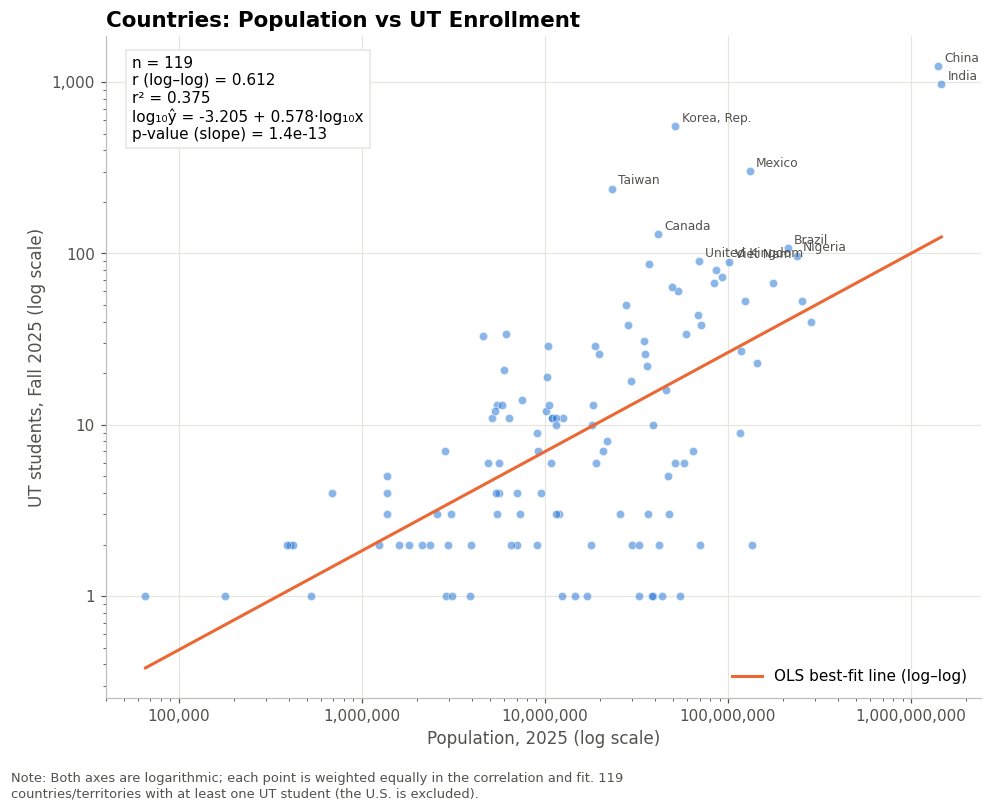

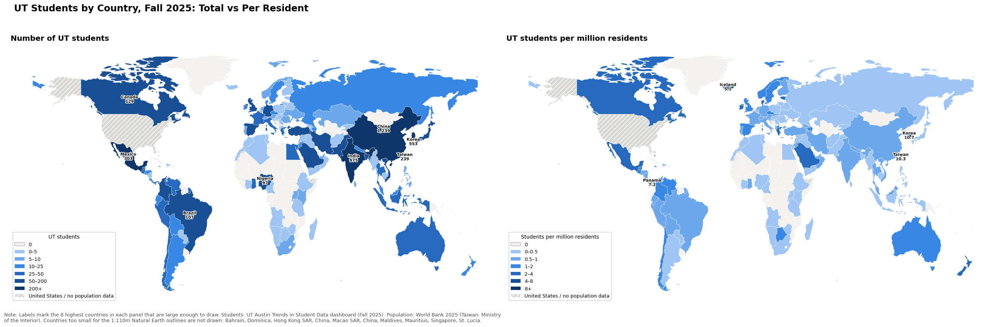

In [17]:
has = nat[nat.students > 0]
fit_scatter(has.population, has.students, has.country, 'Population, 2025 (log scale)', 'UT students, Fall 2025 (log scale)',
            'Countries: Population vs UT Enrollment', '1_5a_country_scatter',
            f'{len(has)} countries/territories with at least one UT student (the U.S. is excluded).')

W_COUNT_BINS, W_BINS = [0, 5, 10, 25, 50, 200, np.inf], [0, 0.5, 1, 2, 4, 8, np.inf]
feats = [f for f in geo['world_countries']['features'] if f['properties']['ADM0_A3'] != 'ATA']
nekey = lambda f: {'SDS': 'SSD', 'KOS': 'XKX', 'PSX': 'PSE'}.get(f['properties']['ADM0_A3'], f['properties']['ADM0_A3'])
short_names = nat.country.str.replace(r',.*$', '', regex=True).to_dict()      # "Korea, Rep." → "Korea"
fig, axes = plt.subplots(1, 2, figsize=(24, 7.5))
for ax, col, bins, title, legend, fmt in [
        (axes[0], 'students', W_COUNT_BINS, 'Number of UT students', 'UT students', lambda v: f'{v:,.0f}'),
        (axes[1], 'per_million', W_BINS, 'UT students per million residents', 'Students per million residents', lambda v: f'{v:.1f}')]:
    vals = nat[col].to_dict()
    draw_map(ax, feats, nekey, class_colors(vals, bins), lw=0.3)
    ax.set_title(title, fontsize=13)
    map_legend(ax, bins, lambda v: f'{v:g}', legend, missing_label='United States / no population data')
    label_top(ax, feats, nekey, vals, short_names, 8, fmt)
fig.suptitle('UT Students by Country, Fall 2025: Total vs Per Resident', x=0.01, ha='left', fontsize=16, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.95))
drawn = {nekey(f) for f in feats}
small = nat[(nat.students > 0) & ~nat.index.isin(drawn)].country.tolist()
add_note(fig, 'Labels mark the 8 highest countries in each panel that are large enough to draw. Students: UT Austin Trends in Student Data '
              'dashboard (Fall 2025). Population: World Bank 2025 (Taiwan: Ministry of the Interior). Countries too small for the 1:110m '
              f'Natural Earth outlines are not drawn: {", ".join(small)}.', width=200, layout=False)
save(fig, '1_5b_country_maps')

### 1.6 Graduate admissions, S/Fall 2025 cycle

*Selectivity* = admitted ÷ applied (lower = more competitive); *yield* = enrolled ÷ admitted. The competitiveness ranking is limited to programs with at least 50 applicants.

238 programs; 124 with ≥ 50 applicants. Totals: 45,379 applied, 9,288 admitted, 4,784 enrolled.


**Top 20 most competitive graduate programs (lowest selectivity, ≥ 50 applicants)**

,School,Program,Applied,Admitted,Enrolled,Selectivity,Yield
1,Liberal Arts,Psychology - Clinical (683501),440,4,4,0.91%,100.00%
2,Education,Educational Psychology - Counseling (PhD) (632344),185,3,3,1.62%,100.00%
3,Intercollegial,Writing (693500),845,15,12,1.78%,80.00%
4,Architecture,Architecture Ph.D. (609400),132,3,1,2.27%,33.33%
5,Education,"Educational Psychology, School/Clinical Child Psychology (PhD) (632356)",154,4,3,2.60%,75.00%
6,Education,"Educational Psychology - Human Development, Culture, and Learning Sciences (PhD Only) (632345)",75,2,2,2.67%,100.00%
7,Architecture,Community and Regional Planning (PhD) (625399),111,3,2,2.70%,66.67%
8,Liberal Arts,Creative Writing (639302),469,15,6,3.20%,40.00%
9,Business,"Information, Risk, and Operations Management (617130)",220,8,6,3.64%,75.00%
10,Business,Finance (617100),183,7,3,3.83%,42.86%


**Top 20 graduate programs by number enrolled**

,School,Program,Applied,Admitted,Enrolled,Selectivity,Yield
1,Natural Sciences,"Artificial Intelligence (MSAI, Option III) (627830)","3,035",628,433,20.69%,68.95%
2,Natural Sciences,"Computer Science (MSCompSci, Option III) (627820)","2,118",679,417,32.06%,61.41%
3,Natural Sciences,"Data Science (MSDS, Option III) (627825)","1,620",375,228,23.15%,60.80%
4,Business,"Business Administration (MBA, First Year) (B15510)","2,524",769,225,30.47%,29.26%
5,Social Work,Social Work (691200),505,248,159,49.11%,64.11%
6,Business,Professional Accounting (B01100),483,224,137,46.38%,61.16%
7,Business,Business Analytics - Option III (617170),"1,066",267,126,25.05%,47.19%
8,Business,"Accounting-Professional Program, Fifth Year (B00802)",124,124,122,100.00%,98.39%
9,Engineering,"Electrical and Computer Engineering (MSE, PhD) (634700)","2,693",288,121,10.69%,42.01%
10,Business,"Business Administration, Evening (MBA, Option III) (B16121)",233,179,119,76.82%,66.48%


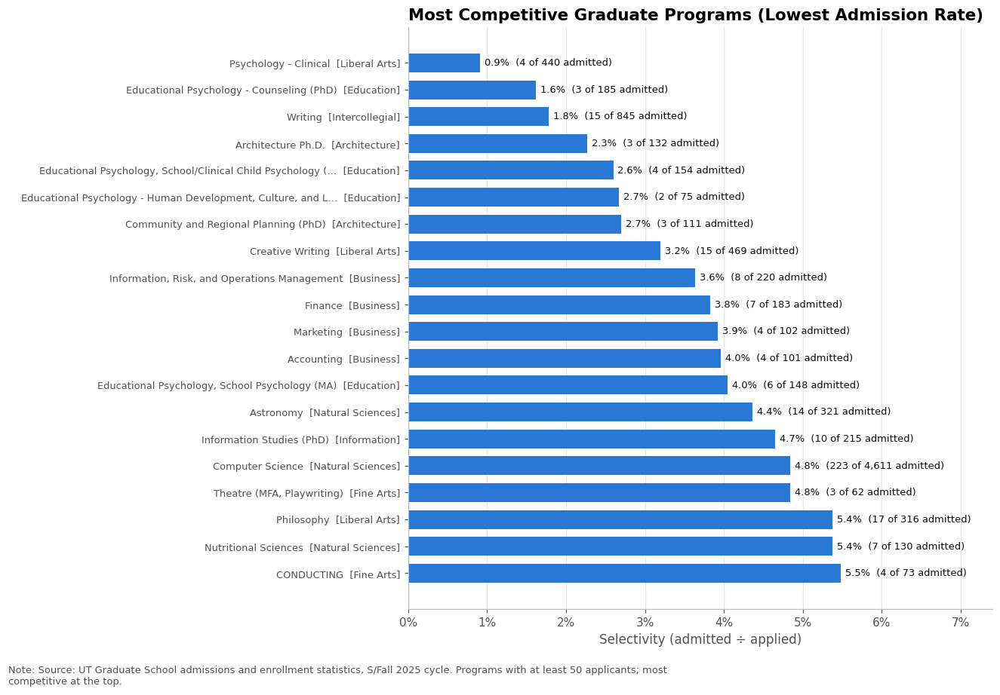

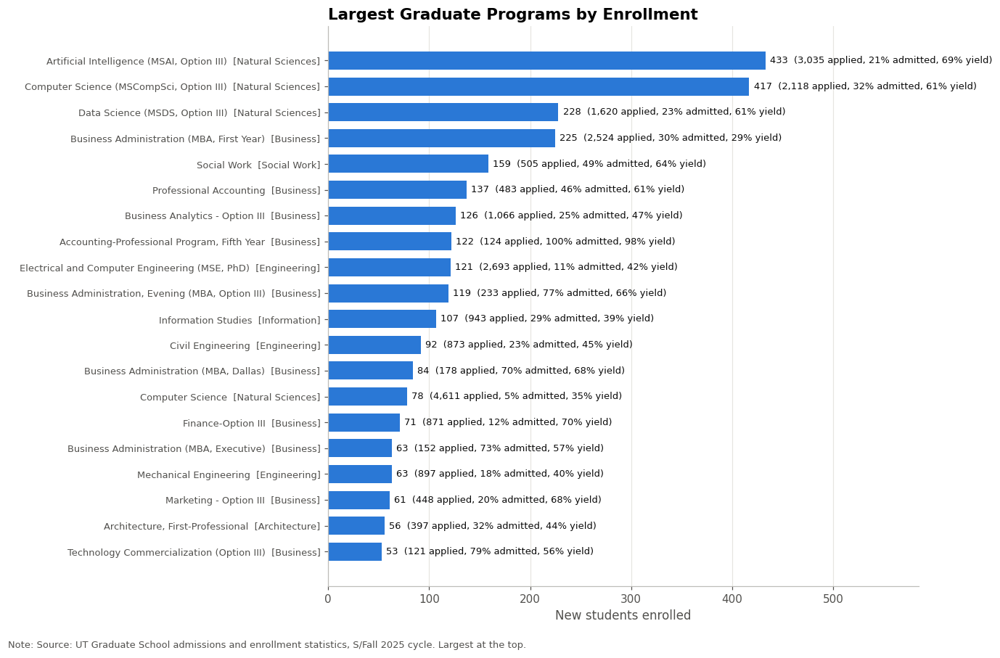

In [18]:
g = grad.copy()
g['label'] = g.Program.str.replace(r'\s*\([A-Z0-9]+\)$', '', regex=True).str.replace(r'\s+', ' ', regex=True)
g['label'] = g.label.where(g.label.str.len() <= 60, g.label.str[:58] + '…') + '  [' + g.School + ']'
fmt_g = {'Applied': '{:,}', 'Admitted': '{:,}', 'Enrolled': '{:,}', 'Selectivity': '{:.2f}%', 'Yield': '{:.2f}%'}
cols_g = ['School', 'Program', 'Applied', 'Admitted', 'Enrolled', 'Selectivity', 'Yield']
comp = g[g.Applied >= 50].sort_values(['Selectivity', 'Applied'], ascending=[True, False]).head(20)
big = g.nlargest(20, 'Enrolled')
print(f'{len(g)} programs; {(g.Applied >= 50).sum()} with ≥ 50 applicants. Totals: {g.Applied.sum():,} applied, '
      f'{g.Admitted.sum():,} admitted, {g.Enrolled.sum():,} enrolled.')
for title, t in [('Top 20 most competitive graduate programs (lowest selectivity, ≥ 50 applicants)', comp),
                 ('Top 20 graduate programs by number enrolled', big)]:
    t = t[cols_g].reset_index(drop=True); t.index += 1
    display(Markdown(f'**{title}**')); display(t.style.format(fmt_g))

def grad_bars(d, col, label_fn, title, xlabel, fname, note, pct=False):
    d = d.iloc[::-1]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(d.label, d[col], color=BLUE, height=0.7)
    for i, (_, r) in enumerate(d.iterrows()):
        ax.text(r[col] + d[col].max() * 0.01, i, label_fn(r), va='center', fontsize=8.5, color=INK)
    ax.set(xlabel=xlabel, title=title, xlim=(0, d[col].max() * 1.35)); ax.grid(axis='y', visible=False)
    ax.tick_params(axis='y', labelsize=8.5)
    if pct:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    add_note(fig, 'Source: UT Graduate School admissions and enrollment statistics, S/Fall 2025 cycle. ' + note, width=140)
    save(fig, fname)

grad_bars(comp, 'Selectivity', lambda r: f'{r.Selectivity:.1f}%  ({r.Admitted:,} of {r.Applied:,} admitted)',
          'Most Competitive Graduate Programs (Lowest Admission Rate)', 'Selectivity (admitted ÷ applied)', '1_6a_grad_competitive',
          'Programs with at least 50 applicants; most competitive at the top.', pct=True)
grad_bars(big, 'Enrolled', lambda r: f'{r.Enrolled:,}  ({r.Applied:,} applied, {r.Selectivity:.0f}% admitted, {r.Yield:.0f}% yield)',
          'Largest Graduate Programs by Enrollment', 'New students enrolled', '1_6b_grad_largest', 'Largest at the top.')

**Selectivity vs yield.** Each dot is a program; dot area shows its number of applicants, but every program is weighted equally in the correlation and fit. Four specifications (linear or log on each axis) are compared on the same programs, and the chart uses the one with the best fit (highest r²). Programs where nobody was admitted (yield undefined) or nobody enrolled (log yield undefined) are excluded.

,r,r²,slope,p-value
linear–linear,0.219709,0.048272,0.212127,0.0019
log selectivity,0.034771,0.001209,2.017919,0.63
log yield,0.176474,0.031143,0.001425,0.013
log–log,0.011866,0.000141,0.005759,0.87


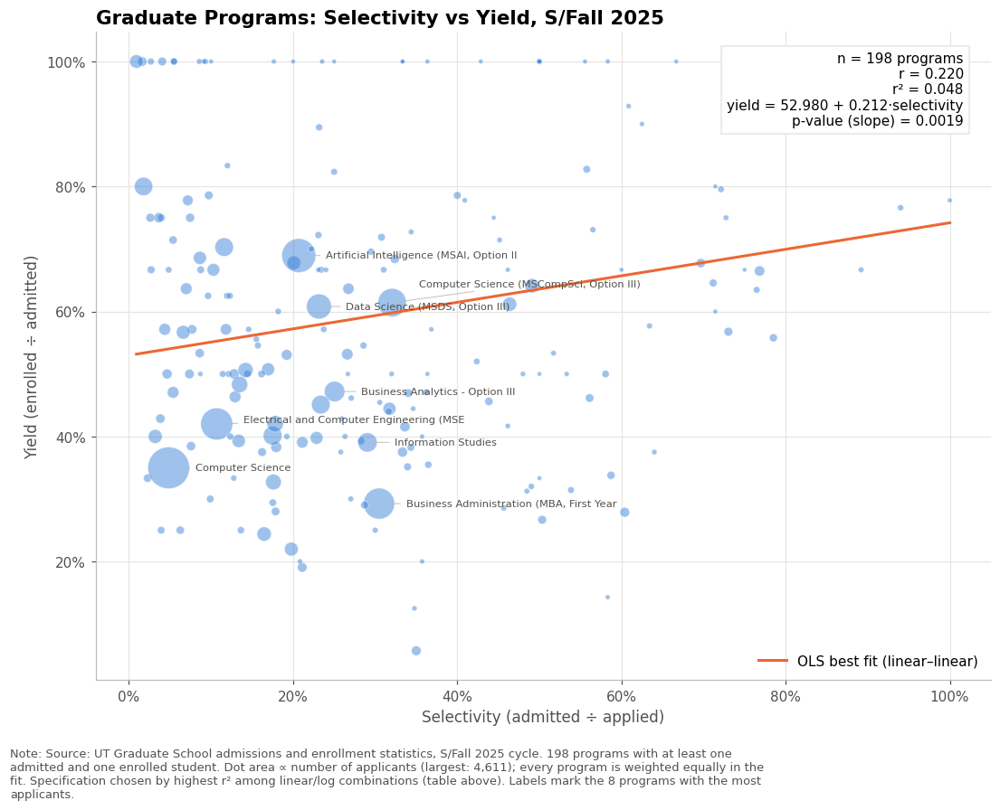

In [19]:
sv = g[(g.Admitted > 0) & (g.Enrolled > 0)].copy()
specs = {'linear–linear': (False, False), 'log selectivity': (True, False), 'log yield': (False, True), 'log–log': (True, True)}
fits = {}
for name, (lx, ly) in specs.items():
    X = np.log10(sv.Selectivity) if lx else sv.Selectivity
    Y = np.log10(sv.Yield) if ly else sv.Yield
    fits[name] = sm.OLS(Y, sm.add_constant(X)).fit()
display(pd.DataFrame({n: {'r': np.sign(f.params.iloc[1]) * np.sqrt(f.rsquared), 'r²': f.rsquared, 'slope': f.params.iloc[1],
                          'p-value': fmt_p(f.pvalues.iloc[1])} for n, f in fits.items()}).T.round(3))
best = max(fits, key=lambda n: fits[n].rsquared); lx, ly = specs[best]; fit = fits[best]
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.scatter(sv.Selectivity, sv.Yield, s=10 + 900 * sv.Applied / sv.Applied.max(), color=BLUE, alpha=0.45, edgecolor='white', linewidth=0.6)
xs = np.linspace(sv.Selectivity.min(), sv.Selectivity.max(), 200)
yhat = fit.params.iloc[0] + fit.params.iloc[1] * (np.log10(xs) if lx else xs)
ax.plot(xs, 10 ** yhat if ly else yhat, color=ORANGE, lw=2, label=f'OLS best fit ({best})')
if lx: ax.set_xscale('log')
if ly: ax.set_yscale('log')
top = sv.nlargest(8, 'Applied')
label_points(ax, top.Selectivity.values, top.Yield.values, top.label.str.split('  [', regex=False).str[0].str[:40].values)
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:g}%'))
xl, yl = ('log₁₀(selectivity)' if lx else 'selectivity'), ('log₁₀(yield)' if ly else 'yield')
ax.text(0.97, 0.97, f"n = {len(sv)} programs\nr = {np.sign(fit.params.iloc[1]) * np.sqrt(fit.rsquared):.3f}\nr² = {fit.rsquared:.3f}\n"
        f"{yl} = {fit.params.iloc[0]:.3f} + {fit.params.iloc[1]:.3f}·{xl}\np-value (slope) = {fmt_p(fit.pvalues.iloc[1])}",
        transform=ax.transAxes, ha='right', va='top', fontsize=10, bbox=dict(fc='white', ec='#e6e5e1'))
ax.set(xlabel='Selectivity (admitted ÷ applied)' + (', log scale' if lx else ''), ylabel='Yield (enrolled ÷ admitted)' + (', log scale' if ly else ''),
       title='Graduate Programs: Selectivity vs Yield, S/Fall 2025')
ax.legend(loc='lower right')
add_note(fig, f'Source: UT Graduate School admissions and enrollment statistics, S/Fall 2025 cycle. {len(sv)} programs with at least one '
              f'admitted and one enrolled student. Dot area ∝ number of applicants (largest: {sv.Applied.max():,}); every program is weighted '
              f'equally in the fit. Specification chosen by highest r² among linear/log combinations (table above). Labels mark the 8 programs '
              'with the most applicants.', width=125)
save(fig, '1_6c_grad_selectivity_vs_yield')

**Applicant GPA and GRE vs selectivity.** The dashboard's *Average GPA* and *Average GRE* tabs report averages over the **applicants** to each program who reported a score. The GRE average here is the mean of the verbal and quantitative averages (each on the 130–170 scale). Programs need at least 5 reported scores to be plotted, since averages of 1–4 applicants are mostly noise; many programs no longer require the GRE, so fewer programs have GRE data. As above, dot area shows applicants, every program is weighted equally, and the x-axis (selectivity) is logged if that fits better.

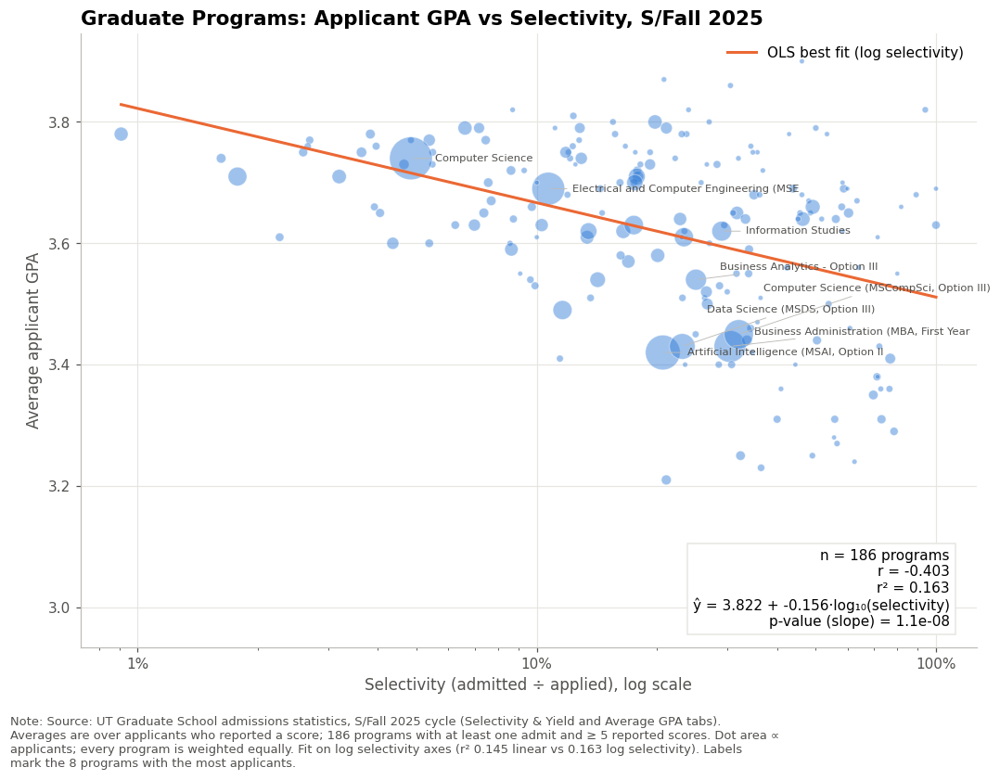

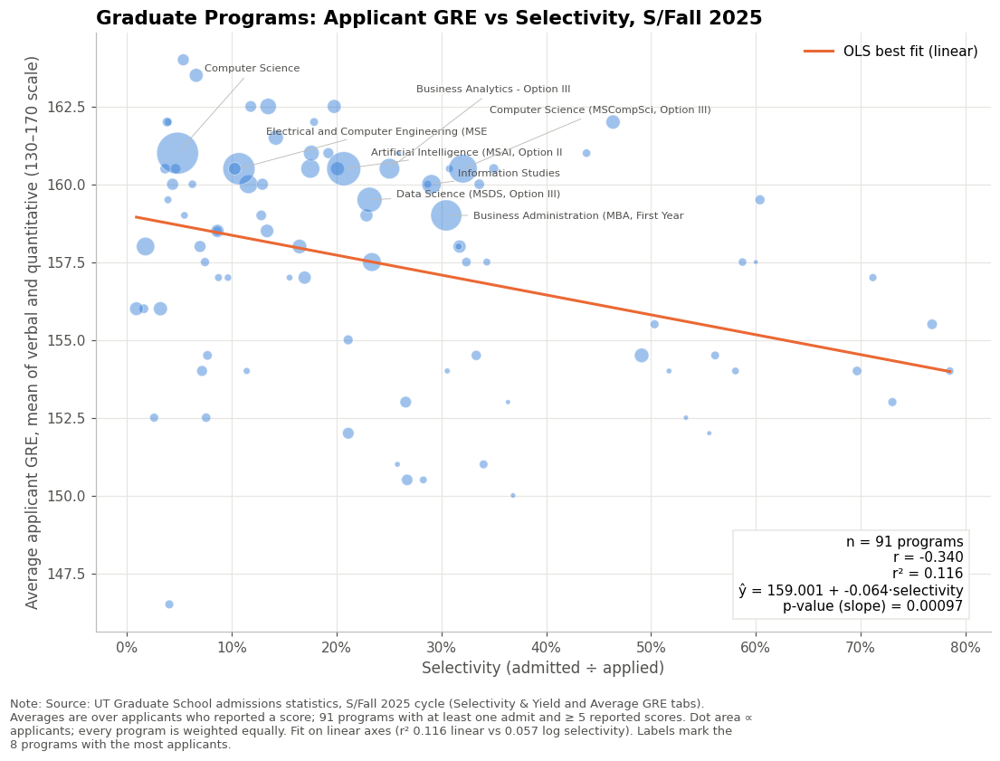

In [20]:
MIN_REPORTED = 5
g['Avg GRE (V+Q)/2'] = (g['Avg GRE Verbal'] + g['Avg GRE Quant']) / 2

def grad_score_scatter(col, n_col, ylabel, title, fname, fmt):
    d = g[(g.Admitted > 0) & g[col].notna() & (g[n_col] >= MIN_REPORTED)]
    fits = {name: sm.OLS(d[col], sm.add_constant(np.log10(d.Selectivity) if lx else d.Selectivity)).fit()
            for name, lx in [('linear', False), ('log selectivity', True)]}
    best = max(fits, key=lambda n: fits[n].rsquared); lx = best == 'log selectivity'; fit = fits[best]
    r = np.sign(fit.params.iloc[1]) * np.sqrt(fit.rsquared)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(d.Selectivity, d[col], s=10 + 900 * d.Applied / g.Applied.max(), color=BLUE, alpha=0.45, edgecolor='white', linewidth=0.6)
    xs = np.linspace(d.Selectivity.min(), d.Selectivity.max(), 200)
    ax.plot(xs, fit.params.iloc[0] + fit.params.iloc[1] * (np.log10(xs) if lx else xs), color=ORANGE, lw=2, label=f'OLS best fit ({best})')
    if lx: ax.set_xscale('log')
    top = d.nlargest(8, 'Applied')
    label_points(ax, top.Selectivity.values, top[col].values, top.label.str.split('  [', regex=False).str[0].str[:40].values)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:g}%'))
    xl = 'log₁₀(selectivity)' if lx else 'selectivity'
    ax.text(0.97, 0.03, f"n = {len(d)} programs\nr = {r:.3f}\nr² = {fit.rsquared:.3f}\n"
            f"ŷ = {fit.params.iloc[0]:.3f} + {fit.params.iloc[1]:.3f}·{xl}\np-value (slope) = {fmt_p(fit.pvalues.iloc[1])}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10, bbox=dict(fc='white', ec='#e6e5e1'))
    ax.set(xlabel='Selectivity (admitted ÷ applied)' + (', log scale' if lx else ''), ylabel=ylabel, title=title)
    ax.legend(loc='upper right')
    add_note(fig, f'Source: UT Graduate School admissions statistics, S/Fall 2025 cycle (Selectivity & Yield and {fmt} tabs). Averages are over '
                  f'applicants who reported a score; {len(d)} programs with at least one admit and ≥ {MIN_REPORTED} reported scores. Dot area ∝ '
                  f'applicants; every program is weighted equally. Fit on {best} axes (r² {fits["linear"].rsquared:.3f} linear vs '
                  f'{fits["log selectivity"].rsquared:.3f} log selectivity). Labels mark the 8 programs with the most applicants.', width=125)
    save(fig, fname)

grad_score_scatter('Avg GPA', 'GPA n', 'Average applicant GPA', 'Graduate Programs: Applicant GPA vs Selectivity, S/Fall 2025',
                   '1_6d_grad_gpa_vs_selectivity', 'Average GPA')
grad_score_scatter('Avg GRE (V+Q)/2', 'GRE n', 'Average applicant GRE, mean of verbal and quantitative (130–170 scale)',
                   'Graduate Programs: Applicant GRE vs Selectivity, S/Fall 2025', '1_6e_grad_gre_vs_selectivity', 'Average GRE')

### 1.7 Largest course prefixes by enrollment, 2025–26

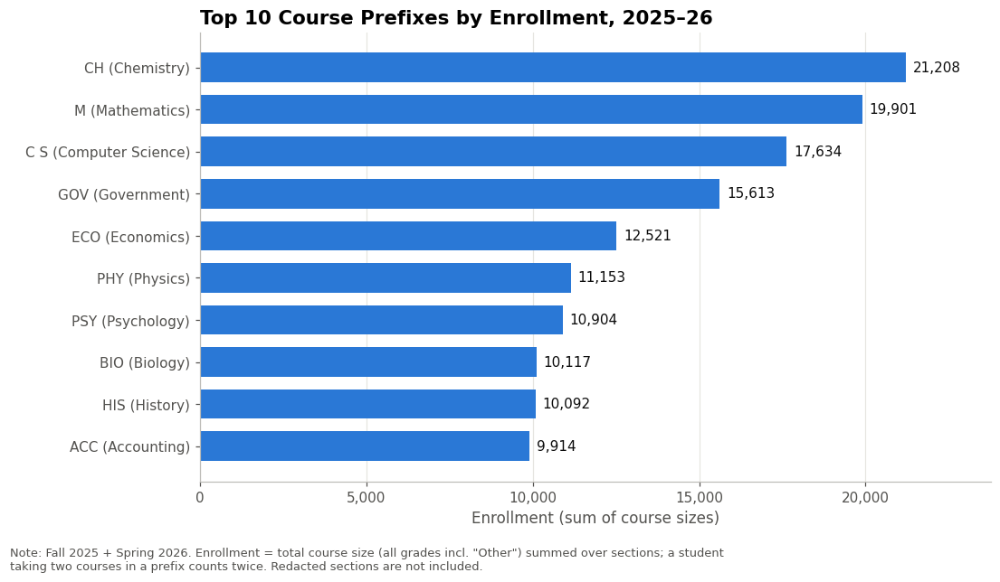

In [21]:
q7 = by_prefix.enrollment.nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh([prefix_label(p) for p in q7.index], q7, color=BLUE, height=0.7)
for i, val in enumerate(q7):
    ax.text(val + q7.max() * 0.01, i, f'{val:,}', va='center', fontsize=10, color=INK)
ax.set(xlabel='Enrollment (sum of course sizes)', title='Top 10 Course Prefixes by Enrollment, 2025–26', xlim=(0, q7.max() * 1.12))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')); ax.grid(axis='y', visible=False)
add_note(fig, 'Fall 2025 + Spring 2026. Enrollment = total course size (all grades incl. "Other") summed over sections; '
              'a student taking two courses in a prefix counts twice. Redacted sections are not included.', width=120)
save(fig, '1_7_top10_prefix_enrollment')

### 1.8 Change in course-prefix enrollment, 2011–12 → 2025–26, adjusted for student-body growth

The dashboard has no Fall 2010 / Spring 2011 data, so the base period is **Fall 2011 + Spring 2012**. End-period enrollment is divided by UT's fall headcount growth:

- Fall 2011 and Fall 2025 headcounts from UT's *Trends in Student Data* dashboard (§0.6 checks them against the UT catalog and the Fall 2025 geography files).

Only prefixes with enrollment ≥ 200 in **both** periods are included.

Student-body growth factor: 1.0761 (+7.6%); 94 prefixes eligible


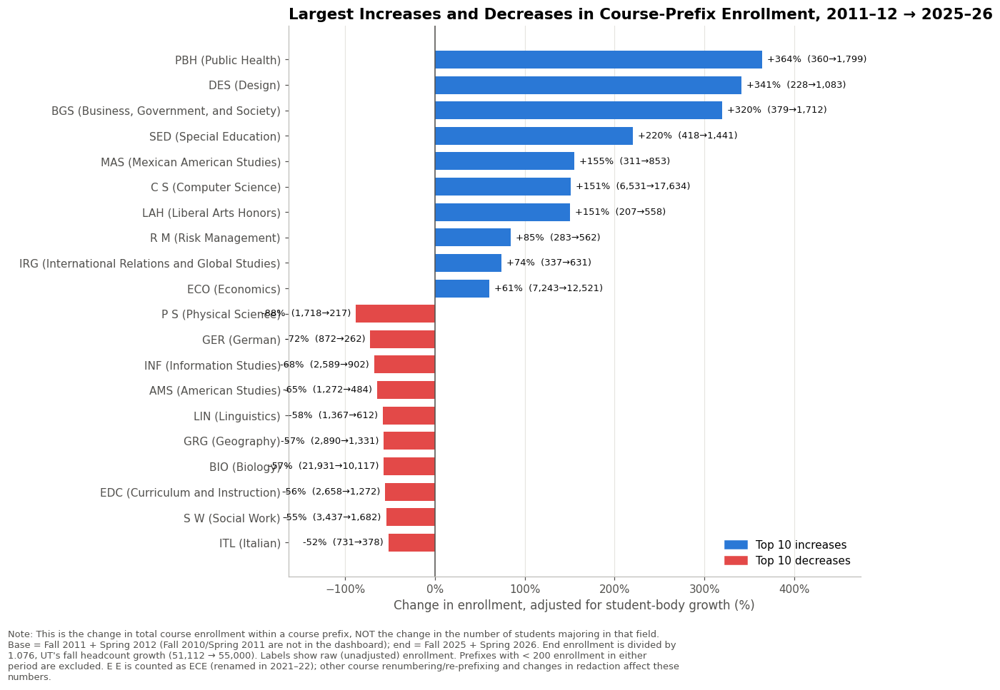

In [22]:
FALL_HEADCOUNT = {2011: students_total[2011], 2025: students_total[2025]}
growth = FALL_HEADCOUNT[2025] / FALL_HEADCOUNT[2011]
rename = lambda d: d['Course Prefix'].replace({'E E': 'ECE'})     # Electrical Engineering became ECE in 2021–22
base = semesters('Fall 2011', 'Spring 2012').pipe(lambda d: d.groupby(rename(d))['size'].sum())
end = ay.groupby(rename(ay))['size'].sum()
q8 = pd.DataFrame({'base': base, 'end': end}).dropna()
q8 = q8[(q8.base >= 200) & (q8.end >= 200)]
q8['end_adj'] = q8.end / growth
q8['pct'] = (q8.end_adj / q8.base - 1) * 100
print(f'Student-body growth factor: {growth:.4f} (+{(growth - 1) * 100:.1f}%); {len(q8)} prefixes eligible')
top_up, top_down = q8.nlargest(10, 'pct'), q8.nsmallest(10, 'pct')
q8_plot = pd.concat([top_down.sort_values('pct', ascending=False), top_up.sort_values('pct')])

fig, ax = plt.subplots(figsize=(11, 8))
colors = [BLUE if v > 0 else RED for v in q8_plot.pct]
ax.barh([prefix_label(p) for p in q8_plot.index], q8_plot.pct, color=colors, height=0.7)
span = q8_plot.pct.abs().max()
for i, (val, r) in enumerate(zip(q8_plot.pct, q8_plot.itertuples())):
    ax.text(val + (span * 0.015 if val > 0 else -span * 0.015), i, f'{val:+.0f}%  ({r.base:,.0f}→{r.end:,.0f})',
            va='center', ha='left' if val > 0 else 'right', fontsize=8.5, color=INK)
ax.axvline(0, color=INK2, lw=1)
ax.set(xlim=(q8_plot.pct.min() - 75, q8_plot.pct.max() + span * 0.3),
       xlabel='Change in enrollment, adjusted for student-body growth (%)',
       title='Largest Increases and Decreases in Course-Prefix Enrollment, 2011–12 → 2025–26')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); ax.grid(axis='y', visible=False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=RED)],
          labels=['Top 10 increases', 'Top 10 decreases'], loc='lower right')
add_note(fig, f'This is the change in total course enrollment within a course prefix, NOT the change in the number of students majoring '
              f'in that field. Base = Fall 2011 + Spring 2012 (Fall 2010/Spring 2011 are not in the dashboard); end = Fall 2025 + Spring 2026. '
              f'End enrollment is divided by {growth:.3f}, UT\'s fall headcount growth ({FALL_HEADCOUNT[2011]:,.0f} → {FALL_HEADCOUNT[2025]:,.0f}). Labels show raw (unadjusted) '
              f'enrollment. Prefixes with < 200 enrollment in either period are excluded. E E is counted as ECE (renamed in 2021–22); other course renumbering/re-prefixing and '
              f'changes in redaction affect these numbers.', width=140)
save(fig, '1_8_prefix_enrollment_change')

### 1.9 Course prefixes with the most and fewest distinct course numbers, 2025–26

Ties among the fewest are broken by larger enrollment first.

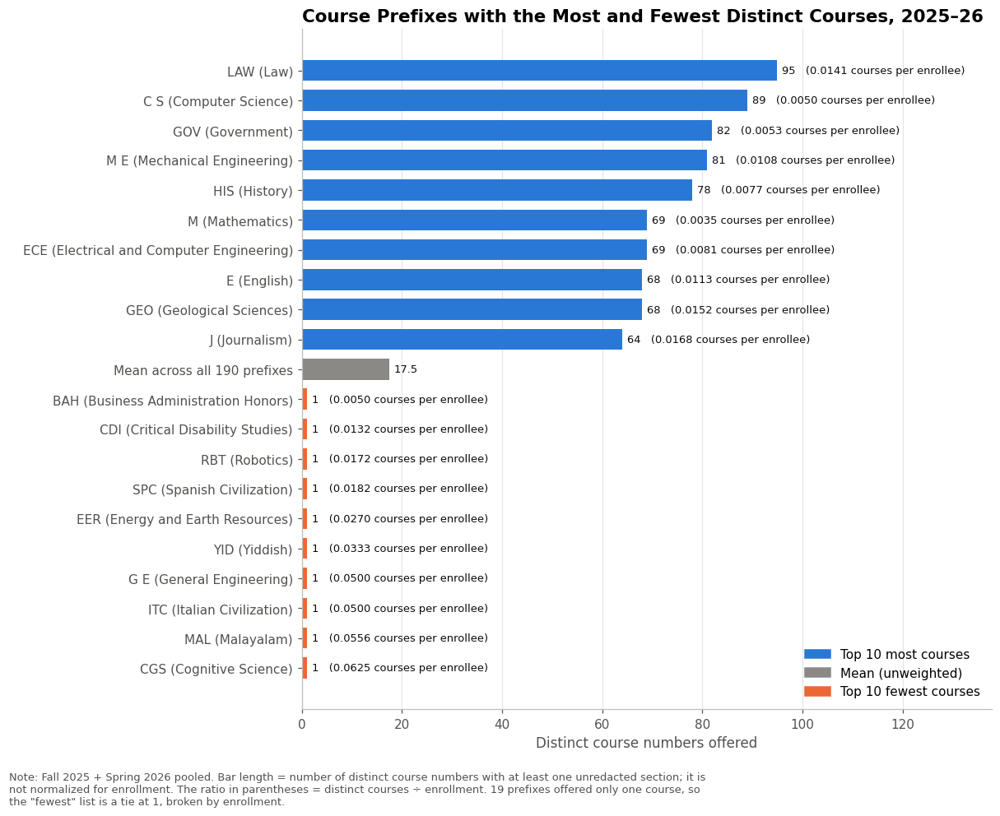

In [23]:
q9 = ay.groupby('Course Prefix').agg(courses=('Course Number', 'nunique'), enrollment=('size', 'sum'))
q9['per_enrollee'] = q9.courses / q9.enrollment
mean_courses = q9.courses.mean()
most = q9.sort_values(['courses', 'enrollment'], ascending=[False, False]).head(10)
least = q9.sort_values(['courses', 'enrollment'], ascending=[True, False]).head(10)
rows = ([(prefix_label(p), r.courses, r.per_enrollee, ORANGE) for p, r in least[::-1].iterrows()]
        + [(f'Mean across all {len(q9)} prefixes', mean_courses, None, GRAY)]
        + [(prefix_label(p), r.courses, r.per_enrollee, BLUE) for p, r in most[::-1].iterrows()])
rows = rows[::-1]  # most at the top
fig, ax = plt.subplots(figsize=(11, 8.5))
for i, (lab, val, ratio, c) in enumerate(rows):
    ax.barh(i, val, color=c, height=0.7)
    txt = f'{val:.1f}' if ratio is None else f'{val:.0f}   ({ratio:.4f} courses per enrollee)'
    ax.text(val + q9.courses.max() * 0.01, i, txt, va='center', fontsize=8.5, color=INK)
ax.set_yticks(range(len(rows)), [r[0] for r in rows]); ax.invert_yaxis()
ax.set(xlim=(0, q9.courses.max() * 1.45), xlabel='Distinct course numbers offered',
       title='Course Prefixes with the Most and Fewest Distinct Courses, 2025–26'); ax.grid(axis='y', visible=False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in (BLUE, GRAY, ORANGE)],
          labels=['Top 10 most courses', 'Mean (unweighted)', 'Top 10 fewest courses'], loc='lower right')
add_note(fig, 'Fall 2025 + Spring 2026 pooled. Bar length = number of distinct course numbers with at least one unredacted section; '
              'it is not normalized for enrollment. The ratio in parentheses = distinct courses ÷ enrollment. '
              f'{(q9.courses == 1).sum()} prefixes offered only one course, so the "fewest" list is a tie at 1, broken by enrollment.', width=130)
save(fig, '1_9_prefix_distinct_courses')

### 1.10 Course size

Course size = all grades in a section, including "Other". The histogram uses Fall 2025 + Spring 2026 sections on a log scale (sizes range from single digits to several hundred); the top-10 table also includes Summer 2026.

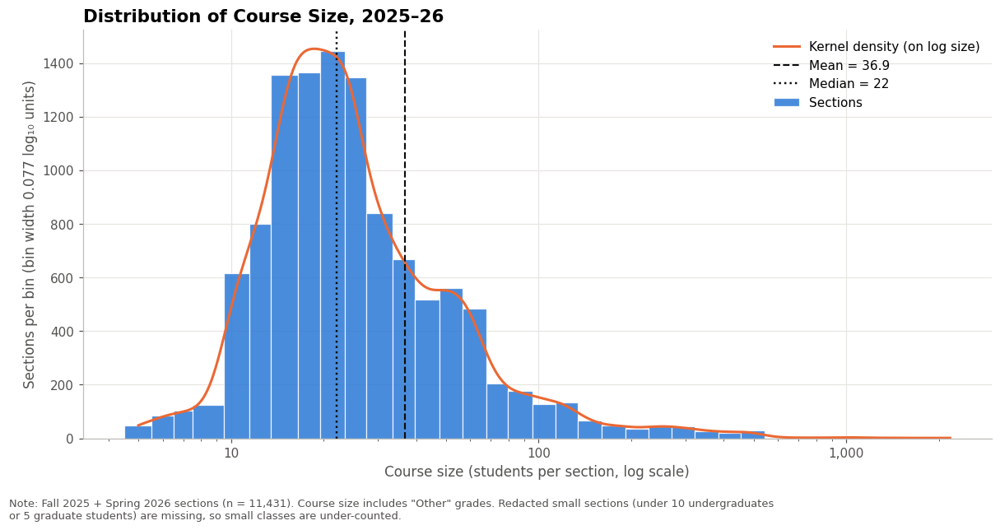

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
course size,11431.0,36.9,68.0,5.0,12.0,16.0,22.0,36.0,61.0,292.7,2176.0


In [24]:
sz = ay['size']
fig, ax = plt.subplots(figsize=(11, 5.5))
# integer-aligned log bins; bar height = count rescaled to a common bin width so uneven integer coverage doesn't create gaps
edges = np.unique(np.round(np.logspace(np.log10(sz.min()), np.log10(sz.max() + 1), 36))) - 0.5
counts, _ = np.histogram(sz, bins=edges)
width = np.diff(np.log10(edges)); ref = width.mean()
ax.bar(edges[:-1], counts * ref / width, width=np.diff(edges), align='edge', color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.8, label='Sections')
kde = stats.gaussian_kde(np.log10(sz))
xs = np.linspace(np.log10(sz.min()), np.log10(sz.max()), 400)
ax.plot(10 ** xs, kde(xs) * len(sz) * ref, color=ORANGE, lw=2, label='Kernel density (on log size)')
ax.axvline(sz.mean(), ls='--', color=INK, lw=1.4, label=f'Mean = {sz.mean():.1f}')
ax.axvline(sz.median(), ls=':', color=INK, lw=1.6, label=f'Median = {sz.median():.0f}')
ax.set_xscale('log'); ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set(xlabel='Course size (students per section, log scale)', ylabel=f'Sections per bin (bin width {ref:.3f} log₁₀ units)', title='Distribution of Course Size, 2025–26')
ax.legend(loc='upper right')
add_note(fig, f'Fall 2025 + Spring 2026 sections (n = {len(sz):,}). Course size includes "Other" grades. Redacted small sections '
              f'(under 10 undergraduates or 5 graduate students) are missing, so small classes are under-counted.', width=140)
save(fig, '1_10a_course_size_hist')
display(sz.describe(percentiles=[.1, .25, .5, .75, .9, .99]).to_frame('course size').T.round(1))

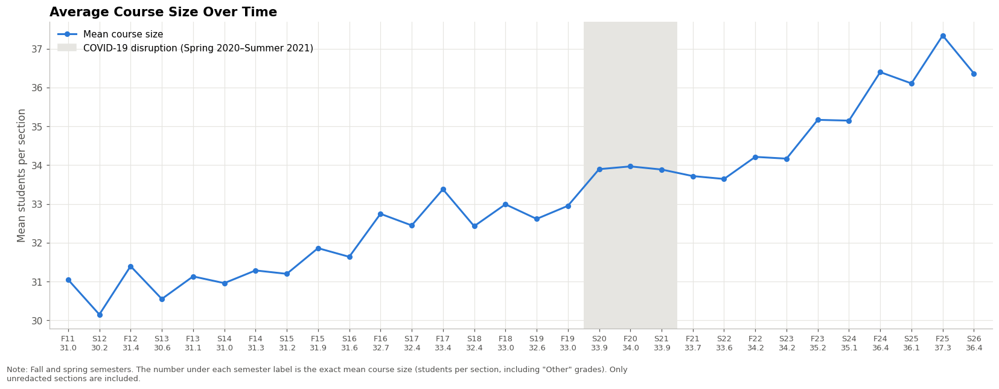

In [25]:
mean_size = sec[sec.Semester.isin(FS_SEMS)].groupby('Semester')['size'].mean().reindex(FS_SEMS)
fig, ax = plt.subplots(figsize=(15, 5.5))
xs = np.arange(len(FS_SEMS))
shade_covid(ax, FS_SEMS)
ax.plot(xs, mean_size, color=BLUE, marker='o', ms=5, label='Mean course size')
ax.set_xticks(xs, [f'{short(s)}\n{v:.1f}' for s, v in zip(FS_SEMS, mean_size)], fontsize=8.5)
ax.set(ylabel='Mean students per section', title='Average Course Size Over Time', xlim=(-0.6, len(xs) - 0.4))
ax.legend(handles=[ax.lines[0], COVID_PATCH], loc='upper left')
add_note(fig, 'Fall and spring semesters. The number under each semester label is the exact mean course size (students per section, including '
              '"Other" grades). Only unredacted sections are included.', width=160)
save(fig, '1_10b_course_size_trend')

In [26]:
yr = semesters('Fall 2025', 'Spring 2026', 'Summer 2026')
top_size = yr.nlargest(10, 'size')[['Semester', 'course_id', 'Course Title', 'Section Number', 'size', 'n_letter', 'avg']]
top_size = top_size.rename(columns={'course_id': 'Course', 'size': 'Course size', 'n_letter': 'Letter grades', 'avg': 'Grade average'}).reset_index(drop=True)
top_size.index += 1
display(Markdown('**Top 10 largest course sections, 2025–26 (Fall 2025, Spring 2026, Summer 2026)**'))
display(top_size.style.format({'Grade average': '{:.2f}'}))

top_nonweb = yr[yr.d_web == 0].nlargest(10, 'size')[['Semester', 'course_id', 'Course Title', 'Section Number', 'size', 'n_letter', 'avg']]
top_nonweb = top_nonweb.rename(columns={'course_id': 'Course', 'size': 'Course size', 'n_letter': 'Letter grades', 'avg': 'Grade average'}).reset_index(drop=True)
top_nonweb.index += 1
display(Markdown('**Top 10 largest non-web-based course sections, 2025–26 (Fall 2025, Spring 2026, Summer 2026)**'))
display(top_nonweb.style.format({'Grade average': '{:.2f}'}))

**Top 10 largest course sections, 2025–26 (Fall 2025, Spring 2026, Summer 2026)**

,Semester,Course,Course Title,Section Number,Course size,Letter grades,Grade average
1,Spring 2026,NTR 306,FUNDAMENTALS OF NUTRITION-WB,54600,2176,2160,3.82
2,Fall 2025,NTR 306,FUNDAMENTALS OF NUTRITION-WB,56325,2141,2121,3.81
3,Fall 2025,GOV 312L,ISS & POLICIES IN AMER GOV-WB,39410,1854,1736,3.32
4,Spring 2026,GOV 310L,AMERICAN AND TEXAS GOV-WB,38575,1491,1451,3.44
5,Fall 2025,GOV 310L,AMERICAN AND TEXAS GOV-WB,39375,1481,1445,3.51
6,Spring 2026,GOV 312L,ISS & POLICIES IN AMER GOV-WB,38620,1471,1260,3.15
7,Fall 2025,GOV 310L,AMERICAN AND TEXAS GOV-WB,39370,1175,1149,3.45
8,Fall 2025,PSY 301,INTRODUCTION TO PSYCHOLOGY-WB,43660,1167,1077,3.61
9,Fall 2025,ACC 310F,FOUNDATIONS OF ACCOUNTING-WB,2800,1043,910,3.24
10,Spring 2026,GOV 310L,AMERICAN AND TEXAS GOV-WB,38580,1033,984,3.46


**Top 10 largest non-web-based course sections, 2025–26 (Fall 2025, Spring 2026, Summer 2026)**

,Semester,Course,Course Title,Section Number,Course size,Letter grades,Grade average
1,Fall 2025,ECO 304K,INTRODUCTION TO MICROECONOMICS,36015,523,504,3.56
2,Spring 2026,CH 320N,ORGANIC CHEMISTRY II,52210,515,481,3.35
3,Fall 2025,ECO 304K,INTRODUCTION TO MICROECONOMICS,36005,510,493,3.35
4,Fall 2025,HIS 317L,HISTORY OF COLLEGE FOOTBALL,40115,509,492,3.83
5,Spring 2026,HIS 317L,HISTORY OF COLLEGE FOOTBALL,39370,494,474,3.68
6,Spring 2026,CH 302,PRINCIPLES OF CHEMISTRY II,50690,488,456,3.43
7,Spring 2026,CH 320N,ORGANIC CHEMISTRY II,52225,487,441,3.13
8,Fall 2025,HIS 315K,"THE UNITED STATES, 1492-1865",40090,479,473,3.87
9,Spring 2026,HIS 315L,THE UNITED STATES SINCE 1865,39350,477,463,3.81
10,Fall 2025,ECO 329,ECONOMIC STATISTICS,36115,476,427,2.66


## 2. Grades in 2025–26

### 2.1 Mean course grade by course prefix, 2025–26

Mean of the section grade averages across Fall 2025 and Spring 2026 (summer excluded), for prefixes whose summed course size is at least the threshold.

Minimum enrollment used: 500 → 100 prefixes (148 prefixes would qualify at 100)


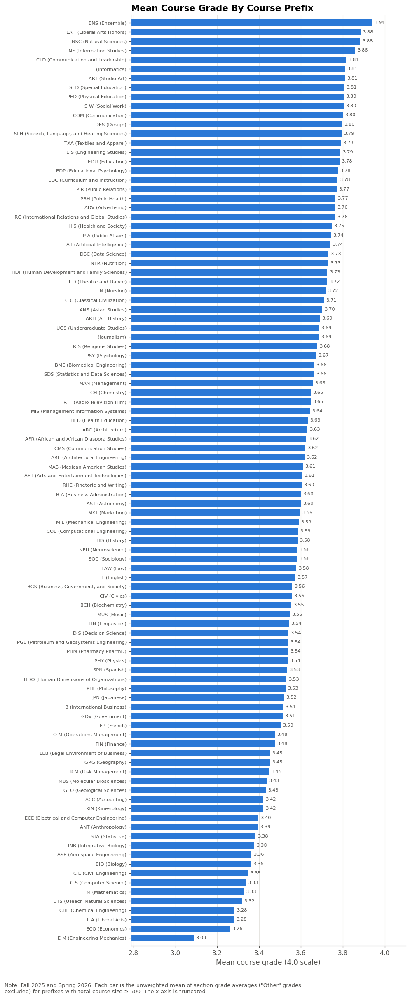

In [27]:
for threshold in range(100, 1001, 50):          # raise the cutoff until the chart is a readable height
    q1 = by_prefix[by_prefix.enrollment >= threshold].sort_values('mean_grade')
    if len(q1) <= 100:
        break
print(f'Minimum enrollment used: {threshold} → {len(q1)} prefixes '
      f'({(by_prefix.enrollment >= 100).sum()} prefixes would qualify at 100)')

fig, ax = plt.subplots(figsize=(9, 0.2 * len(q1) + 1.5))
ax.barh([prefix_label(p) for p in q1.index], q1.mean_grade, color=BLUE, height=0.7)
for i, v in enumerate(q1.mean_grade):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=7.5, color=INK2)
ax.set(xlim=(q1.mean_grade.min() - 0.3, 4.1), xlabel='Mean course grade (4.0 scale)', ylabel='', title='Mean Course Grade By Course Prefix')
ax.tick_params(axis='y', labelsize=7.5); ax.margins(y=0.005); ax.grid(axis='y', visible=False)
add_note(fig, f'Fall 2025 and Spring 2026. Each bar is the unweighted mean of section grade averages ("Other" grades excluded) '
              f'for prefixes with total course size ≥ {threshold}. The x-axis is truncated.', width=110)
save(fig, '2_1_mean_grade_by_prefix')

#### Size-weighted mean course grade by course prefix, grouped by field

Same prefixes as above but using the original 100-student threshold, since splitting by field keeps each chart short. Each section's grade average is weighted by its course size (all grades, including "Other"). Field groups are judgment calls; Computer Science is grouped with engineering and Mathematics with natural science. The full mapping is printed below the charts.

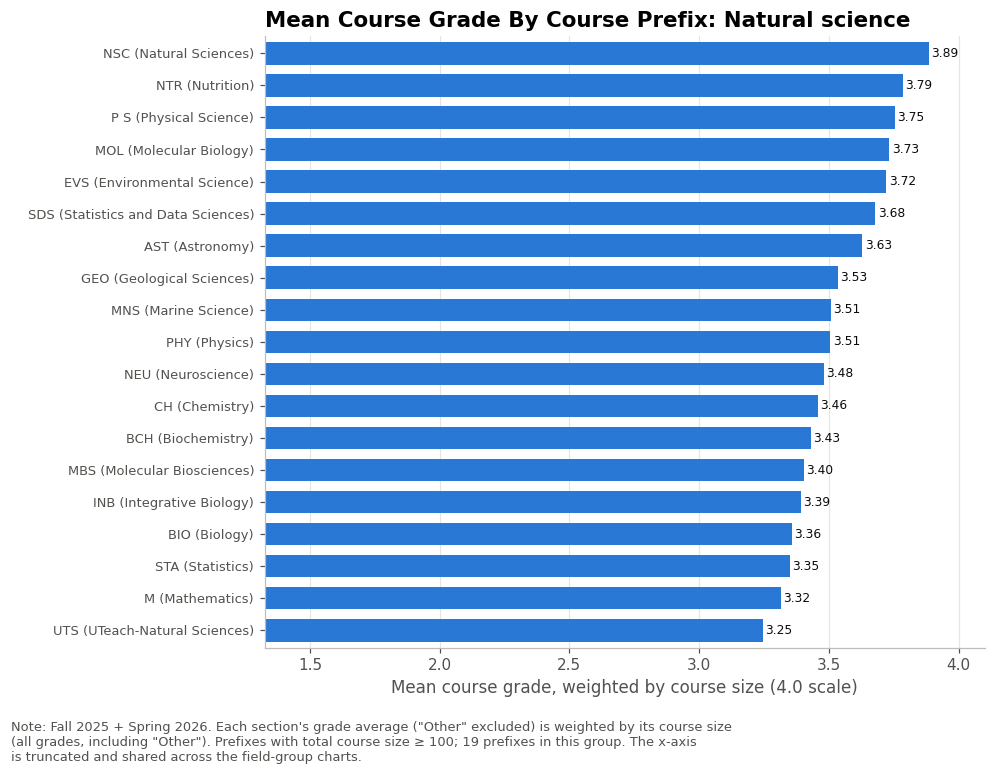

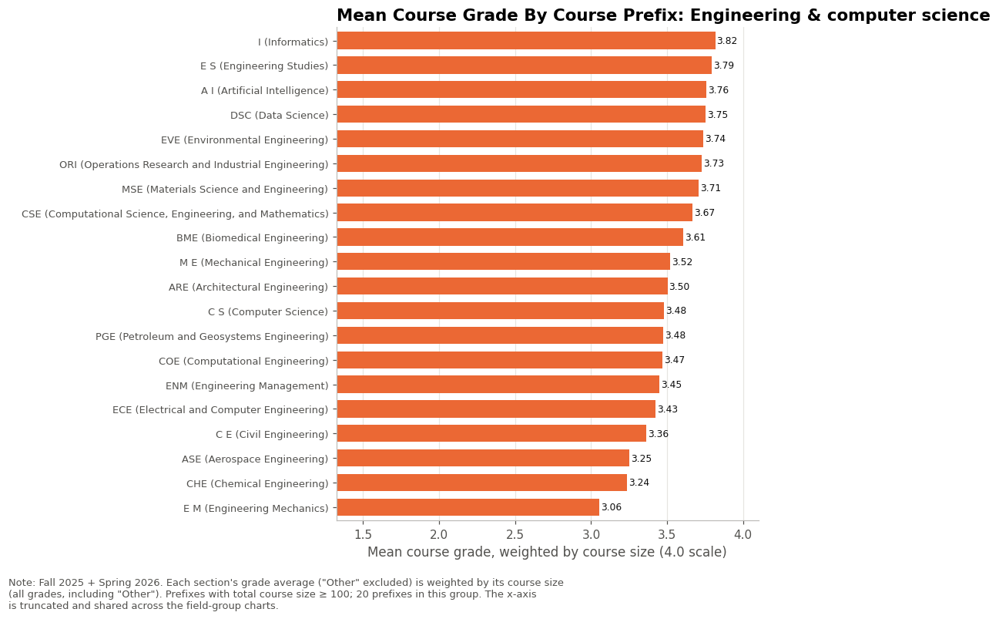

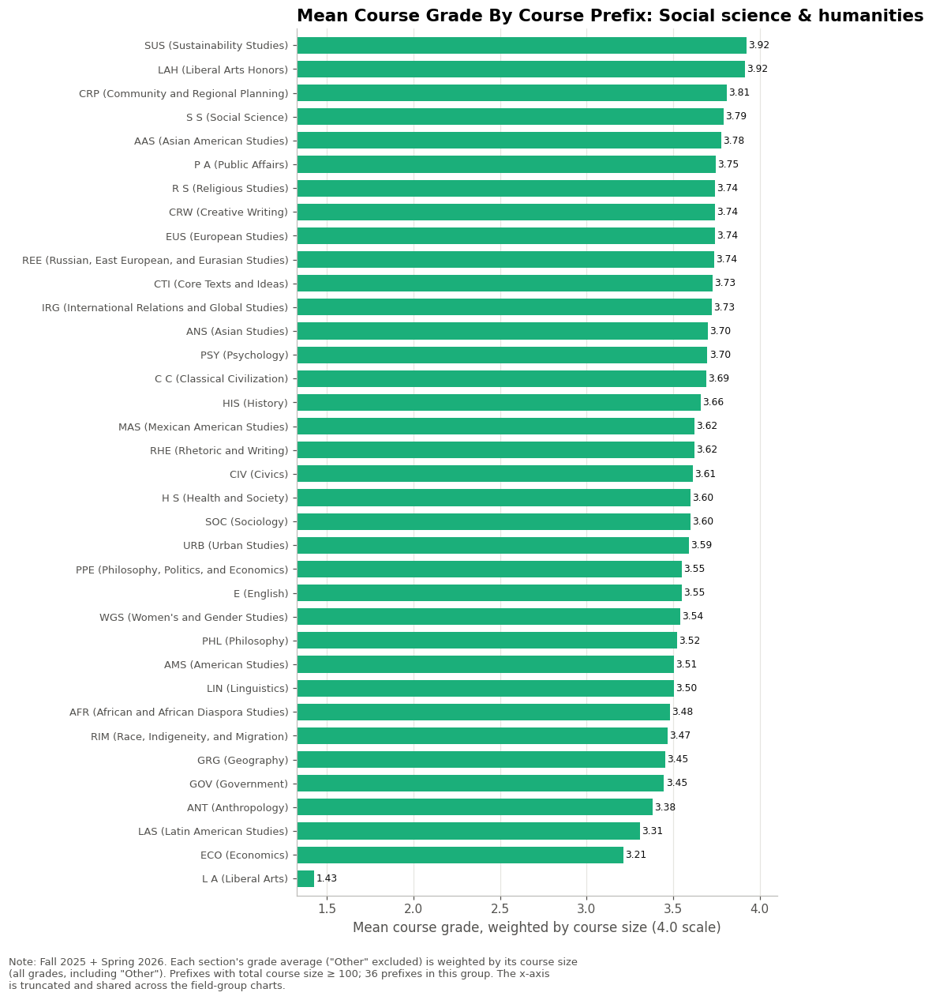

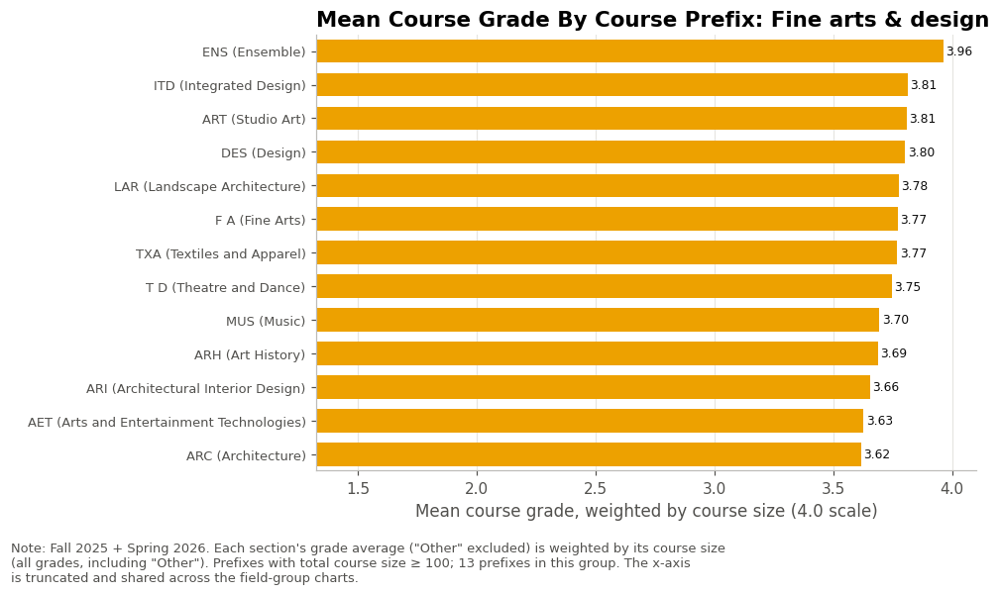

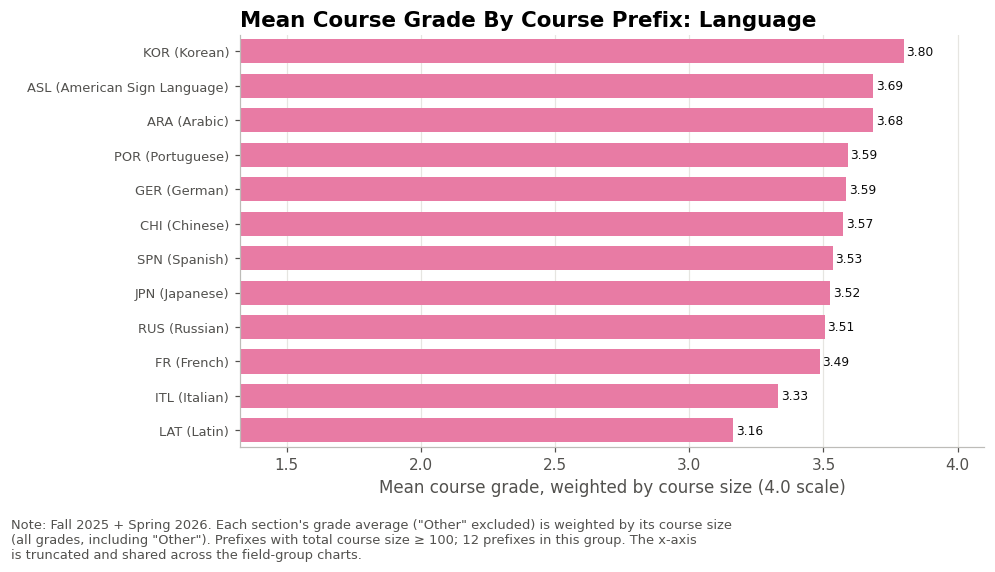

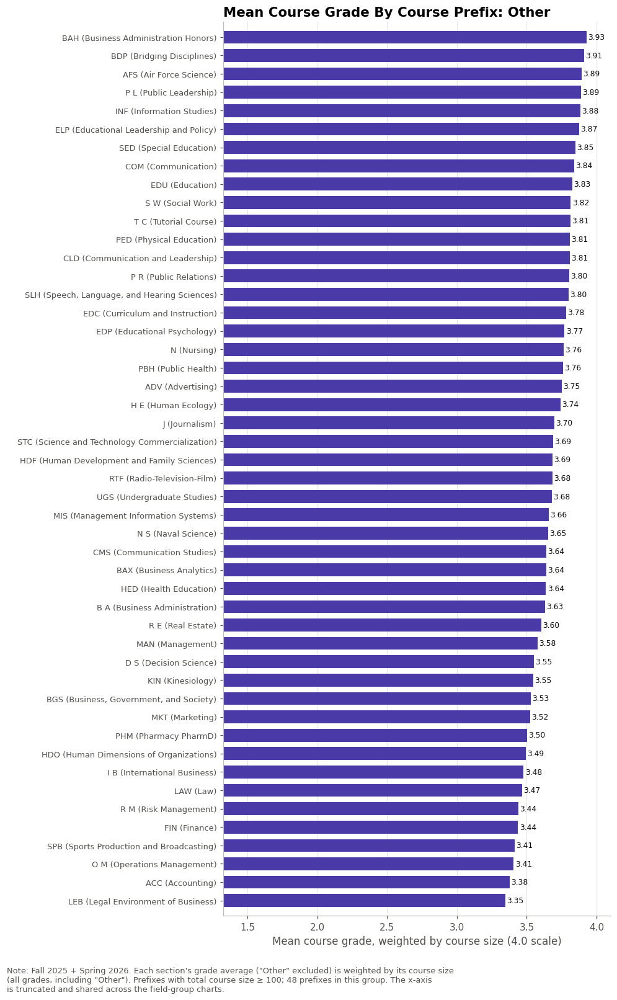

In [28]:
FIELD_GROUPS = {
    'Natural science': ['AST', 'BCH', 'BIO', 'CH', 'EVS', 'GEO', 'INB', 'M', 'MBS', 'MNS', 'MOL', 'NEU', 'NSC', 'NTR', 'P S', 'PHY',
                        'SDS', 'STA', 'UTS'],
    'Engineering & computer science': ['A I', 'ARE', 'ASE', 'BME', 'C E', 'C S', 'CHE', 'COE', 'CSE', 'DSC', 'E M', 'E S', 'ECE', 'ENM',
                                       'EVE', 'I', 'M E', 'MSE', 'ORI', 'PGE'],
    'Social science & humanities': ['AAS', 'AFR', 'AMS', 'ANS', 'ANT', 'C C', 'CIV', 'CRP', 'CRW', 'CTI', 'E', 'ECO', 'EUS', 'GOV', 'GRG',
                                    'H S', 'HIS', 'IRG', 'L A', 'LAH', 'LAS', 'LIN', 'MAS', 'P A', 'PHL', 'PPE', 'PSY', 'R S', 'REE', 'RHE',
                                    'RIM', 'S S', 'SOC', 'SUS', 'URB', 'WGS'],
    'Fine arts & design': ['AET', 'ARC', 'ARH', 'ARI', 'ART', 'DES', 'ENS', 'F A', 'ITD', 'LAR', 'MUS', 'T D', 'TXA'],
    'Language': ['SPN', 'FR', 'GER', 'ITL', 'POR', 'ROM', 'CHI', 'JPN', 'KOR', 'ARA', 'HEB', 'PRS', 'TUR', 'URD', 'HIN', 'BEN', 'MAL', 'TAM',
                 'TEL', 'SAN', 'RUS', 'UKR', 'POL', 'CZ', 'BCM', 'GK', 'LAT', 'SWA', 'YOR', 'YID', 'DAN', 'DCH', 'NOR', 'SWE', 'ASL', 'LAL'],
}
FIELD_COLORS = dict(zip(list(FIELD_GROUPS) + ['Other'], [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, VIOLET]))
field_of = {p: grp for grp, ps in FIELD_GROUPS.items() for p in ps}
wq = ay[ay.avg.notna()].assign(pts=lambda d: d.avg * d['size'])
by_p = wq.groupby('Course Prefix').agg(pts=('pts', 'sum'), size=('size', 'sum'))
by_p = by_p[by_p['size'] >= 100]
by_p['wgrade'] = by_p.pts / by_p['size']
by_p['field'] = [field_of.get(p, 'Other') for p in by_p.index]
xmin = by_p.wgrade.min() - 0.1
for grp in FIELD_COLORS:
    d = by_p[by_p.field == grp].sort_values('wgrade')
    fig, ax = plt.subplots(figsize=(9, 0.26 * len(d) + 1.6))
    ax.barh([prefix_label(p) for p in d.index], d.wgrade, color=FIELD_COLORS[grp], height=0.7)
    for i, v in enumerate(d.wgrade):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8, color=INK)
    ax.set(xlim=(xmin, 4.1), xlabel='Mean course grade, weighted by course size (4.0 scale)',
           title=f'Mean Course Grade By Course Prefix: {grp}')
    ax.tick_params(axis='y', labelsize=8.5); ax.margins(y=0.01); ax.grid(axis='y', visible=False)
    add_note(fig, f'Fall 2025 + Spring 2026. Each section\'s grade average ("Other" excluded) is weighted by its course size (all grades, '
                  f'including "Other"). Prefixes with total course size ≥ 100; {len(d)} prefixes in this group. The x-axis is truncated and '
                  'shared across the field-group charts.', width=110)
    save(fig, '2_1b_weighted_grade_' + re.sub(r'[^a-z]+', '_', grp.lower()).strip('_'))

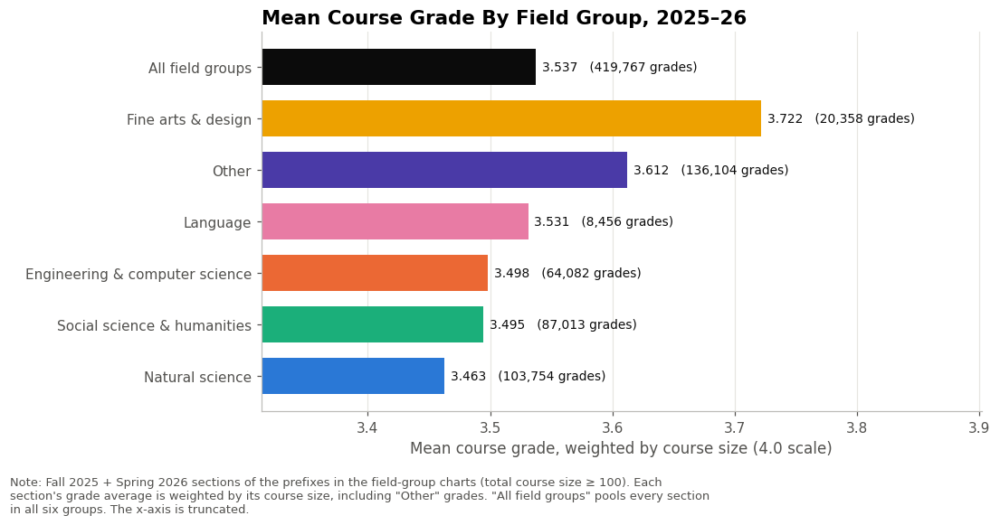

**Field-group mapping used above (prefixes with total course size ≥ 100 in 2025–26)**

,prefixes
field,
Natural science,"AST, BCH, BIO, CH, EVS, GEO, INB, M, MBS, MNS,..."
Engineering & computer science,"A I, ARE, ASE, BME, C E, C S, CHE, COE, CSE, D..."
Social science & humanities,"AAS, AFR, AMS, ANS, ANT, C C, CIV, CRP, CRW, C..."
Fine arts & design,"AET, ARC, ARH, ARI, ART, DES, ENS, F A, ITD, L..."
Language,"ARA, ASL, CHI, FR, GER, ITL, JPN, KOR, LAT, PO..."
Other,"ACC, ADV, AFS, B A, BAH, BAX, BDP, BGS, CLD, C..."


In [29]:
grp_tot = by_p.groupby('field')[['pts', 'size']].sum()
grp_tot.loc['All field groups'] = grp_tot.sum()
grp_tot['wgrade'] = grp_tot.pts / grp_tot['size']
order = grp_tot.drop('All field groups').sort_values('wgrade').index.tolist() + ['All field groups']
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(order, grp_tot.loc[order, 'wgrade'], color=[FIELD_COLORS.get(g, INK) for g in order], height=0.7)
for i, g in enumerate(order):
    r = grp_tot.loc[g]
    ax.text(r.wgrade + 0.005, i, f"{r.wgrade:.3f}   ({r['size']:,.0f} grades)", va='center', fontsize=9, color=INK)
ax.set(xlim=(grp_tot.wgrade.min() - 0.15, grp_tot.wgrade.max() + 0.18), xlabel='Mean course grade, weighted by course size (4.0 scale)',
       title='Mean Course Grade By Field Group, 2025–26')
ax.grid(axis='y', visible=False)
add_note(fig, 'Fall 2025 + Spring 2026 sections of the prefixes in the field-group charts (total course size ≥ 100). Each section\'s grade '
              'average is weighted by its course size, including "Other" grades. "All field groups" pools every section in all six groups. '
              'The x-axis is truncated.', width=120)
save(fig, '2_1c_weighted_grade_by_field_group')
mapping = by_p.reset_index().groupby('field')['Course Prefix'].agg(lambda s: ', '.join(sorted(s))).reindex(list(FIELD_COLORS))
display(Markdown('**Field-group mapping used above (prefixes with total course size ≥ 100 in 2025–26)**'))
display(mapping.to_frame('prefixes'))

### 2.2 Grade distribution, 2025–26

Share of all grades (Fall + Spring pooled). Mean and median are computed over letter grades only; the mean line is placed by linear interpolation between the letter positions. The same chart for the COVID year is in §4.1.

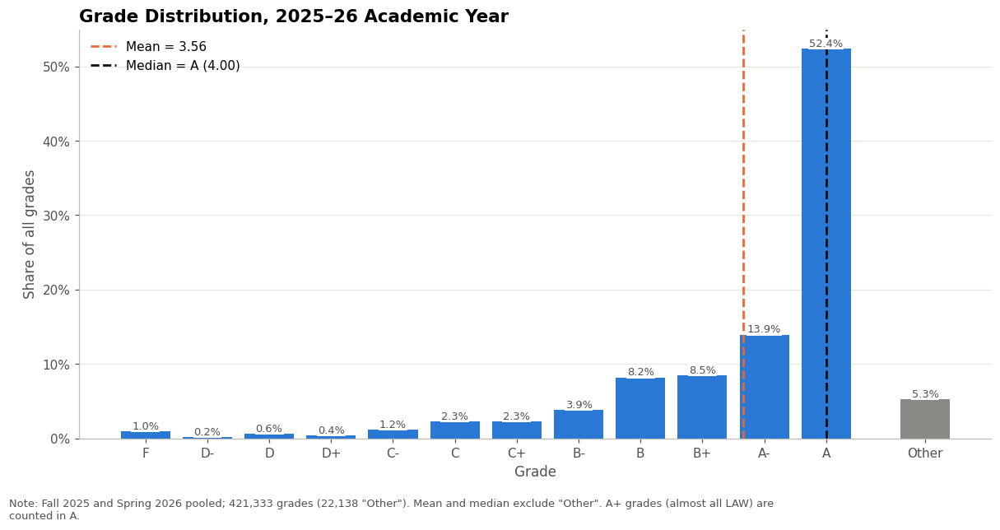

In [30]:
HIST_ORDER = ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A']

def grade_histogram(sems, title, fname, note):
    df = semesters(*sems)
    counts = df[GRADE_COLS].sum()
    counts['A'] += counts.pop('A+')                           # A+ scored as A (4.0 cap)
    pts = POINTS[HIST_ORDER]
    letter_counts = counts[HIST_ORDER]
    mean = np.average(pts, weights=letter_counts)
    cum = letter_counts.cumsum() / letter_counts.sum()
    median_letter = cum[cum >= 0.5].index[0]
    share = counts / counts.sum() * 100
    pos = list(range(len(HIST_ORDER))) + [len(HIST_ORDER) + 0.6]  # gap before "Other"
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.bar(pos[:-1], share[HIST_ORDER], color=BLUE, width=0.8)
    ax.bar(pos[-1], share['Other'], color=GRAY, width=0.8)
    for x, v in zip(pos, share[HIST_ORDER + ['Other']]):
        ax.text(x, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8.5, color=INK2, zorder=5, bbox=dict(fc='white', ec='none', pad=0.6))
    mean_x = np.interp(mean, pts.values, range(len(HIST_ORDER)))
    med_x = HIST_ORDER.index(median_letter)
    ax.axvline(mean_x, ls='--', color=ORANGE, lw=1.8, label=f'Mean = {mean:.2f}')
    ax.axvline(med_x, ls='--', color=INK, lw=1.8, label=f'Median = {median_letter} ({POINTS[median_letter]:.2f})')
    ax.set_xticks(pos, HIST_ORDER + ['Other'])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.set(ylabel='Share of all grades', xlabel='Grade', title=title); ax.grid(axis='x', visible=False)
    ax.legend(loc='upper left')
    add_note(fig, f'{" and ".join(sems)} pooled; {counts.sum():,} grades ({counts["Other"]:,} "Other"). Mean and median exclude "Other". ' + note, width=140)
    save(fig, fname)
    return pd.Series({'grades': counts.sum(), 'other_share': share['Other'], 'A_share': share['A'], 'mean': mean, 'median': median_letter})

h3 = grade_histogram(AY, 'Grade Distribution, 2025–26 Academic Year', '2_2_grade_hist_2025_26', 'A+ grades (almost all LAW) are counted in A.')

### 2.3 Distribution of section grade averages, 2025–26

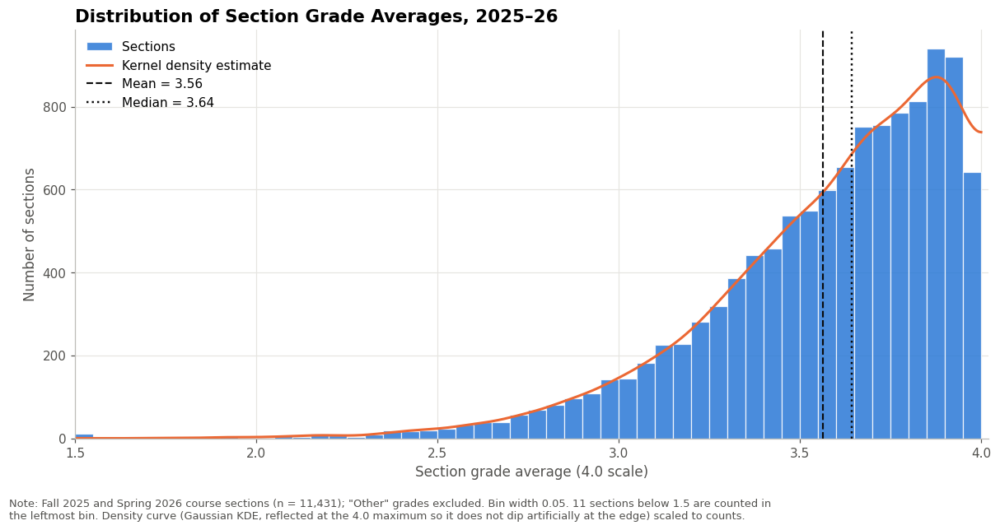

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,max
section grade average,11431.0,3.563,0.352,0.0,2.482,2.904,3.102,3.385,3.644,3.829,3.923,4.0


,% of sections
avg,
"(0.0, 2.5]",1.0
"(2.5, 3.0]",6.0
"(3.0, 3.25]",9.3
"(3.25, 3.5]",18.8
"(3.5, 3.75]",29.0
"(3.75, 3.9]",22.2
"(3.9, 4.0]",13.7


In [31]:
v = ay.avg.dropna()
lo6 = 1.5
kde = stats.gaussian_kde(v)
bins = np.arange(lo6, 4.0001, 0.05)
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hist(v.clip(lower=lo6), bins=bins, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.8, label='Sections')
xs = np.linspace(lo6, 4.0, 400)
ax.plot(xs, (kde(xs) + kde(8 - xs)) * len(v) * 0.05, color=ORANGE, lw=2, label='Kernel density estimate')  # reflected at the 4.0 ceiling
ax.axvline(v.mean(), ls='--', color=INK, lw=1.4, label=f'Mean = {v.mean():.2f}')
ax.axvline(v.median(), ls=':', color=INK, lw=1.6, label=f'Median = {v.median():.2f}')
ax.set(xlim=(lo6, 4.02), xlabel='Section grade average (4.0 scale)', ylabel='Number of sections',
       title='Distribution of Section Grade Averages, 2025–26')
ax.legend(loc='upper left')
add_note(fig, f'Fall 2025 and Spring 2026 course sections (n = {len(v):,}); "Other" grades excluded. Bin width 0.05. '
              f'{(v < lo6).sum()} sections below {lo6} are counted in the leftmost bin. Density curve (Gaussian KDE, reflected at the 4.0 '
              'maximum so it does not dip artificially at the edge) scaled to counts.', width=140)
save(fig, '2_3_section_grade_hist')
display(v.describe(percentiles=[.01, .05, .1, .25, .5, .75, .9]).to_frame('section grade average').T.round(3))
display(pd.cut(v, [0, 2.5, 3.0, 3.25, 3.5, 3.75, 3.9, 4.0]).value_counts(sort=False, normalize=True).mul(100).round(1).to_frame('% of sections'))

### 2.4 Descriptive statistics by course-type dummy, 2025–26

Unit = course (prefix + number), Fall 2025 + Spring 2026, all sections combined. A course gets a dummy = 1 if any of its sections' titles match.

The web-based dummy (`web`) is included.

In [32]:
dcols = [f'd_{k}' for k in DUMMIES]
c16 = pool(ay, ['Course Prefix', 'Course Number']).set_index(['Course Prefix', 'Course Number'])
c16 = c16.join(ay.groupby(['Course Prefix', 'Course Number'])[dcols].max())
c16 = c16[c16.avg.notna()]
rows16 = {}
for k in DUMMIES:
    yes, no = c16[c16[f'd_{k}'] == 1], c16[c16[f'd_{k}'] == 0]
    rows16[k] = {'courses (=1)': len(yes), '% of courses': 100 * len(yes) / len(c16), 'enrollment (=1)': yes['size'].sum(),
                 'mean grade (=1)': yes.avg.mean(), 'sd (=1)': yes.avg.std(), 'min (=1)': yes.avg.min(),
                 'median (=1)': yes.avg.median(), 'max (=1)': yes.avg.max(), 'mean grade (=0)': no.avg.mean(),
                 'difference': yes.avg.mean() - no.avg.mean(), 'Welch t p-value': stats.ttest_ind(yes.avg, no.avg, equal_var=False).pvalue}
q16 = pd.DataFrame(rows16).T
display(q16.style.format({'courses (=1)': '{:,.0f}', 'enrollment (=1)': '{:,.0f}', '% of courses': '{:.1f}',
                          'Welch t p-value': '{:.3g}'}, precision=3))
print(f'{len(c16):,} courses in total; overall mean course grade {c16.avg.mean():.3f}')

,courses (=1),% of courses,enrollment (=1),mean grade (=1),sd (=1),min (=1),median (=1),max (=1),mean grade (=0),difference,Welch t p-value
intro,298,9.0,"75,453",3.617,0.270,2.625,3.686,4.000,3.625,-0.008,0.625
intermediate,31,0.9,"5,144",3.611,0.225,3.059,3.556,3.970,3.625,-0.014,0.735
advanced,113,3.4,"15,716",3.661,0.283,2.335,3.715,4.000,3.623,0.037,0.172
principles,29,0.9,"15,563",3.595,0.304,2.900,3.707,4.000,3.625,-0.030,0.601
I,213,6.4,"39,758",3.615,0.262,2.740,3.667,3.986,3.625,-0.010,0.6
II,170,5.1,"32,164",3.628,0.231,2.900,3.657,3.973,3.624,0.003,0.857
III,31,0.9,"6,991",3.640,0.156,3.423,3.610,3.933,3.625,0.015,0.6
honors,64,1.9,"29,947",3.653,0.247,2.921,3.674,4.000,3.624,0.029,0.363
lab,78,2.3,"16,692",3.647,0.221,3.088,3.671,4.000,3.624,0.022,0.384
web,221,6.6,"106,628",3.632,0.420,0.000,3.726,4.000,3.624,0.008,0.781


3,326 courses in total; overall mean course grade 3.625


## 3. Grade trends by major

### 3.1 Mean course grade over time: core prefixes

Fall and spring semesters only. *Equal weight:* mean of section grade averages. *Weighted:* sections weighted by number of letter grades (equivalently, the pooled grade distribution). Each department gets its own panel on a shared scale.

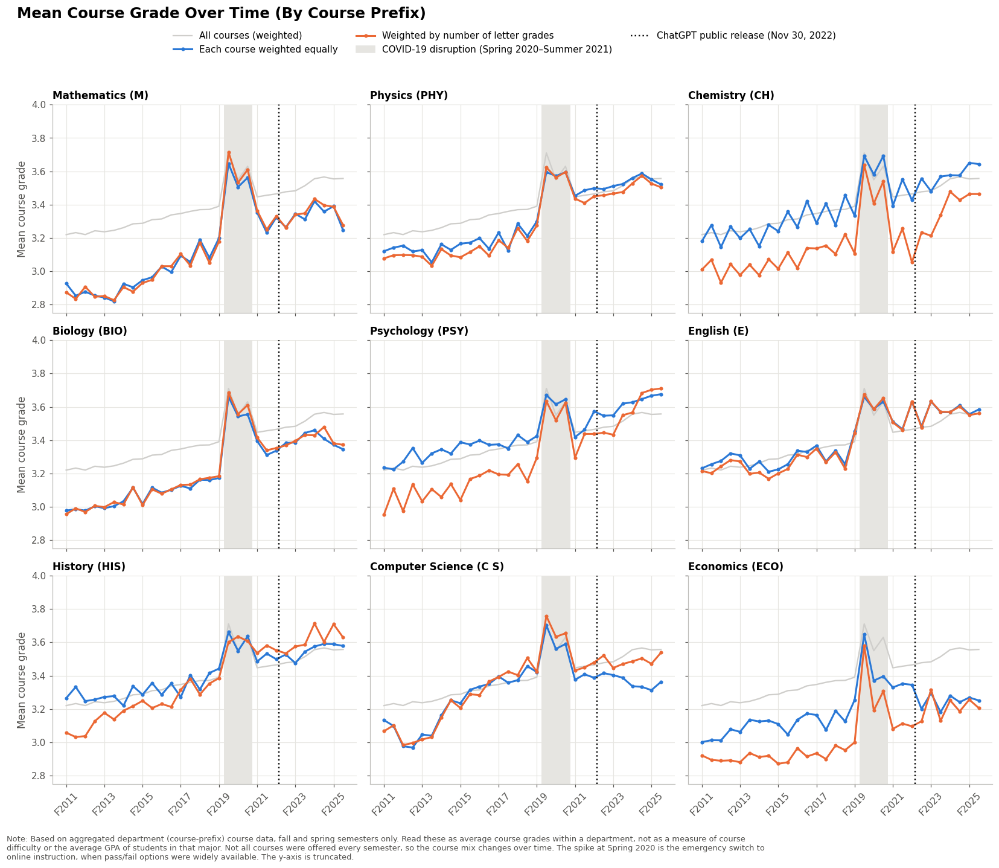

Lowest department-semester value: 2.82


In [33]:
DEPTS = {'M': 'Mathematics', 'PHY': 'Physics', 'CH': 'Chemistry', 'BIO': 'Biology', 'PSY': 'Psychology',
         'E': 'English', 'HIS': 'History', 'C S': 'Computer Science', 'ECO': 'Economics'}
ENG = {'ASE': 'Aerospace Engineering', 'BME': 'Biomedical Engineering', 'C E': 'Civil Engineering', 'CHE': 'Chemical Engineering',
       'ECE': 'Electrical and Computer Engineering', 'E M': 'Engineering Mechanics', 'M E': 'Mechanical Engineering'}
TREND_PREFIXES = {**DEPTS, **ENG}
fs = sec[sec.Term.isin(['Fall', 'Spring']) & sec.avg.notna()]

def trend(df):
    g = df.assign(pts=df.avg * df.n_letter).groupby('Semester')
    return pd.DataFrame({'equal': g.avg.mean(), 'weighted': g.pts.sum() / g.n_letter.sum()}).reindex(FS_SEMS)

overall = trend(fs)
PREFIX_ALIASES = {'ECE': ['ECE', 'E E']}          # Electrical Engineering (E E) was renamed ECE in 2021–22
trends = {p: trend(fs[fs['Course Prefix'].isin(PREFIX_ALIASES.get(p, [p]))]) for p in TREND_PREFIXES}

def trend_grid(depts, title, fname, ncols=3):
    nrows = -(-len(depts) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.6 * nrows + 1.8), sharex=True, sharey=True, squeeze=False)
    xs = np.arange(len(FS_SEMS))
    lo = min(trends[p].min().min() for p in depts)
    ticks = [i for i, s in enumerate(FS_SEMS) if s.startswith('Fall')][::2]
    for ax in axes.flat[len(depts):]:
        ax.set_visible(False)
    for i, (ax, (p, name)) in enumerate(zip(axes.flat, depts.items())):
        t = trends[p]
        shade_covid(ax, FS_SEMS)
        chatgpt_line(ax, chatgpt_sem(FS_SEMS))
        ax.plot(xs, overall.weighted, color='#cfcecb', lw=1.5, label='All courses (weighted)')
        ax.plot(xs, t.equal, color=BLUE, marker='o', ms=3, label='Each course weighted equally')
        ax.plot(xs, t.weighted, color=ORANGE, marker='o', ms=3, label='Weighted by number of letter grades')
        ax.set_title(f'{name} ({p})', fontsize=11)
        ax.set_xticks(ticks, [FS_SEMS[j].replace('Fall ', 'F') for j in ticks])
        ax.tick_params(axis='x', rotation=45)
        if i + ncols >= len(depts):                  # lowest visible panel in its column shows x labels
            ax.xaxis.set_tick_params(labelbottom=True)
    axes.flat[0].set_ylim(np.floor(lo * 10) / 10 - 0.05, 4.0)
    for ax in axes[:, 0]:
        ax.set_ylabel('Mean course grade')
    h, l = axes.flat[0].get_legend_handles_labels()
    fig.suptitle(title, x=0.01, ha='left', fontsize=16, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 1 - 1.0 / fig.get_figheight()))
    fig.legend(h + [COVID_PATCH, CHATGPT_HANDLE], l + [COVID_PATCH.get_label(), CHATGPT_LABEL], loc='upper center', ncol=3,
               bbox_to_anchor=(0.5, 1 - 0.5 / fig.get_figheight()), fontsize=10)
    add_note(fig, 'Based on aggregated department (course-prefix) course data, fall and spring semesters only. Read these as average '
                  'course grades within a department, not as a measure of course difficulty or the average GPA of students in that major. '
                  'Not all courses were offered every semester, so the course mix changes over time. The spike at Spring 2020 is the '
                  'emergency switch to online instruction, when pass/fail options were widely available. The y-axis is truncated.'
                  + (' ECE includes its predecessor prefix E E (Electrical Engineering), renamed in 2021–22.' if 'ECE' in depts else ''),
             width=190, layout=False)
    save(fig, fname)
    print(f'Lowest department-semester value: {lo:.2f}')

trend_grid(DEPTS, 'Mean Course Grade Over Time (By Course Prefix)', '3_1_grade_trend_core')

### 3.2 Mean course grade over time: engineering prefixes

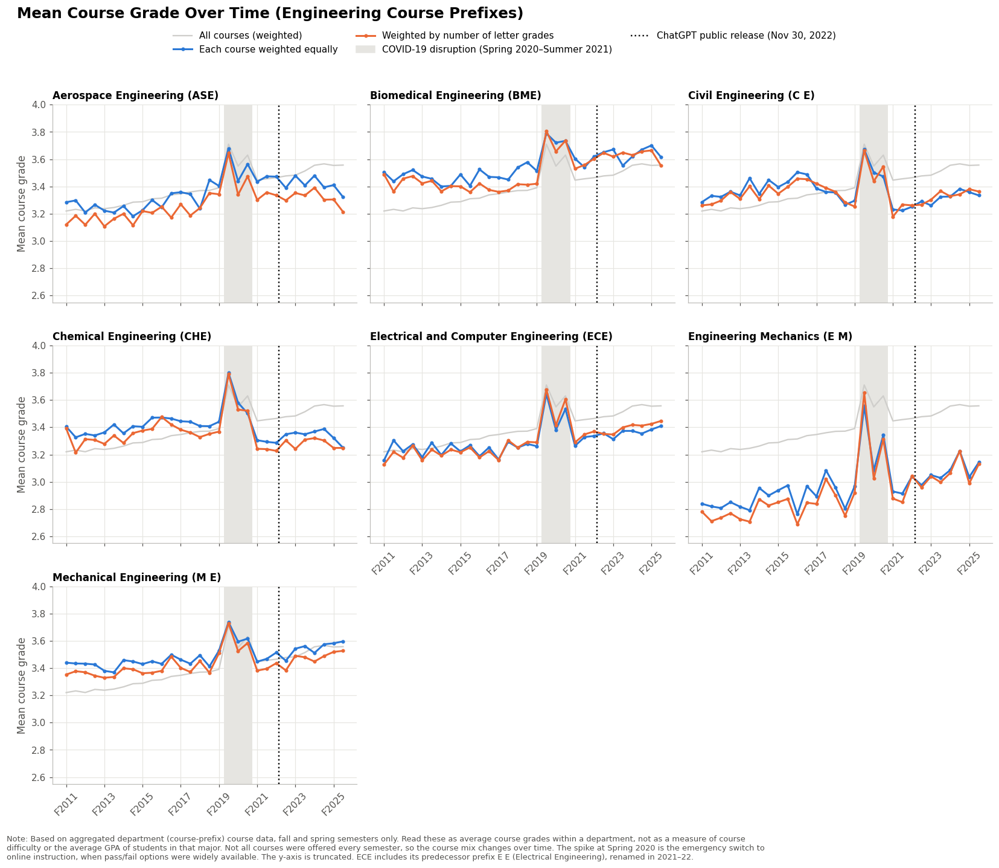

Lowest department-semester value: 2.69


In [34]:
trend_grid(ENG, 'Mean Course Grade Over Time (Engineering Course Prefixes)', '3_2_grade_trend_engineering')

### 3.3 Highest- and lowest-graded courses, 2025–26 (enrollment ≥ 50)

A course's grade is the arithmetic mean of its section grade averages across Fall 2025 and Spring 2026. Bars start at the median course grade.
Courses where letter grades are under half of all grades are also dropped: these are mostly pass/fail courses whose only letter grades are a few F's (average 0.00).

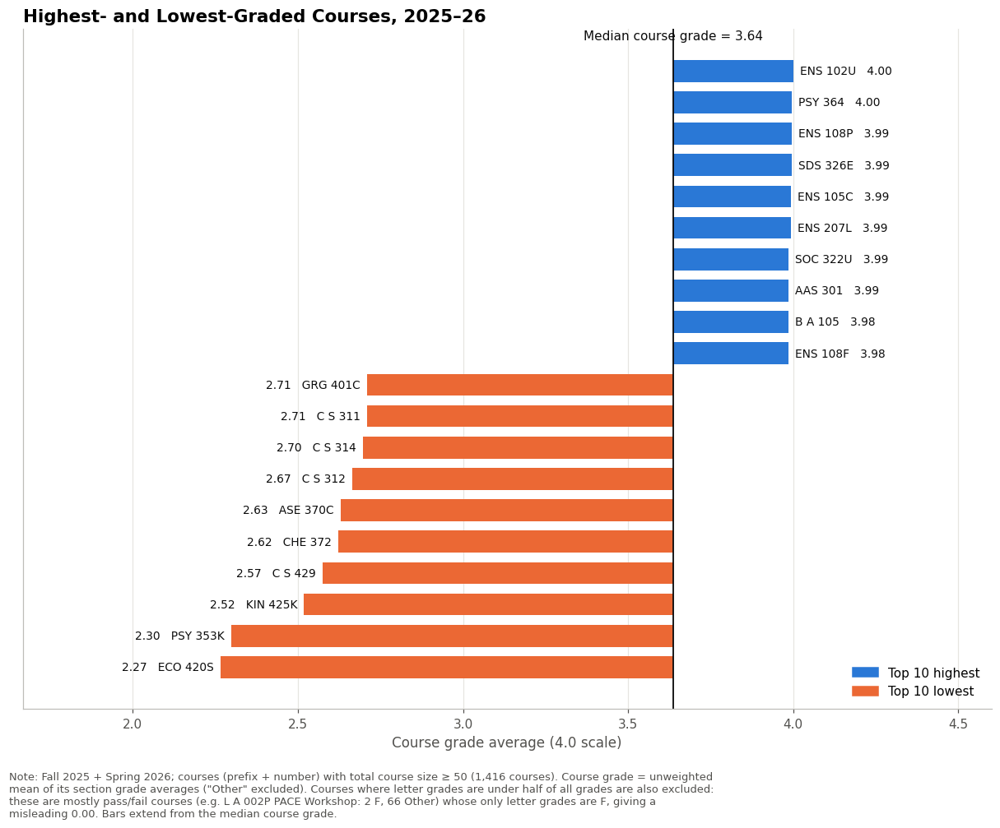

In [35]:
q10_all = ay[ay.avg.notna()].groupby(['Course Prefix', 'Course Number']).agg(
    grade=('avg', 'mean'), enrollment=('size', 'sum'), sections=('avg', 'count'),
    letter_grades=('n_letter', 'sum'), title=('Course Title', lambda s: ' / '.join(s.value_counts().index[:3])),
    department=('Department/Program', 'first'))
q10_all = q10_all[(q10_all.enrollment >= 50) & (q10_all.letter_grades >= 0.5 * q10_all.enrollment)]
median10 = q10_all.grade.median()
hi = q10_all.nlargest(10, 'grade'); lo10 = q10_all.nsmallest(10, 'grade')
plot10 = pd.concat([hi, lo10.sort_values('grade', ascending=False)])
fig, ax = plt.subplots(figsize=(11, 8.5))
for i, ((p, n), r) in enumerate(plot10.iterrows()):
    up = r.grade >= median10
    ax.barh(i, r.grade - median10, left=median10, color=BLUE if up else ORANGE, height=0.7)
    ax.text(r.grade + (0.02 if up else -0.02), i, f'{p} {n}   {r.grade:.2f}' if up else f'{r.grade:.2f}   {p} {n}',
            va='center', ha='left' if up else 'right', fontsize=9, color=INK)
ax.axvline(median10, color=INK, lw=1.2)
ax.text(median10, -1, f'Median course grade = {median10:.2f}', ha='center', fontsize=10, color=INK)
ax.set_yticks([]); ax.invert_yaxis(); ax.grid(axis='y', visible=False)
ax.set(xlim=(lo10.grade.min() - 0.6, 4.6), xlabel='Course grade average (4.0 scale)',
       title='Highest- and Lowest-Graded Courses, 2025–26')
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in (BLUE, ORANGE)],
          labels=['Top 10 highest', 'Top 10 lowest'], loc='lower right')
add_note(fig, f'Fall 2025 + Spring 2026; courses (prefix + number) with total course size ≥ 50 ({len(q10_all):,} courses). '
              'Course grade = unweighted mean of its section grade averages ("Other" excluded). Courses where letter grades are under half of '
              'all grades are also excluded: these are mostly pass/fail courses (e.g. L A 002P PACE Workshop: 2 F, 66 Other) whose only letter grades are F, '
              'giving a misleading 0.00. Bars extend from the median course grade.', width=130)
save(fig, '3_3_top_bottom_courses')

### 3.4 Table: the 20 courses from §3.3

`Course Title` comes from the dashboard's *Course Title* field (the *Course* field is the title plus section number). Where sections carry different topic titles, up to three are listed.

In [36]:
q11 = plot10.reset_index()
q11.insert(0, 'Group', np.where(q11.grade >= median10, 'Top 10 highest', 'Top 10 lowest'))
q11.insert(2, 'Prefix Name', q11['Course Prefix'].map(lambda p: prefix_names.get(p, dept_names.get(p))))
q11 = q11.rename(columns={'title': 'Course Title', 'department': 'Department/Program', 'grade': 'Grade Average',
                          'enrollment': 'Enrollment', 'sections': 'Sections', 'letter_grades': 'Letter Grades'})
q11 = q11[['Group', 'Course Prefix', 'Prefix Name', 'Course Number', 'Course Title', 'Department/Program',
           'Sections', 'Enrollment', 'Letter Grades', 'Grade Average']]
q11['Grade Average'] = q11['Grade Average'].round(3)
display(q11.style.hide(axis='index'))

Group,Course Prefix,Prefix Name,Course Number,Course Title,Department/Program,Sections,Enrollment,Letter Grades,Grade Average
Top 10 highest,ENS,Ensemble,102U,UNIVERSITY ORCHESTRA,Ensemble,1,72,70,4.000000
Top 10 highest,PSY,Psychology,364,INTRO TO CLINICAL PSYCH-WB,Psychology,2,691,682,3.995000
Top 10 highest,ENS,Ensemble,108P,LONGHORN PEP BAND,Ensemble,3,272,263,3.995000
Top 10 highest,SDS,Statistics and Data Sciences,326E,ELEMENTS OF STAT MACH LEARNING,Statistics And Data Sciences,2,183,178,3.995000
Top 10 highest,ENS,Ensemble,105C,JAZZ COMBOS,Ensemble,2,97,95,3.993000
Top 10 highest,ENS,Ensemble,207L,LONGHORN BAND,Ensemble,1,422,413,3.993000
Top 10 highest,SOC,Sociology,322U,UNITED STATES IMMIGRATION,Sociology,1,74,74,3.987000
Top 10 highest,AAS,Asian American Studies,301,INTRO TO ASIAN AMER STUDIES,Asian American Studies,1,69,68,3.985000
Top 10 highest,B A,Business Administration,105,LEADERSHIP-MSS,Business Administration,1,134,132,3.985000
Top 10 highest,ENS,Ensemble,108F,ORANGE CONCERT BAND,Ensemble,1,66,64,3.984000


### 3.5 Top 3 highest- and lowest-graded courses within each prefix

For each prefix in §3.1–3.2, using the same eligible courses as §3.3 (Fall 2025 + Spring 2026, total course size ≥ 50, letter grades at least half of all grades). Bars start at each prefix's median course grade.

Course Prefix,Prefix Name,Rank,Course Number,Course Title,Sections,Enrollment,Grade Average,Prefix median,Eligible courses
M,Mathematics,Top 1,339G,PREDICTIVE ANALYTICS,2,74,3.752,3.347,40
M,Mathematics,Top 2,310P,MODERN MATHEMATICS: PLAN II,2,87,3.720,3.347,40
M,Mathematics,Top 3,362M,INTRO TO STOCHASTIC PROCESSES,4,139,3.713,3.347,40
M,Mathematics,Bottom 1,408L,INTEGRAL CALCULUS,14,706,2.729,3.347,40
M,Mathematics,Bottom 2,408K,DIFFERENTIAL CALCULUS,10,546,2.859,3.347,40
M,Mathematics,Bottom 3,329F,THEORY OF INTEREST,8,307,2.888,3.347,40
PHY,Physics,Top 1,105N,LAB FOR PHY 302L/303L/317L,77,"1,691",3.795,3.432,23
PHY,Physics,Top 2,329,INTRO TO COMPUTATIONAL PHYSICS,2,55,3.793,3.432,23
PHY,Physics,Top 3,101L,LABORATORY FOR PHY 301,5,88,3.763,3.432,23
PHY,Physics,Bottom 1,303L,ENGINEERING PHYSICS II,19,509,3.067,3.432,23


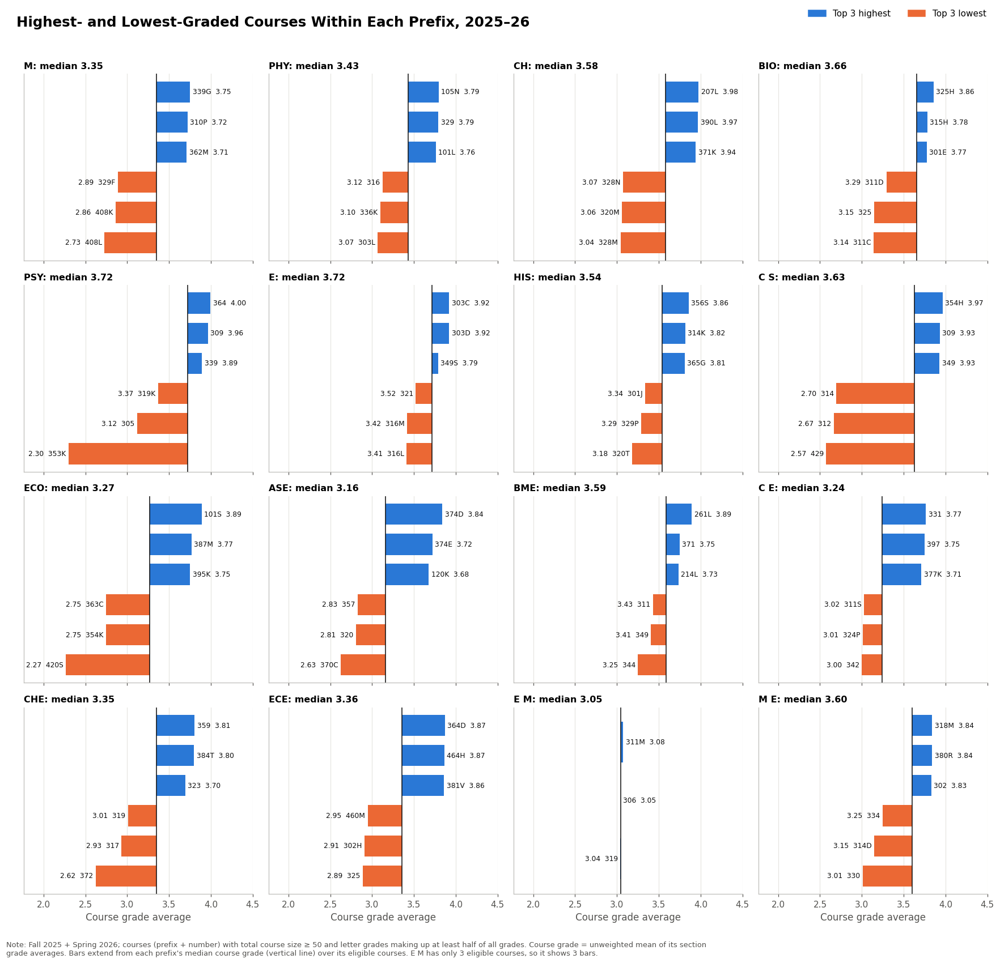

In [37]:
elig = q10_all.reset_index()
rows = []
for p in TREND_PREFIXES:
    d = elig[elig['Course Prefix'] == p]
    top = d.nlargest(3, 'grade')
    bottom = d.drop(top.index).nsmallest(3, 'grade')
    for label, part in [('Top', top), ('Bottom', bottom)]:
        for rank, (_, r) in enumerate(part.iterrows(), 1):
            rows.append({'Course Prefix': p, 'Prefix Name': TREND_PREFIXES[p], 'Rank': f'{label} {rank}',
                         'Course Number': r['Course Number'], 'Course Title': r.title, 'Sections': r.sections,
                         'Enrollment': r.enrollment, 'Grade Average': r.grade, 'Prefix median': d.grade.median(),
                         'Eligible courses': len(d)})
q35 = pd.DataFrame(rows)
display(q35.style.hide(axis='index').format({'Grade Average': '{:.3f}', 'Prefix median': '{:.3f}', 'Enrollment': '{:,}'}))

fig, axes = plt.subplots(4, 4, figsize=(16, 15), sharex=True)
xlo = q35['Grade Average'].min() - 0.5
for ax, p in zip(axes.flat, TREND_PREFIXES):
    d = q35[q35['Course Prefix'] == p]
    d = pd.concat([d[d.Rank.str.startswith('Top')], d[d.Rank.str.startswith('Bottom')].iloc[::-1]])
    med = d['Prefix median'].iloc[0]
    for i, (_, r) in enumerate(d.iterrows()):
        g_ = r['Grade Average']; up = g_ >= med
        ax.barh(i, g_ - med, left=med, color=BLUE if r.Rank.startswith('Top') else ORANGE, height=0.7)
        ax.text(g_ + (0.03 if up else -0.03), i, f"{r['Course Number']}  {g_:.2f}" if up else f"{g_:.2f}  {r['Course Number']}",
                va='center', ha='left' if up else 'right', fontsize=8, color=INK)
    ax.axvline(med, color=INK, lw=1)
    ax.set_title(f'{p}: median {med:.2f}', fontsize=10.5)
    ax.set_yticks([]); ax.set_ylim(len(d) - 0.4, -0.6); ax.grid(axis='y', visible=False)
    ax.set_xlim(xlo, 4.5)
for ax in axes[-1]:
    ax.set_xlabel('Course grade average')
fig.suptitle('Highest- and Lowest-Graded Courses Within Each Prefix, 2025–26', x=0.01, ha='left', fontsize=16, fontweight='bold')
fig.legend(handles=[Patch(color=BLUE, label='Top 3 highest'), Patch(color=ORANGE, label='Top 3 lowest')], loc='upper right',
           bbox_to_anchor=(0.99, 0.995), ncol=2)
fig.tight_layout(rect=(0, 0, 1, 0.965))
add_note(fig, 'Fall 2025 + Spring 2026; courses (prefix + number) with total course size ≥ 50 and letter grades making up at least half of all '
              'grades. Course grade = unweighted mean of its section grade averages. Bars extend from each prefix\'s median course grade '
              '(vertical line) over its eligible courses. ' + ''.join(f'{p} has only {n} eligible courses, so it shows {n} bars. '
              for p, n in q35.groupby('Course Prefix')['Eligible courses'].first().items() if n < 6), width=190, layout=False)
save(fig, '3_5_top3_by_prefix')

### 3.6 Foreign-language classes (Fall 2025, Spring 2026, Summer 2026)

Language prefixes were chosen from the catalog prefix names: every prefix named for a single language, plus American Sign Language (ASL) and Indigenous Languages of Latin America (LAL). English (E) and English as a Second Language (ESL) are excluded. So are umbrella culture prefixes (e.g. MEL, SEL, GSD, ILA) and "Civilization" prefixes (SPC, ITC, F C), whose courses are mostly taught in English. Enrollment = summed course size; average grade = mean of section grade averages.

Language prefixes with no unredacted sections in these terms: ['BCM', 'BEN', 'DAN', 'POL', 'ROM', 'SAN', 'SWA', 'TAM', 'TEL', 'TUR', 'UKR']


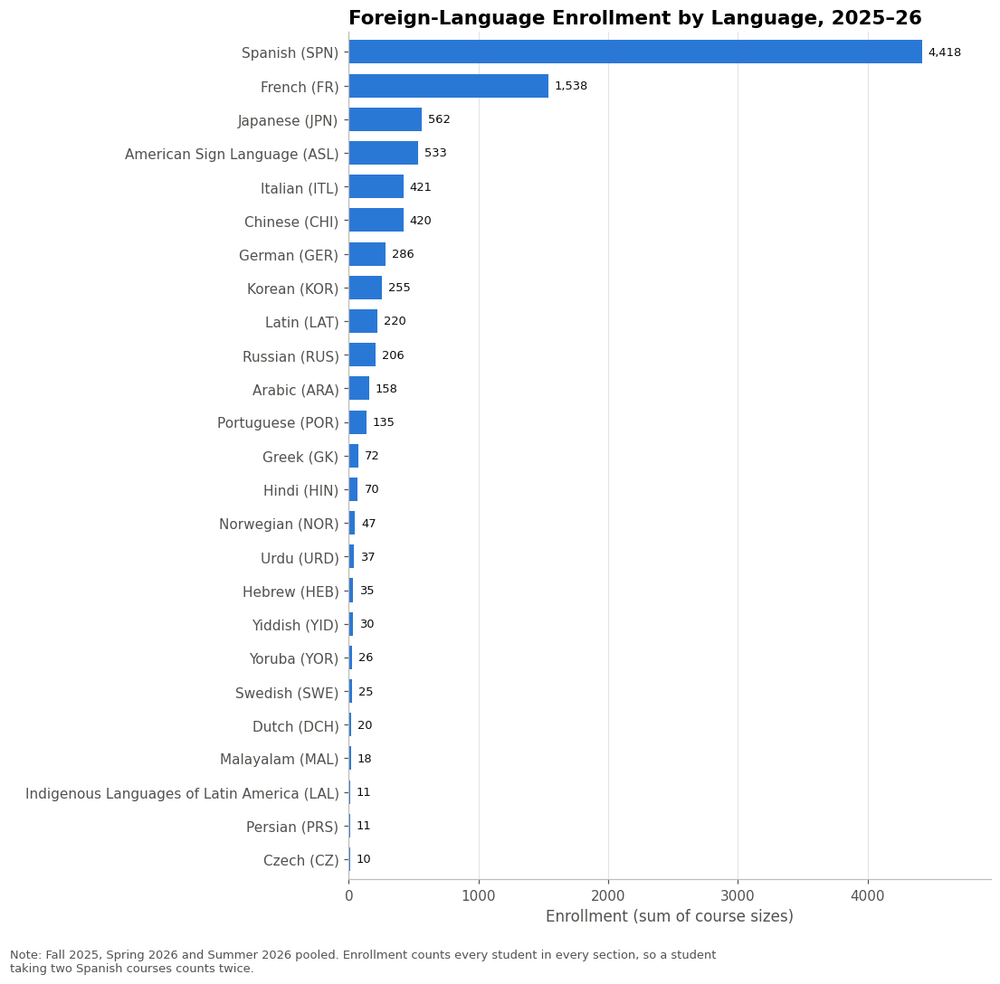

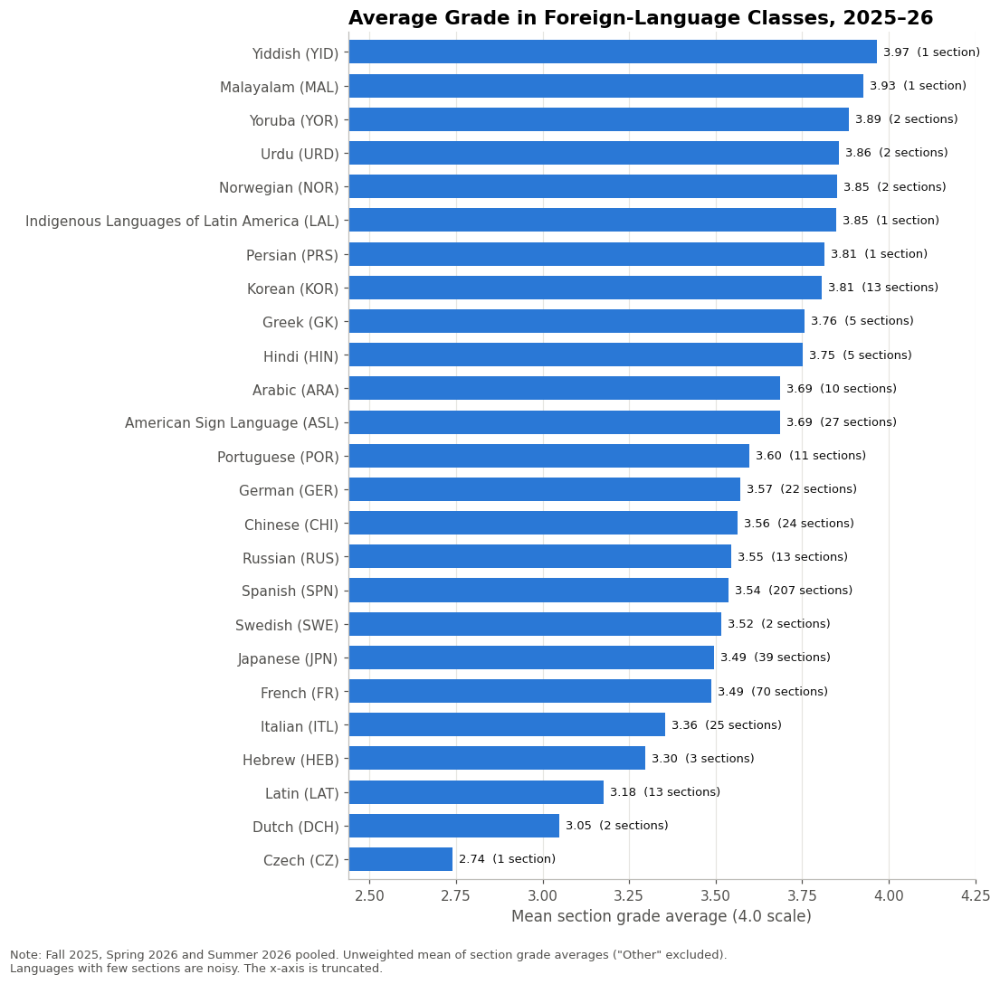

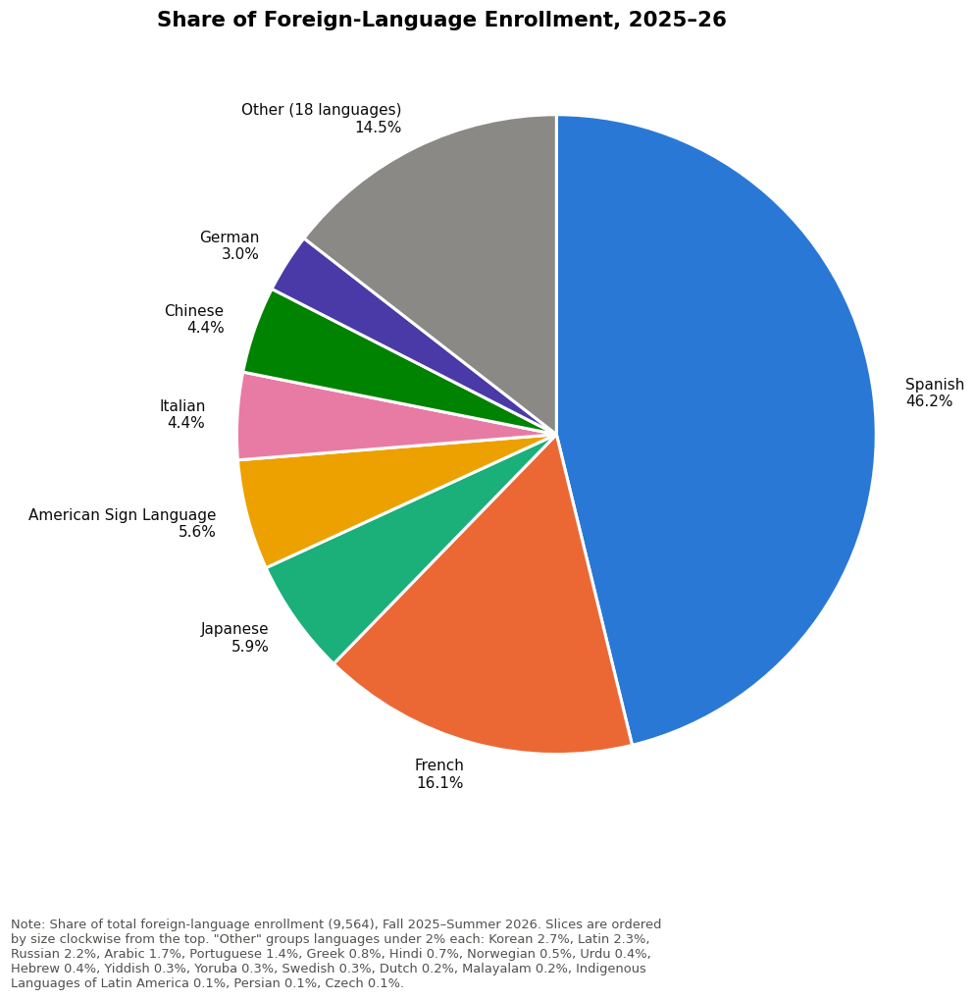

In [38]:
LANGS = ['SPN', 'FR', 'GER', 'ITL', 'POR', 'ROM', 'CHI', 'JPN', 'KOR', 'ARA', 'HEB', 'PRS', 'TUR', 'URD', 'HIN', 'BEN', 'MAL', 'TAM',
         'TEL', 'SAN', 'RUS', 'UKR', 'POL', 'CZ', 'BCM', 'GK', 'LAT', 'SWA', 'YOR', 'YID', 'DAN', 'DCH', 'NOR', 'SWE', 'ASL', 'LAL']
LANG_TERMS = ['Fall 2025', 'Spring 2026', 'Summer 2026']
lang = semesters(*LANG_TERMS)
lang = lang[lang['Course Prefix'].isin(LANGS)]
lg = lang.groupby('Course Prefix').agg(enrollment=('size', 'sum'), mean_grade=('avg', 'mean'), sections=('avg', 'count'),
                                        courses=('Course Number', 'nunique'))
lg['label'] = [f'{prefix_names.get(p, p)} ({p})' for p in lg.index]
print('Language prefixes with no unredacted sections in these terms:', sorted(set(LANGS) - set(lg.index)))

def lang_bars(col, fmt, title, xlabel, fname, note, xlim):
    d = lg.sort_values(col)
    fig, ax = plt.subplots(figsize=(10, 0.32 * len(d) + 1.5))
    ax.barh(d.label, d[col], color=BLUE, height=0.7)
    for i, (_, r) in enumerate(d.iterrows()):
        ax.text(r[col] + (xlim[1] - xlim[0]) * 0.01, i, fmt(r), va='center', fontsize=8.5, color=INK)
    ax.set(xlabel=xlabel, title=title, xlim=xlim); ax.grid(axis='y', visible=False); ax.margins(y=0.01)
    add_note(fig, 'Fall 2025, Spring 2026 and Summer 2026 pooled. ' + note, width=115)
    save(fig, fname)

lang_bars('enrollment', lambda r: f'{r.enrollment:,}', 'Foreign-Language Enrollment by Language, 2025–26', 'Enrollment (sum of course sizes)',
          '3_6a_language_enrollment', 'Enrollment counts every student in every section, so a student taking two Spanish courses counts twice.',
          (0, lg.enrollment.max() * 1.12))
lang_bars('mean_grade', lambda r: f'{r.mean_grade:.2f}  ({r.sections} section{"s" if r.sections != 1 else ""})', 'Average Grade in Foreign-Language Classes, 2025–26',
          'Mean section grade average (4.0 scale)', '3_6b_language_grades',
          'Unweighted mean of section grade averages ("Other" excluded). Languages with few sections are noisy. The x-axis is truncated.',
          (lg.mean_grade.min() - 0.3, 4.25))

share = lg.enrollment.sort_values(ascending=False) / lg.enrollment.sum() * 100
MAX_SLICES, MIN_SHARE = 8, 2.0
main = share[(share >= MIN_SHARE)].head(MAX_SLICES - 1)
other = share.drop(main.index)
slices = pd.concat([main.rename(lambda p: lg.label[p].rsplit(' (', 1)[0]),
                    pd.Series({f'Other ({len(other)} languages)': other.sum()})])
fig, ax = plt.subplots(figsize=(9, 9))
pie_colors = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET][:len(main)] + [GRAY]
ax.pie(slices, labels=[f'{n}\n{v:.1f}%' for n, v in slices.items()], colors=pie_colors, startangle=90, counterclock=False,
       labeldistance=1.1, wedgeprops=dict(edgecolor='white', linewidth=2), textprops=dict(fontsize=10, color=INK))
ax.set_title('Share of Foreign-Language Enrollment, 2025–26')
add_note(fig, f'Share of total foreign-language enrollment ({lg.enrollment.sum():,}), Fall 2025–Summer 2026. Slices are ordered by size clockwise from the top. '
              f'"Other" groups languages under {MIN_SHARE:g}% each: ' + ', '.join(f'{lg.label[p].rsplit(" (", 1)[0]} {v:.1f}%' for p, v in other.items()) + '.',
         width=100)
save(fig, '3_6c_language_pie')

## 4. COVID and online instruction

The "COVID year" in §4.1–4.2 is Fall 2020 + Spring 2021 (the first full academic year of the pandemic); §4.2 compares it with Fall 2019, the last fully pre-COVID semester. Time-series charts shade Spring 2020 through Summer 2021, the semesters taught mostly online or hybrid.

### 4.1 Grade distribution in the COVID year (2020–21)

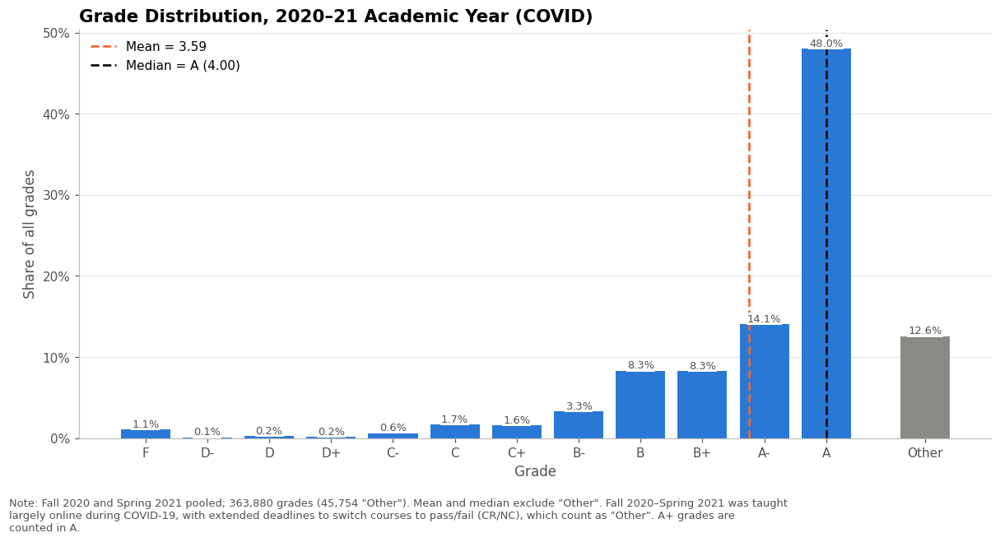

,2025–26,2020–21 (COVID)
grades,421333,363880
other_share,5.254276,12.573925
A_share,52.362621,48.018028
mean,3.555797,3.586624
median,A,A


In [39]:
h4 = grade_histogram(COVID, 'Grade Distribution, 2020–21 Academic Year (COVID)', '4_1_grade_hist_2020_21_covid',
                     'Fall 2020–Spring 2021 was taught largely online during COVID-19, with extended deadlines to switch courses to '
                     'pass/fail (CR/NC), which count as "Other". A+ grades are counted in A.')
display(pd.DataFrame({'2025–26': h3, '2020–21 (COVID)': h4}))

### 4.2 Course grades: pre-COVID (Fall 2019) vs the COVID year

Fall 2019 is the last semester entirely before COVID (Spring 2020 moved online in March). A course is a prefix + number offered in Fall 2019 and in the COVID year (Fall 2020 and/or Spring 2021). Within each semester the sections' distributions are combined; the COVID-year grade averages the two semesters when a course was offered in both. Course size is summed within each period, and the dot weight is the mean of the two periods' sizes. Points above the dashed line had higher grades during COVID.

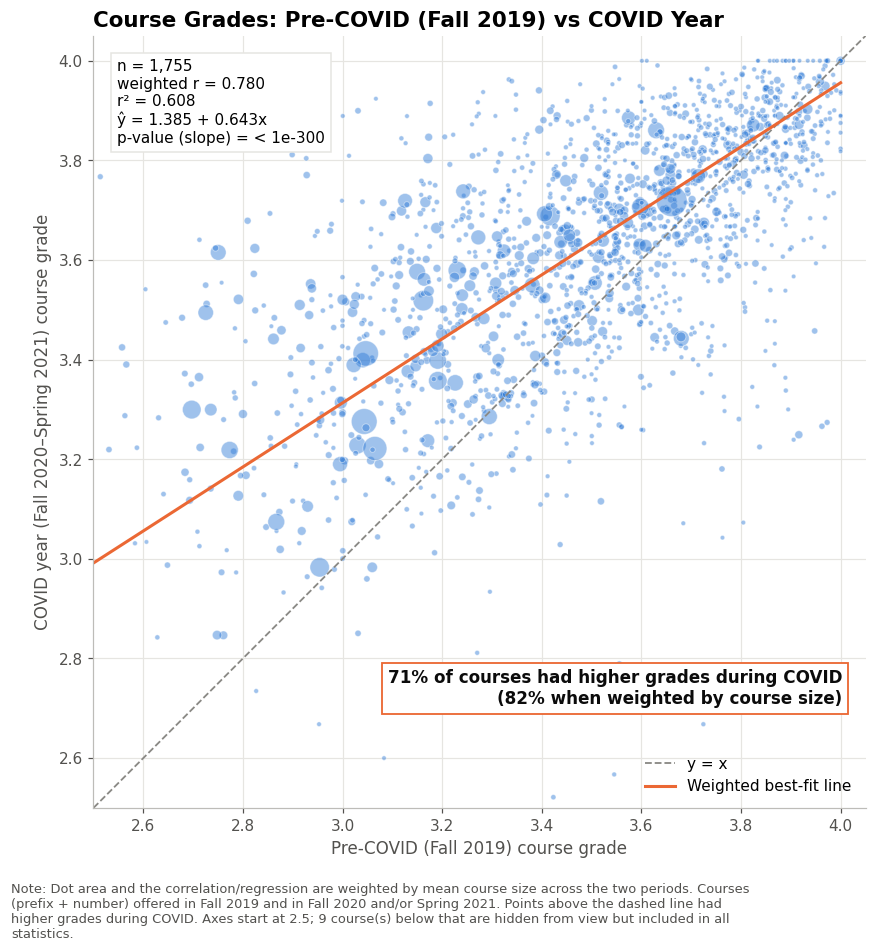

70.7% of 1,755 courses had a higher grade in the COVID year than in Fall 2019 (82.2% weighted by course size); mean change +0.124 grade points


In [40]:
def period_courses(sems, key='Course Number'):
    per_sem = pool(semesters(*sems), ['Semester', 'Course Prefix', key])
    per_sem = per_sem[per_sem.avg.notna()]
    return per_sem.groupby(['Course Prefix', key]).agg(grade=('avg', 'mean'), size=('size', 'sum'))

PRE_COVID = ['Fall 2019']
q42 = period_courses(PRE_COVID).join(period_courses(COVID), lsuffix='_pre', rsuffix='_covid', how='inner')
higher = (q42.grade_covid > q42.grade_pre).mean()
w_higher = np.average(q42.grade_covid > q42.grade_pre, weights=(q42.size_pre + q42.size_covid) / 2)
res42 = weighted_scatter(q42.grade_pre, q42.grade_covid, (q42.size_pre + q42.size_covid) / 2,
                         'Pre-COVID (Fall 2019) course grade', 'COVID year (Fall 2020–Spring 2021) course grade',
                         'Course Grades: Pre-COVID (Fall 2019) vs COVID Year', '4_2_scatter_precovid_vs_covid',
                         'Courses (prefix + number) offered in Fall 2019 and in Fall 2020 and/or Spring 2021. Points above the dashed '
                         'line had higher grades during COVID.', 'mean course size across the two periods',
                         extra_text=f'{higher:.0%} of courses had higher grades during COVID\n({w_higher:.0%} when weighted by course size)')
print(f"{higher:.1%} of {len(q42):,} courses had a higher grade in the COVID year than in Fall 2019 "
      f"({w_higher:.1%} weighted by course size); mean change {(q42.grade_covid - q42.grade_pre).mean():+.3f} grade points")

### 4.3 Web-based courses as a share of all courses

Unit = course section. Share of sections whose title marks them web-based (see §0.4), shown as a percentage (share × 100).

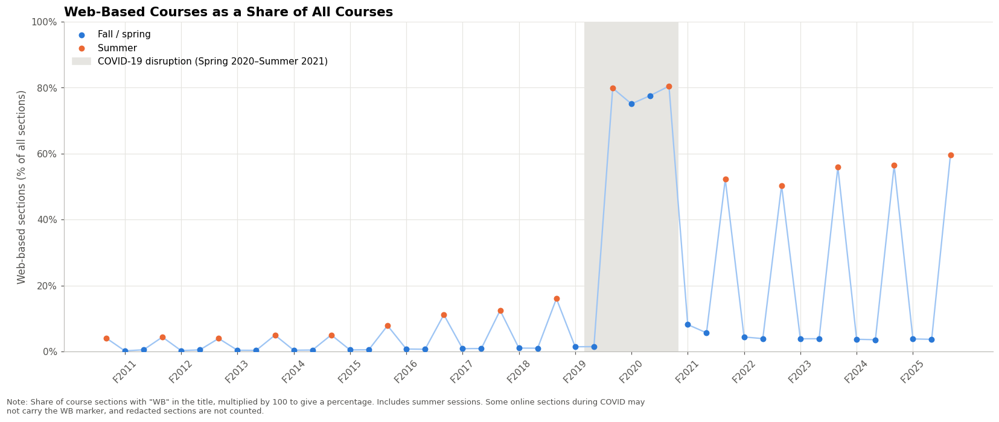

Semester,Summer 2011,Fall 2011,Spring 2012,Summer 2012,Fall 2012,Spring 2013,Summer 2013,Fall 2013,Spring 2014,Summer 2014,Fall 2014,Spring 2015,Summer 2015,Fall 2015,Spring 2016,Summer 2016,Fall 2016,Spring 2017,Summer 2017,Fall 2017,...,Spring 2020,Summer 2020,Fall 2020,Spring 2021,Summer 2021,Fall 2021,Spring 2022,Summer 2022,Fall 2022,Spring 2023,Summer 2023,Fall 2023,Spring 2024,Summer 2024,Fall 2024,Spring 2025,Summer 2025,Fall 2025,Spring 2026,Summer 2026
sections,851.0,5976.0,5754.0,798.0,6103.0,5871.0,808.0,6171.0,5810.0,744.0,6020.0,5622.0,656.0,5924.0,5559.0,585.0,5807.0,5508.0,573.0,5767.0,...,5045.0,631.0,5513.0,5212.0,584.0,5792.0,5495.0,559.0,5779.0,5415.0,542.0,5749.0,5409.0,529.0,5814.0,5443.0,535.0,5805.0,5626.0,522.0
web,35.0,12.0,31.0,35.0,17.0,30.0,32.0,24.0,21.0,37.0,24.0,26.0,33.0,29.0,30.0,46.0,44.0,38.0,64.0,50.0,...,75.0,504.0,4140.0,4045.0,470.0,473.0,312.0,292.0,255.0,212.0,273.0,222.0,210.0,296.0,216.0,195.0,302.0,222.0,208.0,311.0
pct,4.1,0.2,0.5,4.4,0.3,0.5,4.0,0.4,0.4,5.0,0.4,0.5,5.0,0.5,0.5,7.9,0.8,0.7,11.2,0.9,...,1.5,79.9,75.1,77.6,80.5,8.2,5.7,52.2,4.4,3.9,50.4,3.9,3.9,56.0,3.7,3.6,56.4,3.8,3.7,59.6


In [41]:
web = sec.groupby('Semester').agg(sections=('d_web', 'size'), web=('d_web', 'sum')).reindex(ALL_SEMS)
web['pct'] = web.web / web.sections * 100
xs = np.arange(len(ALL_SEMS)); is_su = np.array([s.startswith('Summer') for s in ALL_SEMS])
fig, ax = plt.subplots(figsize=(15, 6))
shade_covid(ax, ALL_SEMS)
ax.plot(xs, web.pct, color='#9ec5f4', lw=1.5, zorder=2)
ax.scatter(xs[~is_su], web.pct[~is_su], color=BLUE, s=30, zorder=3, label='Fall / spring')
ax.scatter(xs[is_su], web.pct[is_su], color=ORANGE, s=30, zorder=3, label='Summer')
ticks = [i for i, s in enumerate(ALL_SEMS) if s.startswith('Fall')]
ax.set_xticks(ticks, [ALL_SEMS[i].replace('Fall ', 'F') for i in ticks], rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set(ylabel='Web-based sections (% of all sections)', title='Web-Based Courses as a Share of All Courses', ylim=(0, 100))
h, l = ax.get_legend_handles_labels(); ax.legend(h + [COVID_PATCH], l + [COVID_PATCH.get_label()], loc='upper left')
add_note(fig, 'Share of course sections with "WB" in the title, multiplied by 100 to give a percentage. Includes summer sessions. '
              'Some online sections during COVID may not carry the WB marker, and redacted sections are not counted.', width=160)
save(fig, '4_3_web_share')
display(web.assign(pct=web.pct.round(1)).T)

### 4.4 Grades in web-based courses

First chart: all web-based sections each semester (including summer). Second chart: a **fixed pool** of courses (prefix + number) that had web-based sections in *every* fall and spring semester from Fall 2018 to Spring 2023. That window (two pre-COVID years, the COVID year and two post-COVID years) was chosen because it keeps the largest pool; windows running to 2024 or 2026 keep fewer courses. Summer is left out of the fixed pool because requiring it shrinks the pool further. Following the same courses rules out the explanation that newly added (possibly easier) web-based courses drove the averages.

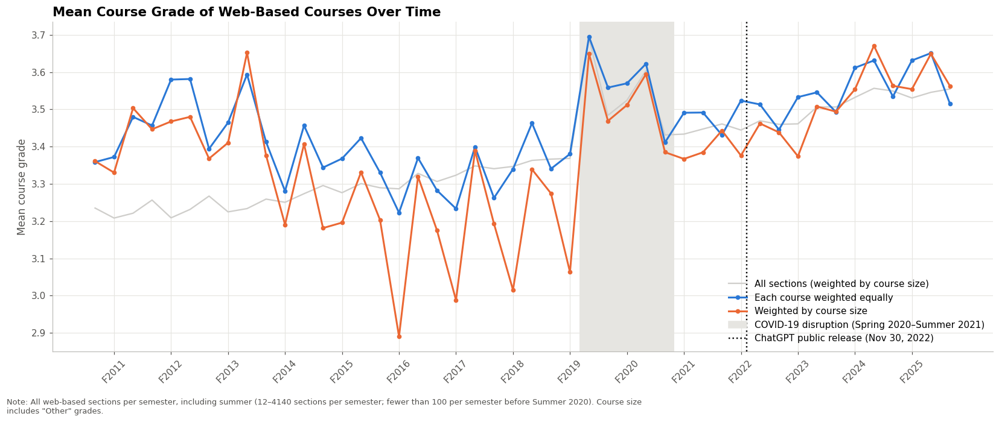

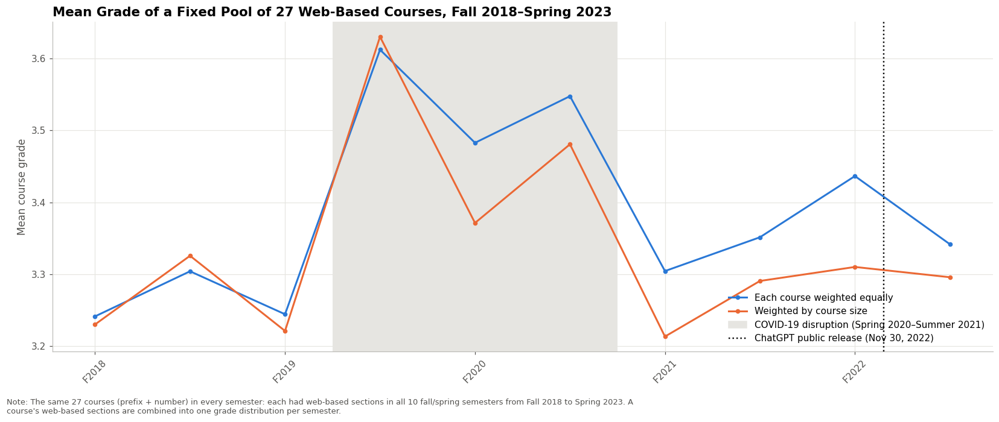

mean_grade  mean_size                    Course Title
Course Prefix Base Number                                                       
MKT           320F               3.26      799.6     FOUNDATIONS OF MARKETING-WB
ACC           310F               3.09      697.9    FOUNDATIONS OF ACCOUNTING-WB
MAN           320F               3.15      667.3     FNDTNS MGMT/ORG BEHAVIOR-WB
FIN           320F               3.36      548.7       FOUNDATIONS OF FINANCE-WB
MIS           302F               3.32      485.5      FOUNDTNS INFO TECH MGMT-WB
LEB           320F               3.26      443.0    FNDTNS OF BUSN LAW/ETHICS-WB
PSY           364                3.79      348.7      INTRO TO CLINICAL PSYCH-WB
C C           303                3.63      314.5  INTRO TO CLASSICAL MYTHOLGY-WB
              302                3.59      267.0        INTRO TO ANCIENT ROME-WB
ANT           301                2.69      249.3      BIOLOGICAL ANTHROPOLOGY-WB
RTF           306                3.25      235.6      INTRO WORLD CINEMA HIST-WB
ADV           309R               3.31      200.0       INTRO TO ADVR/P R RSCH-WB
RTF           303C               3.45      179.0   INTRO MEDIA/ENT INDUSTRIES-WB
              329C               3.72      171.4      DIGITL MEDIA PRODUCTION-WB
EDP           371                3.44      150.7   INTRODUCTION TO STATISTICS-WB
J             336F               3.87      143.7      SOCIAL MEDIA JOURNALISM-WB
CMS           341                3.52      140.6       DIGITAL COMMUNICATIONS-WB
KIN           395                3.67      136.5   42-FACILITY AND EVENT MGMT-WB
P R           309                3.36       87.0       INTRO TO ADVR/P R RSCH-WB
ADV           323                3.46       84.1      PUBLIC COMM OF SCI/TECH-WB
FR            406                3.37       79.2        INTRODUCTORY FRENCH I-WB
CMS           313M               3.54       72.8   ORGANIZATIONAL COMMUNICATN-WB
FR            407                3.18       62.6       INTRODUCTORY FRENCH II-WB
              412K               3.41       50.6        INTERMEDIATE FRENCH I-WB
LAT           506                2.86       22.7           FIRST-YEAR LATIN I-WB
S W           387R               3.76       18.3  18-SOCL CONTRUCTN OF DISABL-WB
LAT           507                3.16       13.9          FIRST-YEAR LATIN II-WB

In [42]:
w = sec[(sec.d_web == 1) & sec.avg.notna()]
def grade_lines(df, by, order):
    g = df.assign(pts=df.avg * df['size']).groupby(by)
    return pd.DataFrame({'equal': g.avg.mean(), 'size_weighted': g.pts.sum() / g['size'].sum(), 'n': g.size()}).reindex(order)
wl = grade_lines(w, 'Semester', ALL_SEMS)
al = grade_lines(sec[sec.avg.notna()], 'Semester', ALL_SEMS)

def web_grade_chart(lines, order, title, fname, note, ref=None):
    xs = np.arange(len(order))
    fig, ax = plt.subplots(figsize=(15, 6))
    shade_covid(ax, order)
    chatgpt_line(ax, chatgpt_sem(order))
    if ref is not None:
        ax.plot(xs, ref.size_weighted, color='#cfcecb', lw=1.5, label='All sections (weighted by course size)')
    ax.plot(xs, lines.equal, color=BLUE, marker='o', ms=4, label='Each course weighted equally')
    ax.plot(xs, lines.size_weighted, color=ORANGE, marker='o', ms=4, label='Weighted by course size')
    ticks = [i for i, s in enumerate(order) if s.startswith('Fall')]
    ax.set_xticks(ticks, [order[i].replace('Fall ', 'F') for i in ticks], rotation=45)
    ax.set(ylabel='Mean course grade', title=title)
    h, l = ax.get_legend_handles_labels(); ax.legend(h + [COVID_PATCH, CHATGPT_HANDLE], l + [COVID_PATCH.get_label(), CHATGPT_LABEL], loc='lower right')
    add_note(fig, note, width=160)
    save(fig, fname)

web_grade_chart(wl, ALL_SEMS, 'Mean Course Grade of Web-Based Courses Over Time', '4_4a_web_grades',
                f'All web-based sections per semester, including summer ({int(wl.n.min())}–{int(wl.n.max())} sections per semester; '
                f'fewer than 100 per semester before Summer 2020). Course size includes "Other" grades.', ref=al)

PANEL = [s for s in FS_SEMS if SEM_KEY['Fall 2018'] <= SEM_KEY[s] <= SEM_KEY['Spring 2023']]
wp_ = pool(w[w.Semester.isin(PANEL)], ['Semester', 'Course Prefix', 'Base Number'])
present = wp_.groupby(['Course Prefix', 'Base Number']).Semester.nunique()
keep = present[present == len(PANEL)].index
panel = wp_.set_index(['Course Prefix', 'Base Number']).loc[keep].reset_index()
pl = grade_lines(panel, 'Semester', PANEL)
web_grade_chart(pl, PANEL, f'Mean Grade of a Fixed Pool of {len(keep)} Web-Based Courses, Fall 2018–Spring 2023', '4_4b_web_grades_fixed_pool',
                f'The same {len(keep)} courses (prefix + number) in every semester: each had web-based sections in all {len(PANEL)} fall/spring '
                'semesters from Fall 2018 to Spring 2023. A course\'s web-based sections are combined into one grade distribution per semester.')
titles = w[w.Semester.isin(PANEL)].groupby(['Course Prefix', 'Base Number'])['Course Title'].agg(lambda s: s.mode().iat[0])
display(panel.groupby(['Course Prefix', 'Base Number']).agg(mean_grade=('avg', 'mean'), mean_size=('size', 'mean'))
        .join(titles).round(2).sort_values('mean_size', ascending=False))

## 5. Same course, different terms and sequences

### 5.1 Fall 2025 vs Spring 2026 course grades

Courses (prefix + number) offered in both semesters; sections within a semester are combined into one distribution.

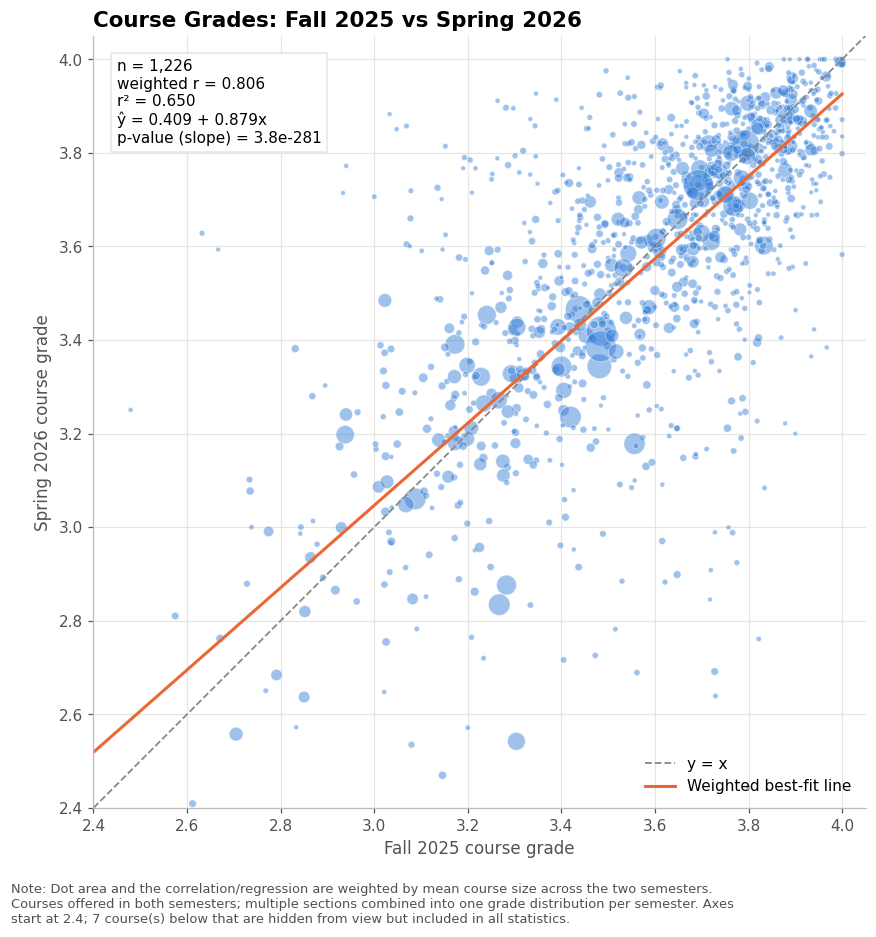

In [43]:
def sem_courses(sems, key='Course Number'):
    d = pool(semesters(*sems), ['Course Prefix', key])
    return d[d.avg.notna()].set_index(['Course Prefix', key])[['avg', 'size']]

q12 = sem_courses(['Fall 2025']).join(sem_courses(['Spring 2026']), lsuffix='_f', rsuffix='_s', how='inner')
res12 = weighted_scatter(q12.avg_f, q12.avg_s, (q12.size_f + q12.size_s) / 2, 'Fall 2025 course grade', 'Spring 2026 course grade',
                         'Course Grades: Fall 2025 vs Spring 2026', '5_1_scatter_fall_vs_spring',
                         'Courses offered in both semesters; multiple sections combined into one grade distribution per semester.',
                         'mean course size across the two semesters')

### 5.2 Fall 2025–Spring 2026 vs Summer 2026 course grades

Summer session letters are stripped from course numbers for matching (`F311` → `311`).

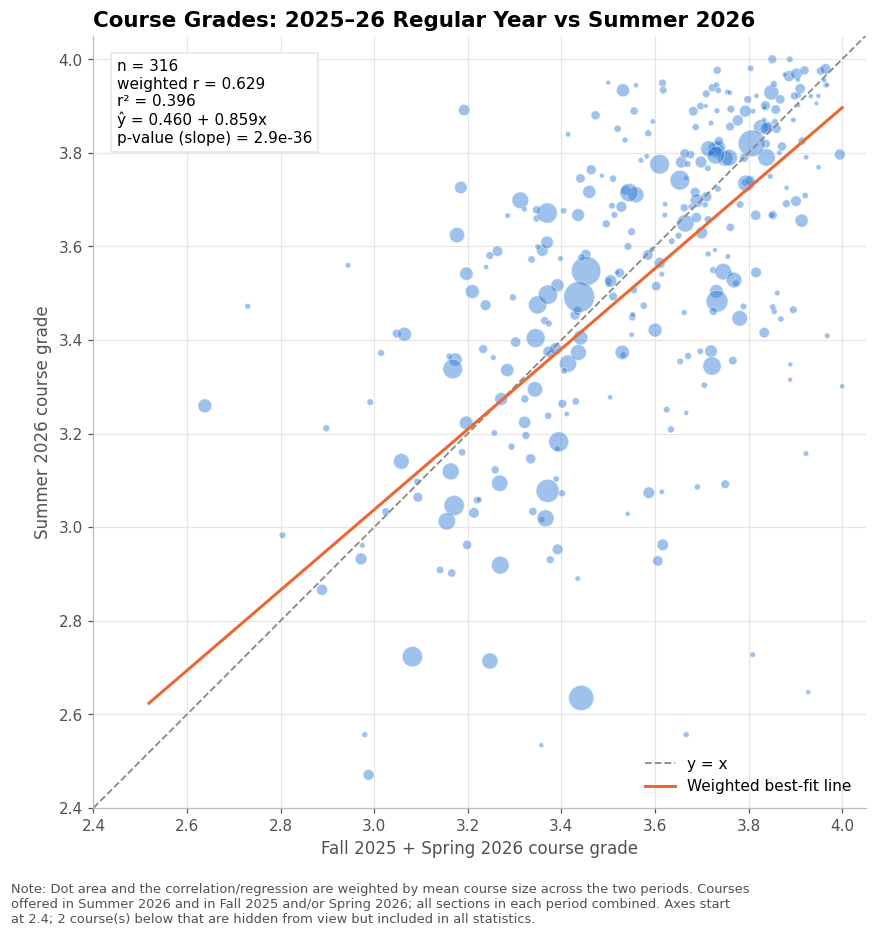

51% of courses have a higher summer grade


In [44]:
q13 = sem_courses(AY, 'Base Number').join(sem_courses(['Summer 2026'], 'Base Number'), lsuffix='_fs', rsuffix='_su', how='inner')
res13 = weighted_scatter(q13.avg_fs, q13.avg_su, (q13.size_fs + q13.size_su) / 2, 'Fall 2025 + Spring 2026 course grade',
                         'Summer 2026 course grade', 'Course Grades: 2025–26 Regular Year vs Summer 2026', '5_2_scatter_year_vs_summer',
                         'Courses offered in Summer 2026 and in Fall 2025 and/or Spring 2026; all sections in each period combined.',
                         'mean course size across the two periods')
print(f"{(q13.avg_su > q13.avg_fs).mean():.0%} of courses have a higher summer grade")

### 5.3 Fall vs spring vs summer across all years

Extends §5.1–5.2 to every academic year from 2011–12 to 2025–26 (Fall *Y*, Spring *Y+1*, Summer *Y+1*). An observation is a course (prefix + number, with summer session letters stripped) in one academic year; sections within a term are combined.
- The **line chart and table** use courses offered in all three terms of the same academic year, so the three means compare the same courses.
- The **scatterplots** pool all years: fall vs spring (courses offered in both), and fall + spring vs summer.

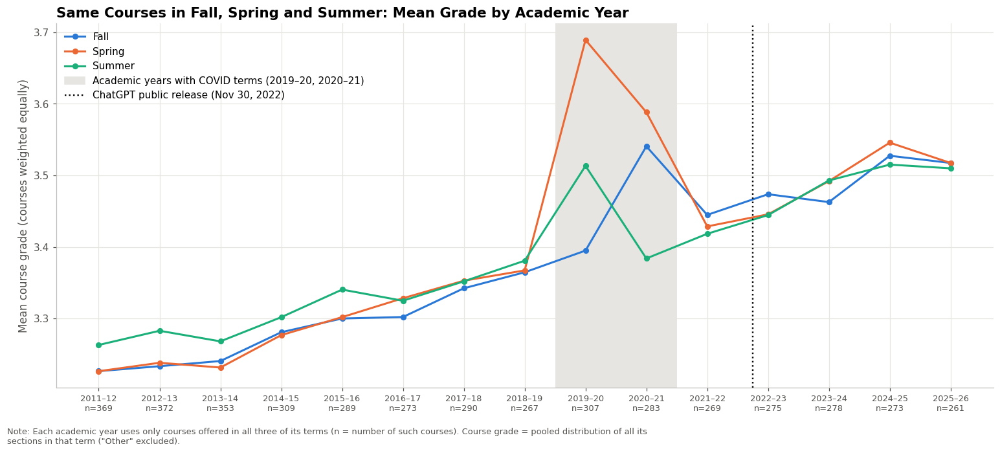

**All years pooled: 4,468 course-years offered in all three terms**

,mean (courses weighted equally),mean (weighted by course size),mean course size
Fall,3.367,3.285,303.444
Spring,3.392,3.326,281.107
Summer,3.379,3.365,57.070


,mean difference,share of course-years where Summer is higher,paired t-test p-value,n,share of course-years where Spring is higher
comparison,,,,,
Summer − Fall,0.012,0.540,0.012,4468,NaN
Summer − Spring,-0.014,0.498,0.0041,4468,NaN
Spring − Fall,0.025,NaN,5e-13,4468,0.556


In [45]:
sec['acad_year'] = sec.Year - (sec.Term != 'Fall').astype(int)
tc = pool(sec[sec.acad_year >= 2011], ['acad_year', 'Term', 'Course Prefix', 'Base Number'])
tc = tc[tc.avg.notna()]
wide = tc.pivot_table(index=['acad_year', 'Course Prefix', 'Base Number'], columns='Term', values=['avg', 'size'])
wide.columns = [f'{a}_{b}' for a, b in wide.columns]
tri = wide.dropna(subset=['avg_Fall', 'avg_Spring', 'avg_Summer'])
TERMS = [('Fall', BLUE), ('Spring', ORANGE), ('Summer', AQUA)]
by_year = tri.groupby('acad_year')[[f'avg_{t}' for t, _ in TERMS]].mean()
n_year = tri.groupby('acad_year').size()

fig, ax = plt.subplots(figsize=(14, 6))
ax.axvspan(2018.5, 2020.5, color=BAND, lw=0, zorder=0)
chatgpt_line(ax, 2021.75)            # Nov 30, 2022 ≈ a quarter of the way into academic year 2022–23 (centred on x = 2022)
for t, c in TERMS:
    ax.plot(by_year.index, by_year[f'avg_{t}'], color=c, marker='o', ms=5, label=t)
ax.set_xticks(by_year.index, [f'{y}–{str(y + 1)[2:]}\nn={n_year[y]}' for y in by_year.index], fontsize=8.5)
ax.set(ylabel='Mean course grade (courses weighted equally)', title='Same Courses in Fall, Spring and Summer: Mean Grade by Academic Year')
h, l = ax.get_legend_handles_labels()
ax.legend(h + [Patch(color=BAND), CHATGPT_HANDLE], l + ['Academic years with COVID terms (2019–20, 2020–21)', CHATGPT_LABEL], loc='upper left')
add_note(fig, 'Each academic year uses only courses offered in all three of its terms (n = number of such courses). Course grade = pooled '
              'distribution of all its sections in that term ("Other" excluded).', width=160)
save(fig, '5_3a_fall_spring_summer_by_year')

summary = pd.DataFrame({t: {'mean (courses weighted equally)': tri[f'avg_{t}'].mean(),
                            'mean (weighted by course size)': np.average(tri[f'avg_{t}'], weights=tri[f'size_{t}']),
                            'mean course size': tri[f'size_{t}'].mean()} for t, _ in TERMS}).T
display(Markdown(f'**All years pooled: {len(tri):,} course-years offered in all three terms**')); display(summary.round(3))
diffs = []
for a, b in [('Summer', 'Fall'), ('Summer', 'Spring'), ('Spring', 'Fall')]:
    d = tri[f'avg_{a}'] - tri[f'avg_{b}']
    diffs.append({'comparison': f'{a} − {b}', 'mean difference': d.mean(), f'share of course-years where {a} is higher': (d > 0).mean(),
                  'paired t-test p-value': fmt_p(stats.ttest_rel(tri[f'avg_{a}'], tri[f'avg_{b}']).pvalue), 'n': len(d)})
display(pd.DataFrame(diffs).set_index('comparison').round(3))

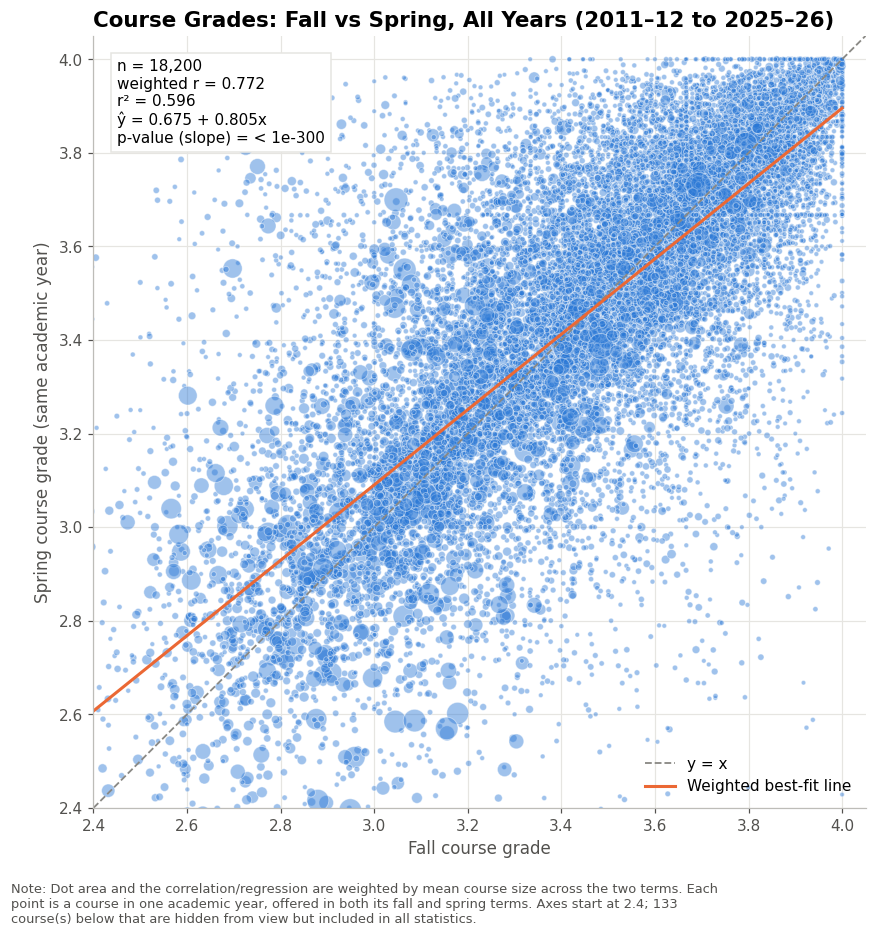

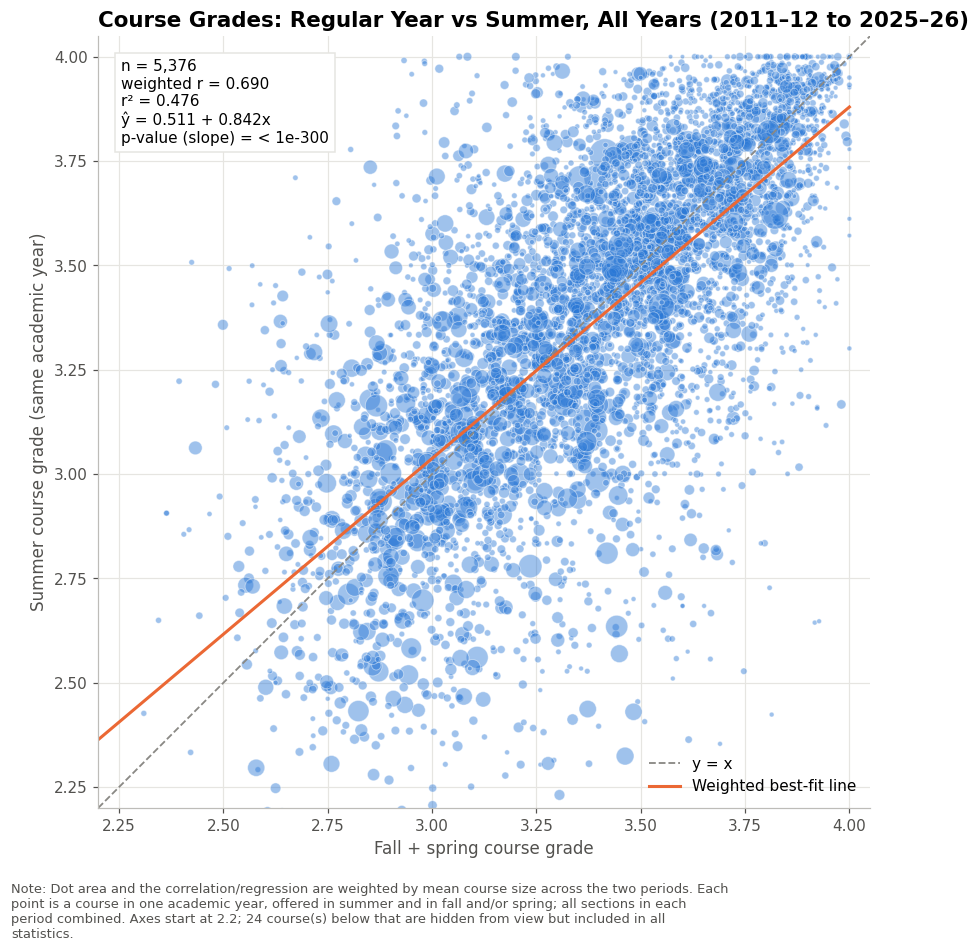

{'n': 5376,
 'r': np.float64(0.6901039264207408),
 'r2': np.float64(0.4762434292613257),
 'intercept': np.float64(0.5105430416299885),
 'slope': np.float64(0.8422563074934991),
 'p': np.float64(0.0)}

In [46]:
fsw = wide.dropna(subset=['avg_Fall', 'avg_Spring'])
weighted_scatter(fsw.avg_Fall, fsw.avg_Spring, (fsw.size_Fall + fsw.size_Spring) / 2, 'Fall course grade', 'Spring course grade (same academic year)',
                 'Course Grades: Fall vs Spring, All Years (2011–12 to 2025–26)', '5_3b_scatter_fall_vs_spring_all_years',
                 'Each point is a course in one academic year, offered in both its fall and spring terms.', 'mean course size across the two terms')
reg = pool(sec[sec.Term.isin(['Fall', 'Spring']) & (sec.acad_year >= 2011)], ['acad_year', 'Course Prefix', 'Base Number']).set_index(
    ['acad_year', 'Course Prefix', 'Base Number'])
reg = reg[reg.avg.notna()][['avg', 'size']].join(wide[['avg_Summer', 'size_Summer']].dropna(), how='inner')
weighted_scatter(reg.avg, reg.avg_Summer, (reg['size'] + reg.size_Summer) / 2, 'Fall + spring course grade', 'Summer course grade (same academic year)',
                 'Course Grades: Regular Year vs Summer, All Years (2011–12 to 2025–26)', '5_3c_scatter_year_vs_summer_all_years',
                 'Each point is a course in one academic year, offered in summer and in fall and/or spring; all sections in each period combined.',
                 'mean course size across the two periods')

### 5.4 I vs II course sequences

A sequence is a pair of courses in the same prefix whose normalized titles are identical except that one contains the numeral `I` and the other `II` (e.g. `DESIGN I` / `DESIGN II`).
Fall 2024, Spring 2025, Fall 2025 and Spring 2026 are pooled; all sections (and any course numbers sharing the title) are combined.

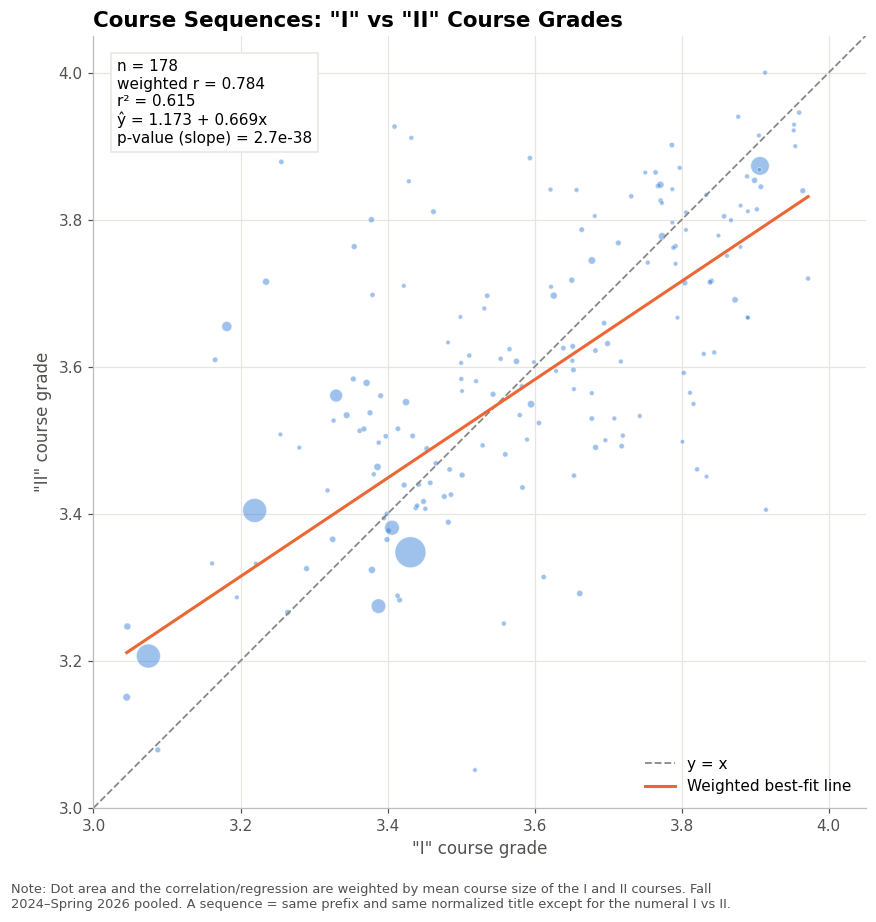

avg_I  avg_II  size_I  size_II   numbers_I  numbers_II
Course Prefix seq_base                                                                          
CH            PRINCIPLES OF CHEMISTRY     3.431   3.348  8641.0   7118.0         301         302
              ORGANIC CHEMISTRY           3.075   3.207  5272.0   4085.0  320M, 328M  320N, 328N
BIO           INTRODUCTORY BIOLOGY        3.219   3.405  5202.0   4117.0        311C        311D
CH            INTRO TO CHEMICAL PRACTICE  3.906   3.873  3583.0   1915.0        104M        104N
PHY           ENGINEERING PHYSICS         3.388   3.274  2166.0   1073.0        303K        303L
SPN           FIRST YEAR SPANISH          3.406   3.381  1868.0   1513.0        601D        610D
PHY           GENERAL PHYSICS             3.330   3.561  1345.0   1099.0        317K        317L
NEU           NEURAL SYSTEMS              3.181   3.655   806.0    580.0         330         335
CH            CHEMISTRY IN OUR WORLD      3.595   3.549   477.0    102.0        301N        302N
ACC           FINCL ACC STANDS AND ANLY   3.425   3.552   379.0    168.0        380K        380K
UTS           HANDS ON SCIENCE            3.045   3.150   373.0    260.0        306J        306K
H E           PROFESSIONAL DEVELOPMENT    3.773   3.777   349.0    272.0        101P        103P
FR            INTRODUCTORY FRENCH WB      3.386   3.464   349.0    218.0         406         407
ASL           AMERICAN SIGN LANGUAGE BEG  3.678   3.745   344.0    270.0        601D        610D
M             REAL ANALYSIS               3.325   3.365   300.0     58.0        365C        365D

In [47]:
SEQ_SEMS = ['Fall 2024', 'Spring 2025', 'Fall 2025', 'Spring 2026']
s14 = semesters(*SEQ_SEMS).copy()
s14 = s14[(s14.d_I + s14.d_II == 1) & (s14.d_III == 0)]
s14['numeral'] = np.where(s14.d_I == 1, 'I', 'II')
s14['seq_base'] = [' '.join(w for w in t.split() if w != n) for t, n in zip(s14.title_norm, s14.numeral)]
g14 = pool(s14, ['Course Prefix', 'seq_base', 'numeral'])
g14['numbers'] = s14.groupby(['Course Prefix', 'seq_base', 'numeral'])['Course Number'].agg(lambda s: ', '.join(sorted(set(s)))).values
q14 = g14.pivot(index=['Course Prefix', 'seq_base'], columns='numeral', values=['avg', 'size', 'numbers']).dropna()
q14.columns = [f'{a}_{b}' for a, b in q14.columns]
q14[['avg_I', 'avg_II', 'size_I', 'size_II']] = q14[['avg_I', 'avg_II', 'size_I', 'size_II']].astype(float)
res14 = weighted_scatter(q14.avg_I, q14.avg_II, (q14.size_I + q14.size_II) / 2, '"I" course grade', '"II" course grade',
                         'Course Sequences: "I" vs "II" Course Grades', '5_4_scatter_I_vs_II',
                         'Fall 2024–Spring 2026 pooled. A sequence = same prefix and same normalized title except for the numeral I vs II.',
                         'mean course size of the I and II courses')
display(q14.sort_values('size_I', ascending=False).head(15).round(3))

### 5.5 Regression: II grade on I grade (robust standard errors)

One observation per I/II sequence (§5.4), OLS with heteroskedasticity-robust (HC1) standard errors, unweighted.

In [48]:
ols15 = sm.OLS(q14.avg_II, sm.add_constant(q14.avg_I.rename('I course grade'))).fit(cov_type='HC1')
display(ols15.summary(yname='II course grade', title='II course grade on I course grade (HC1 robust SE)'))

<class 'statsmodels.iolib.summary.Summary'>
"""
              II course grade on I course grade (HC1 robust SE)               
==============================================================================
Dep. Variable:        II course grade   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     112.9
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           1.09e-20
Time:                        14:42:15   Log-Likelihood:                 84.569
No. Observations:                 178   AIC:                            -165.1
Df Residuals:                     176   BIC:                            -158.8
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.5992      0.192      8.345      0.000       1.224       1.975
I course grade     0.5583      0.053     10.625      0.000       0.455       0.661
==============================================================================
Omnibus:                        4.346   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.114   Jarque-Bera (JB):                5.460
Skew:                           0.087   Prob(JB):                       0.0652
Kurtosis:                       3.840   Cond. No.                         63.1
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

## 6. Does UT weed students out?

We follow cohorts through each major's core course sequence. A cohort is identified by the semester in which it took the **last** course; each earlier course is assumed to have been taken one regular (fall/spring) semester before the next. For example, the Spring 2026 Computer Science cohort took C S 312 in Fall 2024, 314 in Spring 2025, 429 in Fall 2025 and 439 in Spring 2026.

**How to read the numbers.** Enrollment = total course size of every section of that course number in that semester (all grades, including "Other"); grade = the pooled grade distribution of those sections. Enrollment counts are therefore everyone in the course that semester, not a tracked set of students: they include repeaters, off-sequence students, non-majors and students who took an earlier course in summer. A falling line is consistent with attrition, but it can also reflect timing (students taking a course a semester early or late). Honors versions (C S 314H, 429H, 439H) are separate course numbers on their own fall/spring schedule and are **not** included. Summer sections are not included.

**Course numbers.** The CS and ECO course numbers and titles are unchanged over the period used (C S 439's title varies only in abbreviation). ECO 420S (Mathematical Microeconomic Theory with Advanced Applications) was first offered in Fall 2022, so every cohort below had both 420K and 420S available.

In [49]:
COHORTS = ['Fall 2023', 'Spring 2024', 'Fall 2024', 'Spring 2025', 'Fall 2025', 'Spring 2026']
COHORT_COLORS = dict(zip(COHORTS, [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, VIOLET]))

def cohort_rows(prefix, steps):
    """One row per (cohort, course): the course's sections in the semester that cohort would have taken it."""
    rows = []
    for final in COHORTS:
        k = FS_SEMS.index(final)
        for j, nums in enumerate(steps):
            sem = FS_SEMS[k - (len(steps) - 1 - j)]
            for num in nums:
                d = sec[(sec.Semester == sem) & (sec['Course Prefix'] == prefix) & (sec['Course Number'] == num)]
                tot = d[GRADE_COLS].sum()
                n_let = tot[LETTERS].sum()
                rows.append({'cohort': final, 'step': j, 'course': num, 'semester': sem, 'sections': len(d),
                             'enrollment': int(tot.sum()), 'grade': (tot[LETTERS] * POINTS[LETTERS]).sum() / n_let if n_let else np.nan})
    return pd.DataFrame(rows)

def cohort_chart(df, prefix, steps, value, ylabel, title, fname, note, fmt):
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ends = {}
    for cohort in COHORTS:
        d, c = df[df.cohort == cohort], COHORT_COLORS[cohort]
        get = lambda j, n: d[(d.step == j) & (d.course == n)][value].iloc[0]
        main = [get(j, nums[0]) for j, nums in enumerate(steps)]
        ax.plot(range(len(steps)), main, color=c, lw=2, marker='o', ms=6, label=f'{cohort} cohort')
        ends[cohort] = main[-1]
        for j, nums in enumerate(steps):                       # alternative course at the same position: dashed detour
            for n in nums[1:]:
                xs_, ys_ = [j - 1, j, j + 1], [main[j - 1], get(j, n), main[j + 1]]
                ax.plot(xs_, ys_, color=c, lw=1.6, ls='--', marker='s', ms=5, markevery=[1])
    lo_, hi_ = ax.get_ylim(); gap, last = (hi_ - lo_) * 0.035, -np.inf      # end labels, nudged apart so they don't overlap
    for cohort, v in sorted(ends.items(), key=lambda kv: kv[1]):
        y_ = max(v, last + gap); last = y_
        ax.annotate(fmt(v), (len(steps) - 1, v), xytext=(len(steps) - 1 + 0.08, y_), textcoords='data', va='center', fontsize=8.5,
                    color=COHORT_COLORS[cohort])
    ax.set_xticks(range(len(steps)), ['\n'.join(f'{prefix} {n}' for n in nums) for nums in steps])
    ax.set(ylabel=ylabel, title=title, xlim=(-0.3, len(steps) - 0.5))
    h, l = ax.get_legend_handles_labels()
    extra = [Line2D([0], [0], color=GRAY, ls='--', marker='s', label=f'{prefix} ' + ' / '.join(n for nums in steps for n in nums[1:]) + ' (alternative course)')] \
        if any(len(n) > 1 for n in steps) else []
    ax.legend(h + extra, l + [e.get_label() for e in extra], loc='best', fontsize=9)
    add_note(fig, note, width=140)
    save(fig, fname)

def cohort_table(df, prefix, steps, start, end):
    """Wide table: enrollment and grade per course, plus change in enrollment from `start` to `end` course."""
    t = {}
    for cohort in COHORTS:
        d = df[df.cohort == cohort]
        row = {('Sequence', 'semesters'): f"{d.semester.iloc[0]} → {cohort}"}
        for j, nums in enumerate(steps):
            for n in nums:
                r = d[(d.step == j) & (d.course == n)].iloc[0]
                row[(f'{prefix} {n}', 'enrollment')] = r.enrollment
                row[(f'{prefix} {n}', 'grade')] = r.grade
            if len(nums) > 1:
                s = d[d.step == j]
                row[(f'{prefix} ' + '+'.join(nums), 'enrollment')] = s.enrollment.sum()
                row[(f'{prefix} ' + '+'.join(nums), 'grade')] = np.average(s.grade, weights=s.enrollment)
        a, b = row[(f'{prefix} {start}', 'enrollment')], row[(f'{prefix} {end}', 'enrollment')]
        row[(f'Change {start} → {end}', 'students')] = b - a
        row[(f'Change {start} → {end}', '%')] = (b - a) / a * 100
        t[f'{cohort} cohort'] = row
    t = pd.DataFrame(t).T
    t.columns = pd.MultiIndex.from_tuples(t.columns)
    pct = t[(f'Change {start} → {end}', '%')].astype(float)
    avg = pd.Series({c: np.nan for c in t.columns}, name='Average across cohorts')
    avg[(f'Change {start} → {end}', '%')] = pct.mean()
    avg[(f'Change {start} → {end}', 'students')] = t[(f'Change {start} → {end}', 'students')].astype(float).mean()
    t = pd.concat([t, avg.to_frame().T])
    fmt = {c: ('{:,.0f}' if c[1] in ('enrollment', 'students') else '{:.2f}' if c[1] == 'grade' else '{:+.1f}%') for c in t.columns if c[0] != 'Sequence'}
    display(t.style.format(fmt, na_rep=''))
    return pct

### 6.1 Computer Science: C S 312 → 314 → 429 → 439

The enrollment change is measured from C S 314 rather than C S 312 because some students test out of 312.

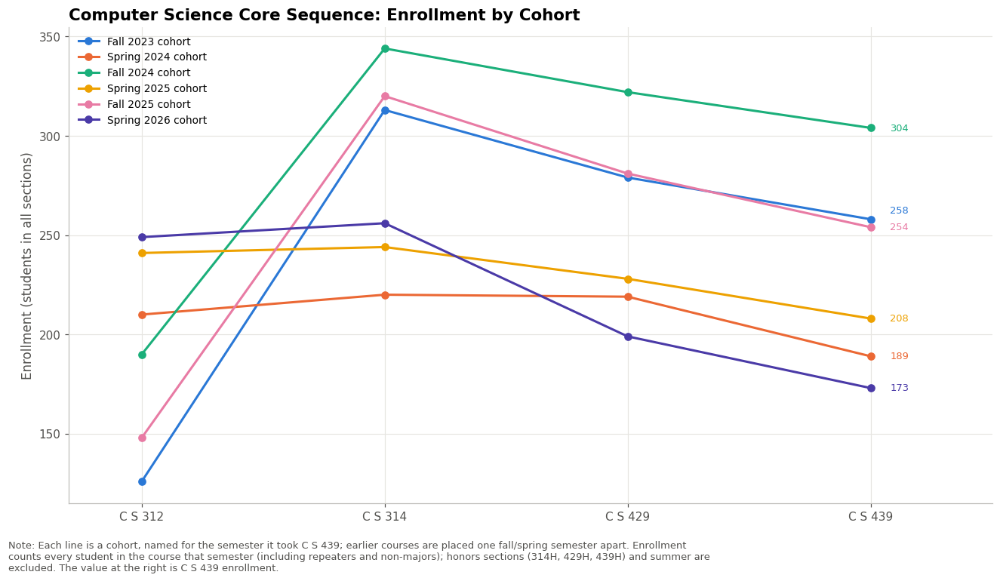

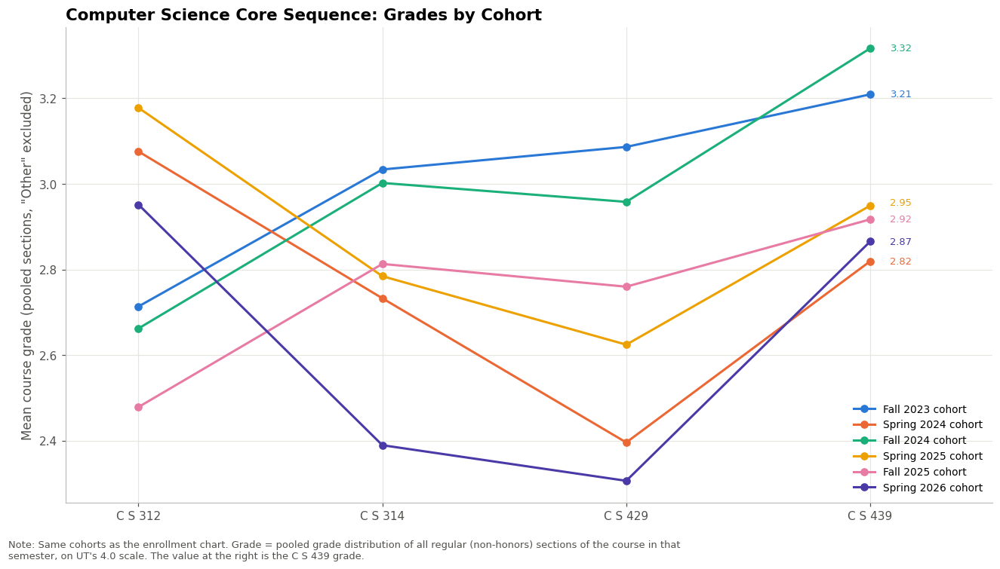

Average change in cohort enrollment from C S 314 to C S 439 across the 6 cohorts: -18.5%


In [50]:
CS_STEPS = [['312'], ['314'], ['429'], ['439']]
cs = cohort_rows('C S', CS_STEPS)
cohort_chart(cs, 'C S', CS_STEPS, 'enrollment', 'Enrollment (students in all sections)', 'Computer Science Core Sequence: Enrollment by Cohort',
             '6_1a_cs_cohort_enrollment',
             'Each line is a cohort, named for the semester it took C S 439; earlier courses are placed one fall/spring semester apart. Enrollment '
             'counts every student in the course that semester (including repeaters and non-majors); honors sections (314H, 429H, 439H) and summer '
             'are excluded. The value at the right is C S 439 enrollment.', lambda v: f'{v:,.0f}')
cohort_chart(cs, 'C S', CS_STEPS, 'grade', 'Mean course grade (pooled sections, "Other" excluded)', 'Computer Science Core Sequence: Grades by Cohort',
             '6_1b_cs_cohort_grades',
             'Same cohorts as the enrollment chart. Grade = pooled grade distribution of all regular (non-honors) sections of the course in that '
             'semester, on UT\'s 4.0 scale. The value at the right is the C S 439 grade.', lambda v: f'{v:.2f}')
cs_pct = cohort_table(cs, 'C S', CS_STEPS, '314', '439')
print(f'Average change in cohort enrollment from C S 314 to C S 439 across the {len(COHORTS)} cohorts: {cs_pct.mean():+.1f}%')

### 6.2 Economics: ECO 304K → 304L → 329 → 420K/420S → 441K → 320L

Students take **either** ECO 420K (Microeconomic Theory) **or** ECO 420S (Mathematical Microeconomic Theory with Advanced Applications). Both are drawn at the same horizontal position: each cohort's solid line runs through 420K, and a dashed detour of the same color runs through 420S, so the line splits at that step and rejoins at 441K. The table also shows 420K + 420S combined, which is the enrollment of the whole cohort at that step.

The enrollment change is measured from ECO 329 to ECO 320L. ECO 304K and 304L are often satisfied by AP/test credit and are taken by many non-majors, so like C S 312 they overstate the starting cohort.

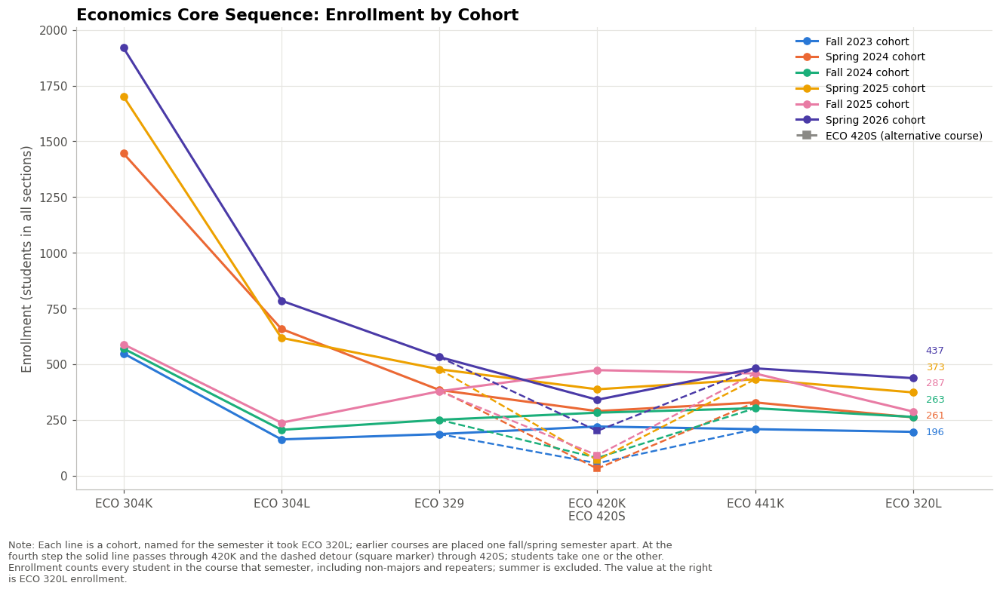

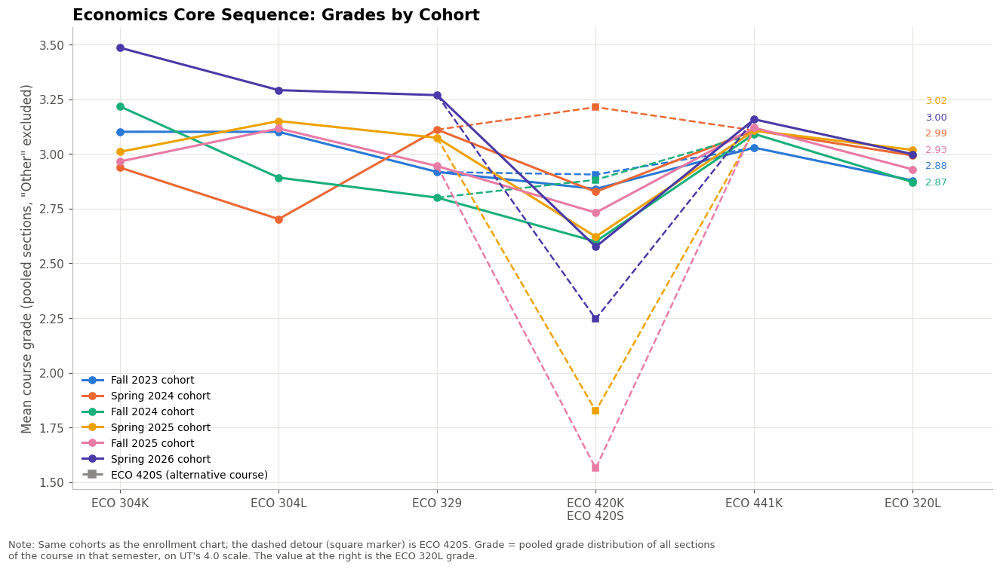

Average change in cohort enrollment from ECO 329 to ECO 320L across the 6 cohorts: -14.2%


In [51]:
ECO_STEPS = [['304K'], ['304L'], ['329'], ['420K', '420S'], ['441K'], ['320L']]
eco = cohort_rows('ECO', ECO_STEPS)
cohort_chart(eco, 'ECO', ECO_STEPS, 'enrollment', 'Enrollment (students in all sections)', 'Economics Core Sequence: Enrollment by Cohort',
             '6_2a_eco_cohort_enrollment',
             'Each line is a cohort, named for the semester it took ECO 320L; earlier courses are placed one fall/spring semester apart. At the '
             'fourth step the solid line passes through 420K and the dashed detour (square marker) through 420S; students take one or the other. '
             'Enrollment counts every student in the course that semester, including non-majors and repeaters; summer is excluded. '
             'The value at the right is ECO 320L enrollment.', lambda v: f'{v:,.0f}')
cohort_chart(eco, 'ECO', ECO_STEPS, 'grade', 'Mean course grade (pooled sections, "Other" excluded)', 'Economics Core Sequence: Grades by Cohort',
             '6_2b_eco_cohort_grades',
             'Same cohorts as the enrollment chart; the dashed detour (square marker) is ECO 420S. Grade = pooled grade distribution of all '
             'sections of the course in that semester, on UT\'s 4.0 scale. The value at the right is the ECO 320L grade.', lambda v: f'{v:.2f}')
eco_pct = cohort_table(eco, 'ECO', ECO_STEPS, '329', '320L')
print(f'Average change in cohort enrollment from ECO 329 to ECO 320L across the {len(COHORTS)} cohorts: {eco_pct.mean():+.1f}%')